# GGA Network Training - Step 3b: Hybrid Fixed-Density + One-Shot Training

This notebook trains neural network GGA exchange-correlation functionals using a **hybrid approach** combining fixed-density energy calculations with fast one-shot density prediction.

## Training Methodology

| Approach | Energy Calculation | Density Matching | Description |
|----------|-------------------|------------------|-------------|
| **A** | Fixed-density | None | AE only on PBE density |
| **B** | Fixed-density | One-shot DM → CCSD | AE + DM correction learning |
| **C** | Fixed-density | One-shot grid ρ → CCSD | AE + grid density correction |
| **D1** | Fixed-density | None | Delta-learning energy only |
| **D2** | Fixed-density | One-shot DM → CCSD | Delta-E + DM correction |
| **D3** | Fixed-density | One-shot grid ρ → CCSD | Delta-E + grid density correction |

## Key Part: Fast One-Shot Without pyscfad

Traditional one-shot calculations using pyscfad are slow (~10 min/atom). We use a **fast pure-JAX implementation**:

1. **Pre-compute once** (before training):
   - Core Hamiltonian: $h$
   - Coulomb potential from PBE density: $J[D_{PBE}]$
   - Overlap matrix: $S$
   - AO values on grid: $\phi_i(\mathbf{r})$

2. **During training** (differentiable, ~100× faster):
   - Compute $V_{xc}^{NN}$ via forward-mode autodiff: $v_\rho = \partial(\rho\varepsilon_{xc})/\partial\rho$
   - Build Fock matrix: $F = h + J[D_{PBE}] + V_{xc}^{NN}$
   - Solve generalized eigenvalue problem: $FC = SC\varepsilon$
   - Form predicted DM: $D_{pred} = 2 C_{occ} C_{occ}^T$
   - Backpropagate through eigendecomposition

## Network Architectures (12 total)

**Standard (2 inputs: ρ, σ):**
`shallow`, `shallow_attn`, `medium`, `medium_attn`, `deep`, `deep_attn`

**Extended features (deep only, using `GGA_F*Net_extended`):**

| Architecture | Inputs | Dimension |
|--------------|--------|-----------|
| `deep_cusp`, `deep_cusp_attn` | $[\rho, \sigma, f_{cusp}, \log Z]$ | 4 |
| `deep_dm`, `deep_dm_attn` | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}]$ | 5 |
| `deep_combined`, `deep_combined_attn` | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}, f_{cusp}, \log Z]$ | 7 |

**Note:** Feature order is **dm BEFORE cusp** to match network `__call__` parsing.

**Total: 72 models** = 12 architectures × 6 training approaches

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import os, sys
import gc
try:
    from tqdm.notebook import tqdm
except ImportError:
    print("falling back to tqdm.tqdm")
    from tqdm import tqdm
from functools import partial

from pyscf import gto, dft, scf, cc
from pyscfad import gto as gto_ad, dft as dft_ad

import xcquinox as xce
from xcquinox.xc import RXCModel_GGA
from xcquinox.pyscf import eval_xc_gga_j2
from xcquinox.utils import lda_x, pw92c_unpolarized

# JAX memory management - release memory when needed
jax.config.update("jax_enable_x64", True)
#pyscfad doesn't provide SCF on GPU capability, forced to use CPU only
jax.config.update('jax_default_device', jax.devices('cpu')[0])

# Clear compilation caches periodically to free memory
def clear_memory():
    """Clear JAX caches and run garbage collection."""
    jax.clear_caches()
    gc.collect()

print(f'JAX: {jax.__version__}, Device: {jax.devices()[0]}')

BASIS = 'def2-svp'
GRID_LEVEL = 1
CHECKPOINT_BASE = 'checkpoints_v3b'
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

JAX: 0.7.0, Device: cuda:0


In [3]:
print(xce.__file__)                                                                                       

/home/awills/Documents/Research/xcquinox/xcquinox/__init__.py


In [4]:
# =============================================================================
# ARCHITECTURES - Define before CHECKPOINT_DIRS
# =============================================================================
# Architecture types (ALL use non-transform networks, matching step3):
# 1. Basic GGA: [rho, sigma] only - use GGA_FxNet_sigma/GGA_FcNet_sigma
# 2. With cusp: [rho, sigma, cusp_factor, log_weighted_Z] - use GGA_FxNet_extended
# 3. With DM features: [rho, sigma, dm_feat1, dm_feat2, dm_feat3] - use GGA_FxNet_extended
# 4. Combined: [rho, sigma, cusp_f1, cusp_f2, dm_f1, dm_f2, dm_f3] - use GGA_FxNet_extended
#
# Non-transform networks match step3 approach for better pre-training convergence.

ARCHITECTURES = {
    # =========================================================================
    # Standard architectures (rho, sigma only) - varying depth/width/attention
    # =========================================================================
    'shallow': {
        'depth': 2, 'nodes': 8, 'use_self_attention': False,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'shallow_attn': {
        'depth': 2, 'nodes': 8, 'use_self_attention': True,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'medium': {
        'depth': 3, 'nodes': 16, 'use_self_attention': False,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'medium_attn': {
        'depth': 3, 'nodes': 16, 'use_self_attention': True,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'deep': {
        'depth': 4, 'nodes': 32, 'use_self_attention': False,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'deep_attn': {
        'depth': 4, 'nodes': 32, 'use_self_attention': True,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    # =========================================================================
    # Extended feature architectures (deep only, with/without attention)
    # =========================================================================
    # Cusp-constrained: adds nuclear cusp information [+2 features]
    'deep_cusp': {
        'depth': 4, 'nodes': 32, 'use_self_attention': False,
        'use_cusp': True, 'use_dm_features': False, 'net_type': 'extended'
    },
    'deep_cusp_attn': {
        'depth': 4, 'nodes': 32, 'use_self_attention': True,
        'use_cusp': True, 'use_dm_features': False, 'net_type': 'extended'
    },
    # DM features: adds density matrix statistics [+3 features]
    'deep_dm': {
        'depth': 4, 'nodes': 32, 'use_self_attention': False,
        'use_cusp': False, 'use_dm_features': True, 'net_type': 'extended'
    },
    'deep_dm_attn': {
        'depth': 4, 'nodes': 32, 'use_self_attention': True,
        'use_cusp': False, 'use_dm_features': True, 'net_type': 'extended'
    },
    # Combined: both cusp and DM features [+5 features]
    'deep_combined': {
        'depth': 4, 'nodes': 32, 'use_self_attention': False,
        'use_cusp': True, 'use_dm_features': True, 'net_type': 'extended'
    },
    'deep_combined_attn': {
        'depth': 4, 'nodes': 32, 'use_self_attention': True,
        'use_cusp': True, 'use_dm_features': True, 'net_type': 'extended'
    },
}

SKIP_TRAINING = False
print(f'Architectures ({len(ARCHITECTURES)} total):')
print(f'  Standard (rho, sigma) - 6 archs using GGA_F*Net_sigma:')
print(f'    shallow, shallow_attn, medium, medium_attn, deep, deep_attn')
print(f'  Extended features (deep only) - 6 archs using GGA_F*Net_extended:')
print(f'    deep_cusp, deep_cusp_attn (+2 cusp features)')
print(f'    deep_dm, deep_dm_attn (+3 DM features)')
print(f'    deep_combined, deep_combined_attn (+5 cusp+DM features)')


Architectures (12 total):
  Standard (rho, sigma) - 6 archs using GGA_F*Net_sigma:
    shallow, shallow_attn, medium, medium_attn, deep, deep_attn
  Extended features (deep only) - 6 archs using GGA_F*Net_extended:
    deep_cusp, deep_cusp_attn (+2 cusp features)
    deep_dm, deep_dm_attn (+3 DM features)
    deep_combined, deep_combined_attn (+5 cusp+DM features)


In [5]:
# Create checkpoint directories for each approach and architecture
CHECKPOINT_DIRS = {
    'pretrain': os.path.join(CHECKPOINT_BASE, '01_pretrain'),
    'A_ae_only': os.path.join(CHECKPOINT_BASE, '02_A_ae_only'),
    'B_ae_dm': os.path.join(CHECKPOINT_BASE, '03_B_ae_dm'),
    'C_ae_grid': os.path.join(CHECKPOINT_BASE, '04_C_ae_grid'),
    'D1_delta_e': os.path.join(CHECKPOINT_BASE, '05_D1_delta_e'),
    'D2_delta_dm': os.path.join(CHECKPOINT_BASE, '06_D2_delta_dm'),
    'D3_delta_grid': os.path.join(CHECKPOINT_BASE, '07_D3_delta_grid'),
}

for approach, path in CHECKPOINT_DIRS.items():
    os.makedirs(path, exist_ok=True)
    for arch in ARCHITECTURES.keys():
        os.makedirs(os.path.join(path, arch), exist_ok=True)

print('Checkpoint directories created.')

Checkpoint directories created.


In [6]:
# =============================================================================
# Extended Model Class for Cusp/DM Features
# =============================================================================
# RXCModel_GGA only handles [rho, sigma] (2 features) or polarized (5 features).
# For extended features (cusp, DM), we need a flexible model that:
# 1. Extracts rho/sigma for LDA base components
# 2. Passes full feature array to the networks

class RXCModel_GGA_extended(eqx.Module):
    """Extended GGA XC model supporting cusp and DM features.
    
    Handles arbitrary input features: [rho, sigma, ...extended_features...]
    Networks receive full feature array, LDA base uses just rho.
    """
    xnet: eqx.Module
    cnet: eqx.Module
    
    def __init__(self, xnet, cnet):
        self.xnet = xnet
        self.cnet = cnet
    
    def _eval_single_point(self, point):
        """Evaluate epsilon for a single grid point with arbitrary features."""
        rho = point[0]
        sigma = point[1]
        
        # LDA base components
        ex_lda = xce.xc.lda_x(rho)
        ec_pw92 = xce.xc.pw92c_unpolarized_scalar(rho)
        
        rho_safe = jnp.maximum(rho, 1e-18)
        
        # Networks receive full feature array
        Fx = jnp.sum(self.xnet(point))
        Fc = jnp.sum(self.cnet(point))
        
        epsilon = rho_safe * (ex_lda * Fx + ec_pw92 * Fc)
        return epsilon
    
    def __call__(self, inputs):
        """Compute epsilon for batched grid points."""
        inputs = jnp.atleast_2d(inputs)
        epsilon = jax.vmap(self._eval_single_point)(inputs)
        return jnp.squeeze(epsilon)

print('Defined RXCModel_GGA_extended for cusp/DM feature support')



Defined RXCModel_GGA_extended for cusp/DM feature support


In [7]:
def create_network_pair(arch_name, seed=42):
    """Create xnet, cnet pair for given architecture.
    
    Uses non-transform networks for numerical stability:
    - Basic: GGA_FxNet_sigma/GGA_FcNet_sigma with [rho, sigma] input
    - Extended: GGA_FxNet_extended/GGA_FcNet_extended with cusp/DM features
    
    Non-transform networks match step3 approach for optimal pre-training convergence.
    """
    config = ARCHITECTURES[arch_name]
    depth = config['depth']
    nodes = config['nodes']
    use_attn = config['use_self_attention']
    use_cusp = config.get('use_cusp', False)
    use_dm = config.get('use_dm_features', False)
    net_type = config.get('net_type', 'basic')
    
    if net_type == 'extended' or use_cusp or use_dm:
        # Use extended networks with additional features (non-transform, matching step3)
        xnet = xce.net.GGA_FxNet_extended(
            depth=depth,
            nodes=nodes,
            seed=seed,
            lower_rho_cutoff=1e-6,  # Larger cutoff for gradient stability
            use_self_attention=use_attn,
            use_cusp=use_cusp,
            use_dm_features=use_dm,
            use_laplacian=False,  # Not using laplacian for now
            n_dm_features=3
        )
        
        cnet = xce.net.GGA_FcNet_extended(
            depth=depth,
            nodes=nodes,
            seed=seed+1,
            lower_rho_cutoff=1e-6,  # Larger cutoff for gradient stability
            use_self_attention=use_attn,
            use_cusp=use_cusp,
            use_dm_features=use_dm,
            use_laplacian=False,
            n_dm_features=3
        )
    else:
        # Use basic sigma networks (non-transform, matching step3)
        xnet = xce.net.GGA_FxNet_sigma(
            depth=depth,
            nodes=nodes,
            seed=seed,
            lower_rho_cutoff=1e-6,  # Larger cutoff for gradient stability
            use_self_attention=use_attn
        )
        
        cnet = xce.net.GGA_FcNet_sigma(
            depth=depth,
            nodes=nodes,
            seed=seed+1,
            lower_rho_cutoff=1e-6,  # Larger cutoff for gradient stability
            use_self_attention=use_attn
        )
    
    return xnet, cnet

# Create networks for all architectures
SEED = 42
networks = {}
for arch in ARCHITECTURES.keys():
    networks[arch] = {'xnet': None, 'cnet': None}
    xnet, cnet = create_network_pair(arch, SEED)
    networks[arch]['xnet'] = xnet
    networks[arch]['cnet'] = cnet
    config = ARCHITECTURES[arch]
    features = []
    if config.get('use_cusp'): features.append('cusp')
    if config.get('use_dm_features'): features.append('dm')
    feat_str = '+'.join(features) if features else 'basic'
    net_type = 'sigma' if config.get('net_type', 'basic') == 'basic' else 'extended'
    print(f'{arch}: depth={config["depth"]}, nodes={config["nodes"]}, attn={config["use_self_attention"]}, features={feat_str}, network={net_type}')


shallow: depth=2, nodes=8, attn=False, features=basic, network=sigma
shallow_attn: depth=2, nodes=8, attn=True, features=basic, network=sigma
medium: depth=3, nodes=16, attn=False, features=basic, network=sigma
medium_attn: depth=3, nodes=16, attn=True, features=basic, network=sigma
deep: depth=4, nodes=32, attn=False, features=basic, network=sigma
deep_attn: depth=4, nodes=32, attn=True, features=basic, network=sigma
deep_cusp: depth=4, nodes=32, attn=False, features=cusp, network=extended
deep_cusp_attn: depth=4, nodes=32, attn=True, features=cusp, network=extended
deep_dm: depth=4, nodes=32, attn=False, features=dm, network=extended
deep_dm_attn: depth=4, nodes=32, attn=True, features=dm, network=extended
deep_combined: depth=4, nodes=32, attn=False, features=cusp+dm, network=extended
deep_combined_attn: depth=4, nodes=32, attn=True, features=cusp+dm, network=extended


In [8]:
def create_mol(atoms, spin=0):
    mol = gto.Mole()
    mol.atom = atoms
    mol.basis = BASIS
    mol.spin = spin
    mol.build()
    return mol

def create_mol_ad(atoms, spin=0):
    mol = gto_ad.Mole()
    mol.atom = atoms
    mol.basis = BASIS
    mol.spin = spin
    mol.build()
    return mol

## 2. Pre-training on PBE Enhancement Factors

Pre-train all 12 architectures to reproduce PBE enhancement factors ($F_x$, $F_c$).

**Purpose:** Initialize networks near a known good functional before fine-tuning.

**Networks:** All architectures use non-transform networks for pre-training:
- Basic: `GGA_FxNet_sigma` / `GGA_FcNet_sigma`
- Extended: `GGA_FxNet_extended` / `GGA_FcNet_extended`

**Input feature order** (must match network's `__call__` expectation: **dm BEFORE cusp**):

| Architecture | Input Features | Dimension |
|--------------|----------------|-----------|
| Basic | $[\rho, \sigma]$ | 2 |
| DM only | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}]$ | 5 |
| Cusp only | $[\rho, \sigma, f_{cusp}, \log Z_{weighted}]$ | 4 |
| Combined | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}, f_{cusp}, \log Z_{weighted}]$ | 7 |

**Feature definitions:**
- $f_{cusp} = e^{-2 Z_{nearest} r_{min}}$: exponential decay from nearest nucleus
- $\log Z_{weighted} = \log(\sum_A Z_A / r_A)$: Coulomb-weighted nuclear charge
- $f_{idem}, f_{entropy}, f_{offdiag}$: density matrix correlation indicators (global per molecule)

**Training configuration:**
- Gradient clipping: `optax.clip_by_global_norm(PRETRAIN_GRAD_CLIP)`
- Learning rate schedule: Configurable via `PRETRAIN_LR_START`, `PRETRAIN_LR_END`, `PRETRAIN_LR_DECAY_START`
  - If `LR_DECAY_START = 0`: immediate linear decay from start to end
  - If `LR_DECAY_START > 0`: constant LR for first fraction, then linear decay

In [9]:
class PretrainLoss(eqx.Module):
    """Stateless MSE loss for pre-training enhancement factors.
    
    Networks output F = 1 + enhancement, targets are F - 1 values.
    Data is passed directly to __call__, not stored as attributes.
    """
    def __call__(self, model, descriptors, target):
        """Compute MSE loss.
        
        :param model: Enhancement factor network
        :param descriptors: Pre-assembled input descriptors shape (N, n_features)
        :param target: Reference F-1 values shape (N,)
        :return: MSE loss
        """
        pred = jax.vmap(model)(descriptors).squeeze()
        pred = pred - 1.0  # Convert from F to F-1
        return jnp.mean((pred - target)**2)

print('Defined stateless PretrainLoss - data passed directly to __call__')



Defined stateless PretrainLoss - data passed directly to __call__


In [10]:
# Collect enhancement factor data from PBE (matches step2 approach)
# Also collect cusp and DM features for extended architectures
from xcquinox.features import compute_cusp_descriptor, compute_dm_features_array

pretrain_atoms = [('H', 1), ('He', 0), ('O', 2), ('N', 3)]
rho_all, sigma_all, Fx_all, Fc_all = [], [], [], []
cusp_all, dm_all = [], []  # Extended features

for atom, spin in pretrain_atoms:
    mol = create_mol(f'{atom} 0 0 0', spin=spin)
    mf = dft.UKS(mol) if spin else dft.RKS(mol)
    mf.xc = 'pbe'
    mf.grids.level = GRID_LEVEL
    mf.grids.build()
    mf.kernel()
    
    # Use pyscf's eval_ao and eval_rho for proper GGA density format
    ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=1)
    dm = mf.make_rdm1()
    overlap = mf.get_ovlp()
    
    # Handle spin - split into alpha/beta
    if dm.ndim == 2:
        dm_alpha = dm * 0.5
        dm_beta = dm * 0.5
        dm_tot = dm
    else:
        dm_alpha = dm[0]
        dm_beta = dm[1]
        dm_tot = dm[0] + dm[1]
    
    # Evaluate density on grid (GGA format: rho, grad_x, grad_y, grad_z)
    rho_alpha = mf._numint.eval_rho(mol, ao, dm_alpha, xctype='GGA', hermi=True)
    rho_beta = mf._numint.eval_rho(mol, ao, dm_beta, xctype='GGA', hermi=True)
    
    # Extract density and gradient components
    rho0 = rho_alpha[0] + rho_beta[0]  # Total density
    drho = rho_alpha[1:4] + rho_beta[1:4]  # Total gradient
    sigma = np.sum(drho**2, axis=0)
    
    # Total density in GGA format for eval_xc
    rho_total = rho_alpha + rho_beta  # Shape (4, N)
    
    # Filter low-density regions
    valid = rho0 > 1e-10
    rho0_v = rho0[valid]
    sigma_v = sigma[valid]
    rho_total_v = rho_total[:, valid]
    coords_v = mf.grids.coords[valid]
    
    # Get PBE exchange and correlation energy densities
    ex = mf._numint.eval_xc('PBE,', rho_total_v, spin=0)[0]
    ec = mf._numint.eval_xc(',PBE', rho_total_v, spin=0)[0]
    
    # Get LDA values for enhancement factor calculation
    ex_lda = mf._numint.eval_xc('LDA_X,', rho0_v, spin=0)[0]
    ec_lda = mf._numint.eval_xc(',LDA_C_PW', rho0_v, spin=0)[0]
    
    # Enhancement factors (F - 1, matching network output)
    # Use safe division
    ex_lda_safe = np.where(np.abs(ex_lda) > 1e-12, ex_lda, 1e-12)
    ec_lda_safe = np.where(np.abs(ec_lda) > 1e-12, ec_lda, 1e-12)
    
    Fx = ex / ex_lda_safe - 1.0
    Fc = ec / ec_lda_safe - 1.0
    
    # Clip outliers
    Fx = np.clip(Fx, -5, 5)
    Fc = np.clip(Fc, -5, 5)
    
    rho_all.extend(rho0_v)
    sigma_all.extend(sigma_v)
    Fx_all.extend(Fx)
    Fc_all.extend(Fc)
    
    # Compute extended features for this atom
    # Cusp features
    nuclear_coords = jnp.array(mol.atom_coords())
    nuclear_charges = jnp.array([mol.atom_charge(i) for i in range(mol.natm)])
    cusp_feat = compute_cusp_descriptor(jnp.array(coords_v), nuclear_coords, nuclear_charges)
    cusp_all.extend(np.array(cusp_feat))
    
    # DM features (global, tiled to grid points)
    dm_feat_global = compute_dm_features_array(jnp.array(dm_tot), jnp.array(overlap))
    dm_feat_tiled = np.tile(np.array(dm_feat_global), (len(rho0_v), 1))
    dm_all.extend(dm_feat_tiled)

rho_all = jnp.array(rho_all)
sigma_all = jnp.array(sigma_all)
Fx_all = jnp.array(Fx_all)
Fc_all = jnp.array(Fc_all)
cusp_all = jnp.array(cusp_all)
dm_all = jnp.array(dm_all)

print(f'Pre-training data: {len(rho_all)} grid points from {len(pretrain_atoms)} atoms')
print(f'  rho: [{rho_all.min():.2e}, {rho_all.max():.2e}]')
print(f'  sigma: [{sigma_all.min():.2e}, {sigma_all.max():.2e}]')
print(f'  Fx-1: [{Fx_all.min():.3f}, {Fx_all.max():.3f}]')
print(f'  Fc-1: [{Fc_all.min():.3f}, {Fc_all.max():.3f}]')
print(f'  cusp_features: {cusp_all.shape}')
print(f'  dm_features: {dm_all.shape}')



converged SCF energy = -0.498629446221046  <S^2> = 0.75  2S+1 = 2
converged SCF energy = -2.88446415545498
converged SCF energy = -74.9146647039971  <S^2> = 2.0018396  2S+1 = 3.0012262
converged SCF energy = -54.4665775578499  <S^2> = 3.751995  2S+1 = 4.0009974
Pre-training data: 13186 grid points from 4 atoms
  rho: [1.29e-10, 2.81e+02]
  sigma: [7.42e-19, 1.50e+07]
  Fx-1: [0.000, 0.804]
  Fc-1: [-1.000, -0.000]
  cusp_features: (13186, 2)
  dm_features: (13186, 3)


## 2b. Parallel Pre-training (Optional)

The following cells enable **parallel pre-training** using subprocess workers.
This can significantly speed up pre-training when you have multiple CPU cores available.

### Usage
1. Run the "Save pre-training data" cell
2. Adjust `MAX_PRETRAIN_WORKERS` based on your system (default: 4)
3. Run the parallel pre-training cell
4. Run the "Load pre-trained networks" cell to load results into memory

Skip these cells and use the sequential pre-training below if you prefer.

In [11]:
# =============================================================================
# Save pre-training data for parallel workers
# =============================================================================
import pickle

PRETRAIN_DATA_DIR = os.path.join(CHECKPOINT_BASE, 'pretrain_data')
os.makedirs(PRETRAIN_DATA_DIR, exist_ok=True)

print('Saving pre-training data for parallel workers...')

# Save all pre-training arrays
pretrain_data = {
    'rho_all': np.array(rho_all),
    'sigma_all': np.array(sigma_all),
    'Fx_all': np.array(Fx_all),
    'Fc_all': np.array(Fc_all),
    'cusp_all': np.array(cusp_all),
    'dm_all': np.array(dm_all),
}
with open(os.path.join(PRETRAIN_DATA_DIR, 'pretrain_data.pkl'), 'wb') as f:
    pickle.dump(pretrain_data, f)
print(f'  Saved pretrain_data: {len(rho_all)} points')

# Save architecture configs
with open(os.path.join(PRETRAIN_DATA_DIR, 'architectures.pkl'), 'wb') as f:
    pickle.dump(ARCHITECTURES, f)
print(f'  Saved ARCHITECTURES: {len(ARCHITECTURES)} architectures')

# Save checkpoint directories
with open(os.path.join(PRETRAIN_DATA_DIR, 'checkpoint_dirs.pkl'), 'wb') as f:
    pickle.dump(CHECKPOINT_DIRS, f)
print('  Saved checkpoint_dirs')

print(f'\nAll pre-training data saved to: {PRETRAIN_DATA_DIR}')
print('Ready for parallel pre-training.')

Saving pre-training data for parallel workers...
  Saved pretrain_data: 13186 points
  Saved ARCHITECTURES: 12 architectures
  Saved checkpoint_dirs

All pre-training data saved to: checkpoints_v3b/pretrain_data
Ready for parallel pre-training.


In [12]:
# =============================================================================
# Parallel Pre-training Infrastructure with Per-Job Progress Bars
# =============================================================================
import subprocess
import json
import time as time_module
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
import threading

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Configuration - IMPORTANT: Keep workers low to avoid OOM (rc=-6)
# Each worker loads JAX and compiles XLA code, using significant memory
MAX_PRETRAIN_WORKERS = 5  # Safe default; increase if you have >64GB RAM
PRETRAIN_WORKER_SCRIPT = '/home/awills/Documents/Research/xcquinox/scripts/parallel_pretrain_worker.py'

print(f"Pre-train worker script: {PRETRAIN_WORKER_SCRIPT}")
print(f"Exists: {os.path.exists(PRETRAIN_WORKER_SCRIPT)}")


def run_single_pretrain(arch, steps, data_dir, checkpoint_base, threads_per_worker=4,
                        lr_start=1e-2, lr_end=1e-4, lr_decay_start=0.0, grad_clip=1.0):
    """Run pre-training for a single architecture via subprocess.
    
    Args:
        arch: Architecture name
        steps: Number of pre-training steps
        data_dir: Directory containing pre-training data
        checkpoint_base: Base checkpoint directory
        threads_per_worker: CPU threads per worker
        lr_start: Initial learning rate
        lr_end: Final learning rate  
        lr_decay_start: Fraction of steps before LR decay begins (0.0-1.0)
        grad_clip: Gradient clipping norm
    """
    
    cmd = [
        sys.executable, PRETRAIN_WORKER_SCRIPT,
        '--arch', arch,
        '--steps', str(steps),
        '--data-dir', data_dir,
        '--checkpoint-base', checkpoint_base,
        '--threads', str(threads_per_worker),
        '--lr-start', str(lr_start),
        '--lr-end', str(lr_end),
        '--lr-decay-start', str(lr_decay_start),
        '--grad-clip', str(grad_clip),
    ]
    
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=3600
        )
        
        stdout_text = result.stdout.strip() if result.stdout else ''
        stderr_text = result.stderr[-1000:] if result.stderr else ''
        
        if result.returncode == 0 and stdout_text:
            # Parse JSON from last line starting with '{' (jax.debug.print pollutes stdout)
            for line in reversed(stdout_text.split('\n')):
                line = line.strip()
                if line.startswith('{'):
                    try:
                        return json.loads(line)
                    except json.JSONDecodeError:
                        continue
            # No valid JSON found
            return {
                'status': 'failed',
                'arch': arch,
                'error': f'No JSON in output. Last 200 chars: {stdout_text[-200:]}'
            }
        else:
            return {
                'status': 'failed',
                'arch': arch,
                'error': f'Exit {result.returncode}. stderr={stderr_text[-300:]}'
            }
            
    except subprocess.TimeoutExpired:
        return {'status': 'failed', 'arch': arch, 'error': 'Timeout (1h)'}
    except Exception as e:
        return {'status': 'failed', 'arch': arch, 'error': f'Exception: {str(e)}'}


def run_parallel_pretrain(architectures, steps, data_dir, checkpoint_base,
                          max_workers=3, threads_per_worker=4,
                          lr_start=1e-2, lr_end=1e-4, lr_decay_start=0.0, grad_clip=1.0):
    """Run pre-training jobs in parallel with progress tracking.
    
    Args:
        architectures: List of architecture names to train
        steps: Number of pre-training steps per architecture
        data_dir: Directory containing pre-training data
        checkpoint_base: Base checkpoint directory
        max_workers: Maximum parallel workers
        threads_per_worker: CPU threads per worker
        lr_start: Initial learning rate
        lr_end: Final learning rate
        lr_decay_start: Fraction of steps before LR decay begins (0.0-1.0)
        grad_clip: Gradient clipping norm
    """
    results = []
    failed = []
    total = len(architectures)
    total_steps = steps * 2  # X + C training

    print(f"\n{'='*70}")
    print(f"PARALLEL PRE-TRAINING: {total} architectures")
    print(f"  Workers: {max_workers} (keep low to avoid OOM)")
    print(f"  Steps per network: {steps}")
    print(f"  Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    # Overall progress bar
    pbar_overall = tqdm(total=total, desc="Overall", unit="arch", position=0,
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    # Per-job progress bars
    job_pbars = {}
    active_jobs = set()
    pbar_lock = threading.Lock()
    stop_event = threading.Event()
    
    def read_progress_file(arch):
        """Read progress from worker's progress.json file."""
        progress_file = os.path.join(checkpoint_base, '01_pretrain', arch, 'progress.json')
        try:
            if os.path.exists(progress_file):
                with open(progress_file, 'r') as f:
                    data = json.load(f)
                phase = data.get('phase', 'X')
                step = data.get('step', 0)
                loss = data.get('loss', 0.0)
                # Combined: X done (steps) + C progress
                combined = (steps + step) if phase == 'C' else step
                return combined, phase, loss
        except:
            pass
        return 0, '?', 0.0

    def progress_updater():
        """Background thread to update progress bars."""
        while not stop_event.is_set():
            with pbar_lock:
                for arch in list(active_jobs):
                    if arch in job_pbars:
                        progress, phase, loss = read_progress_file(arch)
                        pbar = job_pbars[arch]
                        pbar.n = min(progress, total_steps)
                        pbar.set_postfix_str(f"phase={phase}, loss={loss:.4f}")
                        pbar.refresh()
            time_module.sleep(1.0)

    updater_thread = threading.Thread(target=progress_updater, daemon=True)
    updater_thread.start()

    status_lines = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_arch = {}
        next_pos = 1
        
        for arch in architectures:
            with pbar_lock:
                job_pbars[arch] = tqdm(
                    total=total_steps,
                    desc=f"  {arch[:18]:<18}",
                    unit="step",
                    position=next_pos,
                    leave=False,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} {postfix}'
                )
                active_jobs.add(arch)
                next_pos += 1
            
            future = executor.submit(
                run_single_pretrain,
                arch, steps, data_dir, checkpoint_base, threads_per_worker,
                lr_start, lr_end, lr_decay_start, grad_clip
            )
            future_to_arch[future] = arch

        for future in as_completed(future_to_arch):
            arch = future_to_arch[future]
            
            try:
                result = future.result()
                if result['status'] == 'success':
                    results.append(result)
                    loss_x = result.get('final_loss_x', 0)
                    loss_c = result.get('final_loss_c', 0)
                    dur = result.get('duration', 0)
                    status_lines.append(f"✓ {arch:<20} X={loss_x:.6f} C={loss_c:.6f} ({dur:.0f}s)")
                else:
                    failed.append(result)
                    err = result.get('error', 'Unknown')[:50]
                    status_lines.append(f"✗ {arch:<20} ERROR: {err}")
            except Exception as e:
                failed.append({'arch': arch, 'error': str(e)})
                status_lines.append(f"✗ {arch:<20} EXCEPTION: {str(e)[:40]}")
            
            with pbar_lock:
                if arch in job_pbars:
                    job_pbars[arch].n = total_steps
                    job_pbars[arch].refresh()
                    job_pbars[arch].close()
                    del job_pbars[arch]
                active_jobs.discard(arch)
            
            pbar_overall.update(1)
            pbar_overall.set_postfix({'OK': len(results), 'Fail': len(failed)})

    stop_event.set()
    updater_thread.join(timeout=2)
    
    with pbar_lock:
        for pbar in job_pbars.values():
            pbar.close()
    pbar_overall.close()
    
    print("\n" + "─"*70)
    print("Results:")
    print("─"*70)
    for line in sorted(status_lines):
        print(f"  {line}")
    
    total_time = time_module.time() - 0  # Will be set properly
    print(f"\n{'='*70}")
    print(f"Completed: {len(results)}/{total} successful, {len(failed)}/{total} failed")
    print(f"{'='*70}")

    return results, failed


print(f"\nParallel pre-training ready.")
print(f"  MAX_PRETRAIN_WORKERS: {MAX_PRETRAIN_WORKERS}")
print(f"  Progress: file-based polling with per-job bars")


Pre-train worker script: /home/awills/Documents/Research/xcquinox/scripts/parallel_pretrain_worker.py
Exists: True

Parallel pre-training ready.
  MAX_PRETRAIN_WORKERS: 5
  Progress: file-based polling with per-job bars


In [ ]:
# =============================================================================
# Run Parallel Pre-training
# =============================================================================
# Pre-training configuration
PRETRAIN_STEPS = 1000
PRETRAIN_LR_START = 1e-2       # Initial learning rate
PRETRAIN_LR_END = 1e-5         # Final learning rate
PRETRAIN_LR_DECAY_START = 0.2  # Fraction of steps before decay begins (0.0 = immediate)
PRETRAIN_GRAD_CLIP = 1.0       # Gradient clipping norm

PRETRAIN_DATA_DIR = os.path.join(CHECKPOINT_BASE, 'pretrain_data')

# Verify data exists
if not os.path.exists(os.path.join(PRETRAIN_DATA_DIR, 'pretrain_data.pkl')):
    print("ERROR: Pre-training data not found!")
    print("Please run the 'Save pre-training data' cell first.")
else:
    pretrain_start = time_module.time()

    print(f"\n{'#'*60}")
    print(f"# PARALLEL PRE-TRAINING")
    print(f"# Steps per architecture: {PRETRAIN_STEPS}")
    print(f"# LR: {PRETRAIN_LR_START} -> {PRETRAIN_LR_END} (decay start: {PRETRAIN_LR_DECAY_START})")
    print(f"# Total architectures: {len(ARCHITECTURES)}")
    print(f"# Max workers: {MAX_PRETRAIN_WORKERS}")
    print(f"# Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'#'*60}")

    pretrain_results, pretrain_failed = run_parallel_pretrain(
        architectures=list(ARCHITECTURES.keys()),
        steps=PRETRAIN_STEPS,
        data_dir=PRETRAIN_DATA_DIR,
        checkpoint_base=CHECKPOINT_BASE,
        max_workers=MAX_PRETRAIN_WORKERS,
        threads_per_worker=4,
        lr_start=PRETRAIN_LR_START,
        lr_end=PRETRAIN_LR_END,
        lr_decay_start=PRETRAIN_LR_DECAY_START,
        grad_clip=PRETRAIN_GRAD_CLIP
    )

    # Save summary
    pretrain_summary = {
        'total_time_seconds': time_module.time() - pretrain_start,
        'successful': len(pretrain_results),
        'failed': len(pretrain_failed),
        'results': pretrain_results,
        'failed_details': pretrain_failed,
        'timestamp': datetime.now().isoformat(),
    }

    summary_path = os.path.join(CHECKPOINT_DIRS['pretrain'], 'pretrain_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(pretrain_summary, f, indent=2)

    print(f"\nSaved pre-training summary to: {summary_path}")


############################################################
# PARALLEL PRE-TRAINING
# Steps per architecture: 1000
# LR: 0.01 -> 1e-05 (decay start: 0.2)
# Total architectures: 12
# Max workers: 5
# Started: 2026-02-03 18:09:20
############################################################

PARALLEL PRE-TRAINING: 12 architectures
  Workers: 5 (keep low to avoid OOM)
  Steps per network: 1000
  Started: 2026-02-03 18:09:20



Overall:   0%|          | 0/12 [00:00<?]

  shallow           :   0%|          | 0/2000 

  shallow_attn      :   0%|          | 0/2000 

  medium            :   0%|          | 0/2000 

...

  deep_cusp_attn    :   0%|          | 0/2000 

  deep_dm           :   0%|          | 0/2000 

  deep_dm_attn      :   0%|          | 0/2000 

  deep_combined     :   0%|          | 0/2000 

  deep_combined_attn:   0%|          | 0/2000 

In [13]:
# =============================================================================
# Load Pre-trained Networks into Memory
# =============================================================================
# After parallel pre-training, load the networks back into the `networks` dict

print("Loading pre-trained networks...")
pretrain_losses = {}  # Reset to collect from loaded files

for arch in ARCHITECTURES.keys():
    arch_dir = os.path.join(CHECKPOINT_DIRS['pretrain'], arch)
    xnet_path = os.path.join(arch_dir, 'xnet.eqx')
    cnet_path = os.path.join(arch_dir, 'cnet.eqx')

    if os.path.exists(xnet_path) and os.path.exists(cnet_path):
        # Create fresh network pair to get the structure
        xnet, cnet = create_network_pair(arch, SEED)

        # Load trained weights
        xnet = eqx.tree_deserialise_leaves(xnet_path, xnet)
        cnet = eqx.tree_deserialise_leaves(cnet_path, cnet)

        networks[arch]['xnet'] = xnet
        networks[arch]['cnet'] = cnet

        # Load losses if available
        losses_x_path = os.path.join(arch_dir, 'losses_x.npy')
        losses_c_path = os.path.join(arch_dir, 'losses_c.npy')
        if os.path.exists(losses_x_path) and os.path.exists(losses_c_path):
            losses_x = np.load(losses_x_path)
            losses_c = np.load(losses_c_path)
            pretrain_losses[arch] = {'x': losses_x, 'c': losses_c}
            print(f"  ✓ {arch}: X={losses_x[-1]:.6f}, C={losses_c[-1]:.6f}")
        else:
            print(f"  ✓ {arch}: loaded (no loss data)")
    else:
        print(f"  ✗ {arch}: not found at {arch_dir}")

loaded_count = len([a for a in ARCHITECTURES if networks[a]['xnet'] is not None])
print(f"\nLoaded {loaded_count}/{len(ARCHITECTURES)} pre-trained network pairs")
print(f"Losses loaded for {len(pretrain_losses)}/{len(ARCHITECTURES)} architectures")

# Save combined pretrain losses for easy access
if pretrain_losses:
    combined_losses_path = os.path.join(CHECKPOINT_BASE, 'pretrain_losses.npz')
    np.savez(combined_losses_path,
             **{f'{arch}_x': pretrain_losses[arch]['x'] for arch in pretrain_losses},
             **{f'{arch}_c': pretrain_losses[arch]['c'] for arch in pretrain_losses})
    print(f"Saved combined losses to: {combined_losses_path}")

Loading pre-trained networks...
  ✓ shallow: X=0.000076, C=0.000146
  ✓ shallow_attn: X=0.000060, C=0.000130
  ✓ medium: X=0.000071, C=0.000116
  ✓ medium_attn: X=0.000018, C=0.000105
  ✓ deep: X=0.000066, C=0.000111
  ✓ deep_attn: X=0.000050, C=0.000097
  ✓ deep_cusp: X=0.000107, C=0.000042
  ✓ deep_cusp_attn: X=0.000007, C=0.000003
  ✓ deep_dm: X=0.014189, C=0.000206
  ✓ deep_dm_attn: X=0.014560, C=0.000007
  ✓ deep_combined: X=0.000061, C=0.000144
  ✓ deep_combined_attn: X=0.000003, C=0.000005

Loaded 12/12 pre-trained network pairs
Losses loaded for 12/12 architectures
Saved combined losses to: checkpoints_v3b/pretrain_losses.npz


In [13]:
# # Pre-train all architectures with gradient clipping and linear LR schedule
# pretrain_losses = {}
# PTSTEPS = 500
# PT_LR_START = 1e-2
# PT_LR_END = 1e-4
# PT_GRAD_CLIP = 1.0

# if not SKIP_TRAINING:
#     for arch in ARCHITECTURES.keys():
#         print(f'Pre-training {arch}...')
#         arch_config = ARCHITECTURES[arch]
#         xnet, cnet = networks[arch]['xnet'], networks[arch]['cnet']
        
#         # Checkpoint directory for this architecture
#         arch_dir = os.path.join(CHECKPOINT_DIRS['pretrain'], arch)
        
#         # Determine which extended features to use
#         use_cusp = arch_config.get('use_cusp', False)
#         use_dm = arch_config.get('use_dm_features', False)
        
#         cusp_feat = cusp_all if use_cusp else None
#         dm_feat = dm_all if use_dm else None
        
#         feat_str = []
#         if use_cusp: feat_str.append('cusp')
#         if use_dm: feat_str.append('dm')
#         feat_str = '+'.join(feat_str) if feat_str else 'basic'
#         print(f'  Features: {feat_str}')
        
#         # Linear LR schedule: start high, decay to low
#         lr_schedule = optax.linear_schedule(
#             init_value=PT_LR_START,
#             end_value=PT_LR_END,
#             transition_steps=PTSTEPS
#         )
        
#         # Optimizer with gradient clipping and scheduled LR
#         optimizer = optax.chain(
#             optax.clip_by_global_norm(PT_GRAD_CLIP),
#             optax.adam(learning_rate=lr_schedule)
#         )
        
#         # Assemble descriptors based on architecture features
#         # Order must match network's __call__ expectation: dm BEFORE cusp
#         input_list = [rho_all, sigma_all]
#         if use_dm:
#             for j in range(dm_feat.shape[1]):
#                 input_list.append(dm_feat[:, j])
#         if use_cusp:
#             input_list.extend([cusp_feat[:, 0], cusp_feat[:, 1]])
#         desc_x = jnp.stack(input_list, axis=1)
        
#         # Train exchange with stateless loss
#         x_loss = PretrainLoss()
#         trainer_x = xce.train.xcTrainer(model=xnet, optim=optimizer, 
#                                          loss=x_loss, steps=PTSTEPS, do_jit=True,
#                                          serialize_every=50,
#                                          checkpoint_dir=arch_dir)
#         xnet_t, losses_x = trainer_x(1, [desc_x], [Fx_all])
        
#         # Train correlation (need fresh optimizer state)
#         lr_schedule_c = optax.linear_schedule(
#             init_value=PT_LR_START,
#             end_value=PT_LR_END,
#             transition_steps=PTSTEPS
#         )
#         optimizer_c = optax.chain(
#             optax.clip_by_global_norm(PT_GRAD_CLIP),
#             optax.adam(learning_rate=lr_schedule_c)
#         )
        
#         # Assemble descriptors for correlation (same features)
#         desc_c = desc_x  # Same descriptor structure
        
#         # Train correlation with stateless loss
#         c_loss = PretrainLoss()
#         trainer_c = xce.train.xcTrainer(model=cnet, optim=optimizer_c,
#                                          loss=c_loss, steps=PTSTEPS, do_jit=True,
#                                          serialize_every=50,
#                                          checkpoint_dir=arch_dir)
#         cnet_t, losses_c = trainer_c(1, [desc_c], [Fc_all])
        
#         networks[arch]['xnet'] = xnet_t
#         networks[arch]['cnet'] = cnet_t
#         pretrain_losses[arch] = {'x': losses_x, 'c': losses_c}
        
#         # Save final networks
#         eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xnet.eqx'), xnet_t)
#         eqx.tree_serialise_leaves(os.path.join(arch_dir, 'cnet.eqx'), cnet_t)
        
#         # Save losses
#         np.save(os.path.join(arch_dir, 'losses_x.npy'), np.array(losses_x))
#         np.save(os.path.join(arch_dir, 'losses_c.npy'), np.array(losses_c))
        
#         print(f'  Done: X={losses_x[-1]:.6f}, C={losses_c[-1]:.6f}')
#         print(f'  Saved to: {arch_dir}')
        
#         # Clear memory after each architecture
#         clear_memory()
    
#     # Save all pretrain losses
#     np.savez(os.path.join(CHECKPOINT_BASE, 'pretrain_losses.npz'),
#              **{f'{arch}_x': pretrain_losses[arch]['x'] for arch in pretrain_losses},
#              **{f'{arch}_c': pretrain_losses[arch]['c'] for arch in pretrain_losses})
    
#     print(f'\nPre-training complete for {len(ARCHITECTURES)} architectures')



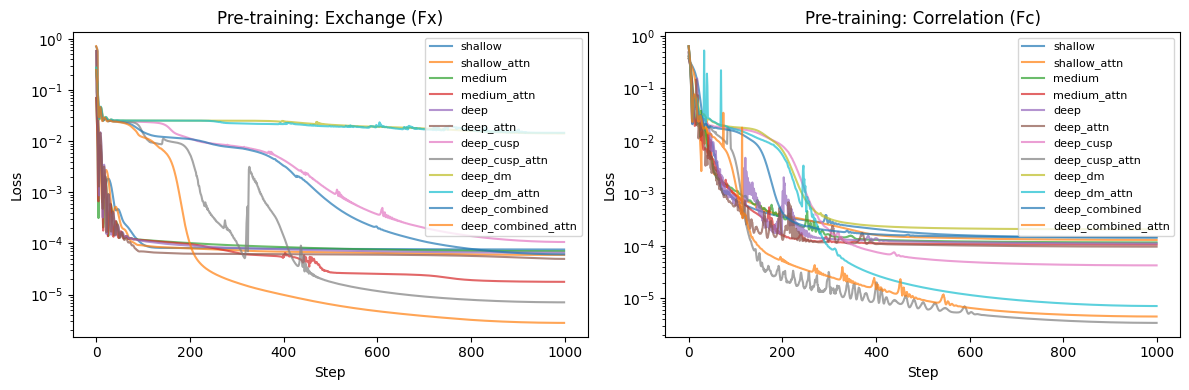

Saved: checkpoints_v3b/pretrain_losses.png


In [13]:
# Plot pre-training losses
if pretrain_losses:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Exchange losses
    ax = axes[0]
    for arch in ARCHITECTURES.keys():
        if arch in pretrain_losses:
            ax.plot(pretrain_losses[arch]['x'], label=arch, alpha=0.7)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Pre-training: Exchange (Fx)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    
    # Correlation losses
    ax = axes[1]
    for arch in ARCHITECTURES.keys():
        if arch in pretrain_losses:
            ax.plot(pretrain_losses[arch]['c'], label=arch, alpha=0.7)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Pre-training: Correlation (Fc)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_BASE, 'pretrain_losses.png'), dpi=150)
    plt.show()
    print(f'Saved: {CHECKPOINT_BASE}/pretrain_losses.png')
else:
    print('No pre-training losses to plot.')

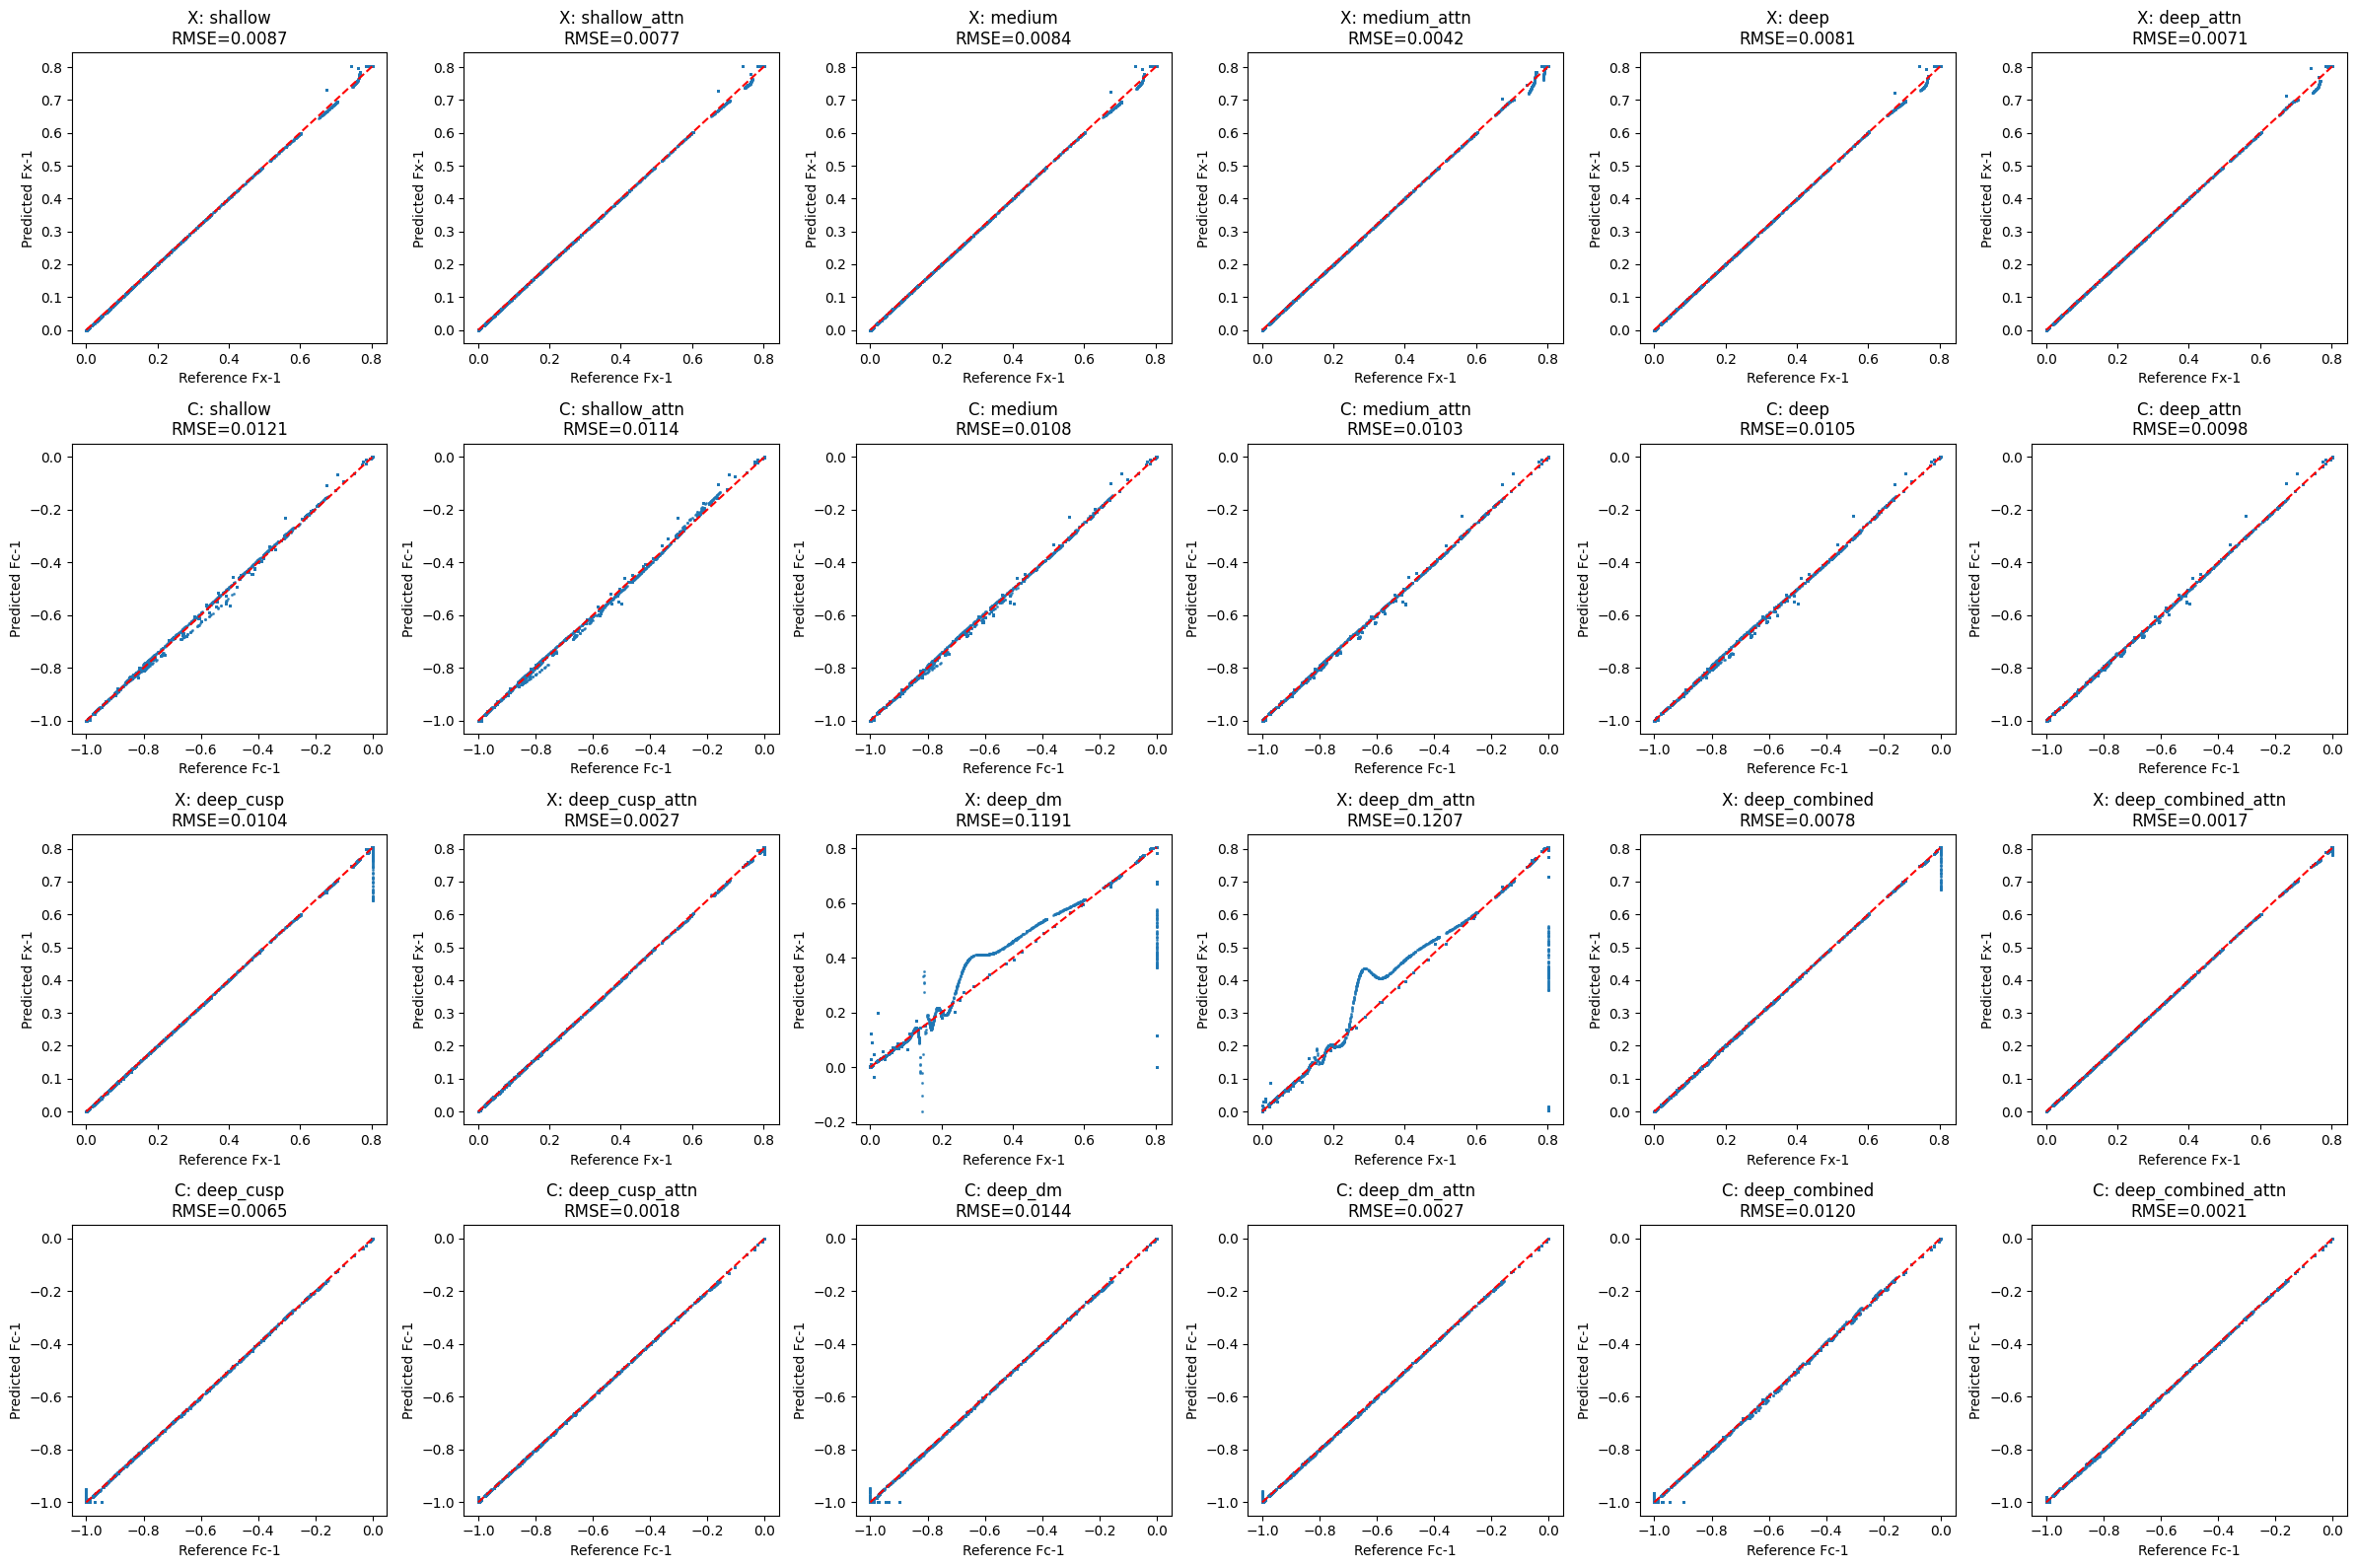

Saved: checkpoints_v3b/01_pretrain/parity_plots.png


In [14]:
# Parity plots for pre-trained networks
if pretrain_losses:
    n_archs = len(ARCHITECTURES)
    n_cols = min(6, n_archs)
    n_rows = 2 * ((n_archs + n_cols - 1) // n_cols)  # 2 rows per row of archs (X and C)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    if n_rows == 2 and n_cols == 1:
        axes = axes.reshape(2, 1)
    elif n_rows == 2:
        axes = axes.reshape(2, -1)
    
    # Compute RMSE for each architecture with appropriate features
    def compute_rmse(net, target, arch_config):
        # Build input with appropriate features
        use_cusp = arch_config.get('use_cusp', False)
        use_dm = arch_config.get('use_dm_features', False)
        
        # Order must match network's __call__ expectation: dm BEFORE cusp
        input_list = [rho_all, sigma_all]
        if use_dm:
            for i in range(dm_all.shape[1]):
                input_list.append(dm_all[:, i])
        if use_cusp:
            input_list.append(cusp_all[:, 0])
            input_list.append(cusp_all[:, 1])
        
        descriptors = jnp.stack(input_list, axis=1)
        pred = jax.vmap(net)(descriptors) - 1.0  # Networks output F, targets are F-1
        return float(jnp.sqrt(jnp.mean((pred - target)**2))), pred
    
    for idx, arch in enumerate(ARCHITECTURES.keys()):
        arch_config = ARCHITECTURES[arch]
        xnet = networks[arch]['xnet']
        cnet = networks[arch]['cnet']
        
        row_base = 2 * (idx // n_cols)
        col = idx % n_cols
        
        # Exchange parity plot
        ax = axes[row_base, col] if n_rows > 2 else axes[0, col]
        rmse_x, pred_x = compute_rmse(xnet, Fx_all, arch_config)
        ax.scatter(Fx_all, pred_x, alpha=0.5, s=1)
        ax.plot([Fx_all.min(), Fx_all.max()], [Fx_all.min(), Fx_all.max()], 'r--')
        ax.set_xlabel('Reference Fx-1')
        ax.set_ylabel('Predicted Fx-1')
        ax.set_title(f'X: {arch}\nRMSE={rmse_x:.4f}')
        
        # Correlation parity plot
        ax = axes[row_base + 1, col] if n_rows > 2 else axes[1, col]
        rmse_c, pred_c = compute_rmse(cnet, Fc_all, arch_config)
        ax.scatter(Fc_all, pred_c, alpha=0.5, s=1)
        ax.plot([Fc_all.min(), Fc_all.max()], [Fc_all.min(), Fc_all.max()], 'r--')
        ax.set_xlabel('Reference Fc-1')
        ax.set_ylabel('Predicted Fc-1')
        ax.set_title(f'C: {arch}\nRMSE={rmse_c:.4f}')
    
    # Hide unused subplots
    for idx in range(n_archs, n_rows // 2 * n_cols):
        row_base = 2 * (idx // n_cols)
        col = idx % n_cols
        if row_base < n_rows:
            axes[row_base, col].set_visible(False)
            axes[row_base + 1, col].set_visible(False)
    
    plt.tight_layout()
    parity_path = os.path.join(CHECKPOINT_DIRS['pretrain'], 'parity_plots.png')
    plt.savefig(parity_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {parity_path}')
else:
    print('No pre-training results for parity plots.')



## 3. Training Data: CCSD Targets, PBE Baseline

**Training molecules:** H, O, H₂O (includes both closed-shell and open-shell)

**Reference Data:**
- **Energy targets:** Literature atomic energies (H, O) and atomization energy (H₂O)
- **DM targets:** CCSD density matrices (for approaches B/D2)
- **Grid density targets:** CCSD electron density on grid (for approaches C/D3)
- **Baseline:** PBE energies, DMs, and densities (for delta-learning)

**Pre-computed Data (stored in `fixed_density_data[name]`):**

| Key | Description | Used In |
|-----|-------------|---------|
| `rho`, `sigma` | PBE density and gradient magnitude | All approaches |
| `weights` | Grid quadrature weights | All approaches |
| `E_non_xc` | Non-XC energy (T + V_ext + J + V_nuc) | Fixed-density energy |
| `dm` | PBE density matrix (RKS: 2D, UKS: 3D) | One-shot (B/C/D2/D3) |
| `hcore` | Core Hamiltonian $h$ | One-shot Fock build |
| `j_pbe` | Coulomb potential $J[D_{PBE}]$ | One-shot Fock build |
| `overlap` | Overlap matrix $S$ | One-shot diagonalization |
| `ao`, `ao_deriv` | AO values and derivatives on grid | V_xc construction |
| `cusp_features` | Nuclear proximity descriptors | Extended architectures |
| `dm_features` | DM structure descriptors | Extended architectures |

**Spin handling:**
- RKS (H₂O): 2D density matrices, shape `(nao, nao)`
- UKS (H, O): 3D density matrices with separate α/β components, shape `(2, nao, nao)`
- DM comparisons preserve spin structure (α and β compared separately for UKS)

In [14]:
# Training systems
H2O_COORDS = '''
O  0.0000  0.0000  0.1173
H  0.0000  0.7572 -0.4692
H  0.0000 -0.7572 -0.4692
'''

mol_H = create_mol('H 0 0 0', spin=1)
mol_O = create_mol('O 0 0 0', spin=2)
mol_H2O = create_mol(H2O_COORDS, spin=0)

mol_H_ad = create_mol_ad('H 0 0 0', spin=1)
mol_O_ad = create_mol_ad('O 0 0 0', spin=2)
mol_H2O_ad = create_mol_ad(H2O_COORDS, spin=0)

training_mols = {'H': mol_H, 'O': mol_O, 'H2O': mol_H2O}
training_mols_ad = {'H': mol_H_ad, 'O': mol_O_ad, 'H2O': mol_H2O_ad}
mol_names = ['H', 'O', 'H2O']
mols_ad_list = [mol_H_ad, mol_O_ad, mol_H2O_ad]

# Overlap matrices
overlaps = {name: mol.intor('int1e_ovlp') for name, mol in training_mols.items()}
print('Created training molecules and overlap matrices')

Created training molecules and overlap matrices


In [15]:
# Compute CCSD references (TARGETS)
# Use pyscf-ad grids for consistency with training
print('Computing CCSD references...')
ccsd_energies = {}
ccsd_dms = {}
ccsd_grid_rho = {}

for name, mol in training_mols.items():
    mol_ad = training_mols_ad[name]
    
    # CCSD energy from regular pyscf
    mf_hf = scf.UHF(mol) if mol.spin else scf.RHF(mol)
    mf_hf.kernel()
    mycc = cc.UCCSD(mf_hf) if mol.spin else cc.CCSD(mf_hf)
    mycc.kernel()
    ccsd_energies[name] = mf_hf.e_tot + mycc.e_corr
    ccsd_dms[name] = mf_hf.make_rdm1()
    
    # Compute CCSD density on pyscf-ad grids
    mf_ad = dft_ad.RKS(mol_ad) if mol_ad.spin == 0 else dft_ad.UKS(mol_ad)
    mf_ad.grids.level = GRID_LEVEL
    mf_ad.grids.build()
    coords = np.array(mf_ad.grids.coords)
    weights = np.array(mf_ad.grids.weights)
    
    ao = mol_ad.eval_gto('GTOval', coords)
    dm = ccsd_dms[name]
    if dm.ndim == 3:
        dm = dm[0] + dm[1]
    rho = np.einsum('ij,pi,pj->p', dm, ao, ao)
    ccsd_grid_rho[name] = {'rho': jnp.array(rho), 'coords': jnp.array(coords), 'weights': jnp.array(weights)}
    print(f'  {name}: {ccsd_energies[name]:.6f} Ha, grid points: {len(rho)}')

AE_ccsd = ccsd_energies['H2O'] - 2*ccsd_energies['H'] - ccsd_energies['O']
print(f'CCSD AE: {AE_ccsd:.6f} Ha = {AE_ccsd*627.509:.2f} kcal/mol')

Computing CCSD references...
converged SCF energy = -0.499278405714347  <S^2> = 0.75  2S+1 = 2
E(UCCSD) = -0.4992784057143474  E_corr = -6.434581506395779e-35
  H: -0.499278 Ha, grid points: 2472
converged SCF energy = -74.7201009237724  <S^2> = 2.0052961  2S+1 = 3.0035287
E(UCCSD) = -74.83824568769788  E_corr = -0.1181447639254989
  O: -74.838246 Ha, grid points: 5184
converged SCF energy = -75.9609839870766
E(CCSD) = -76.17393437345602  E_corr = -0.2129503863793827
  H2O: -76.173934 Ha, grid points: 10128
CCSD AE: -0.337132 Ha = -211.55 kcal/mol


In [16]:
# Compute PBE baseline (for delta-learning) - using pyscf-ad
print('Computing PBE baseline with pyscf-ad...')
pbe_energies = {}
pbe_dms = {}
pbe_grid_rho = {}

for name, mol_ad in training_mols_ad.items():
    mf = dft_ad.UKS(mol_ad) if mol_ad.spin else dft_ad.RKS(mol_ad)
    mf.xc = 'pbe'
    mf.grids.level = GRID_LEVEL
    mf.grids.build()
    e_tot = mf.kernel()
    pbe_energies[name] = float(e_tot)
    pbe_dms[name] = np.array(mf.make_rdm1())
    
    # Compute PBE density on grid
    coords = np.array(mf.grids.coords)
    weights = np.array(mf.grids.weights)
    ao = mol_ad.eval_gto('GTOval', coords)
    dm = mf.make_rdm1()
    if dm.ndim == 3:
        dm = dm[0] + dm[1]
    rho = np.einsum('ij,pi,pj->p', np.array(dm), ao, ao)
    pbe_grid_rho[name] = {'rho': jnp.array(rho), 'coords': jnp.array(coords), 'weights': jnp.array(weights)}
    print(f'  {name}: {pbe_energies[name]:.6f} Ha, grid points: {len(rho)}')

AE_pbe = pbe_energies['H2O'] - 2*pbe_energies['H'] - pbe_energies['O']
print(f'PBE AE: {AE_pbe:.6f} Ha = {AE_pbe*627.509:.2f} kcal/mol')
print(f'Delta (CCSD-PBE): {(AE_ccsd-AE_pbe)*627.509:.2f} kcal/mol')

Computing PBE baseline with pyscf-ad...


/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute coords because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute exp because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute ctr_coeff because it is not JSON-serializable
  warnings.warn(msg)


converged SCF energy = -0.498629446221045  <S^2> = 0.75  2S+1 = 2
  H: -0.498629 Ha, grid points: 2472
converged SCF energy = -74.9146646084324  <S^2> = 2.0018398  2S+1 = 3.0012263
  O: -74.914665 Ha, grid points: 5184
converged SCF energy = -76.2719617970764
  H2O: -76.271962 Ha, grid points: 10128
PBE AE: -0.360038 Ha = -225.93 kcal/mol
Delta (CCSD-PBE): 14.37 kcal/mol


In [17]:
# Literature reference energies (TRAINING TARGETS)
# H: -0.5 Ha (exact)
# O: -75.0673 Ha (high-level reference)
# H2O atomization: ~974.94 kJ/mol
kjMol_to_H = 2625.5
lit_refs = {
    'H_TE': -0.5,
    'O_TE': -75.0673,
    'H2O_AE': -974.94 / kjMol_to_H  # Atomization energy
}

# Store all references
# Energy targets: literature values
# Density targets: CCSD
refs = {
    'ccsd': {'energies': ccsd_energies, 'dms': ccsd_dms, 'AE': AE_ccsd, 'grid_rho': ccsd_grid_rho},
    'pbe': {'energies': pbe_energies, 'dms': pbe_dms, 'AE': AE_pbe, 'grid_rho': pbe_grid_rho},
    'lit': lit_refs,  # Literature reference energies for training
}

# Reference energies for Optimizer: H total, O total, H2O ATOMIZATION (literature values)
ref_energies = jnp.array([lit_refs['H_TE'], lit_refs['O_TE'], lit_refs['H2O_AE']])
print('References stored')
print(f'  Literature refs: H={lit_refs["H_TE"]}, O={lit_refs["O_TE"]}, H2O_AE={lit_refs["H2O_AE"]:.6f} Ha')

References stored
  Literature refs: H=-0.5, O=-75.0673, H2O_AE=-0.371335 Ha


In [18]:
# =============================================================================
# Pre-compute fixed-density training data for BOTH PBE and CCSD densities
# =============================================================================
# For density-aware training, we need features computed on BOTH densities:
# - PBE density: for E_total = E_non_xc + E_xc^NN[ρ_PBE]
# - CCSD density: for density-matching losses
#
# We also pre-compute J[D_PBE] (Coulomb potential) to speed up one-shot calculations.

from xcquinox.features import compute_cusp_descriptor, compute_dm_features_array

print('Pre-computing fixed-density training data (PBE and CCSD)...')

# PBE density data (for energy predictions)
fixed_density_data = {}

# CCSD density data (for density-matching losses)
ccsd_density_data = {}

for name, mol in training_mols.items():
    print(f'  Processing {name}...')
    
    # =========================================================================
    # PBE DENSITY DATA
    # =========================================================================
    mf = dft.UKS(mol) if mol.spin else dft.RKS(mol)
    mf.xc = 'pbe'
    mf.grids.level = GRID_LEVEL
    mf.grids.build()
    mf.kernel()
    
    coords = mf.grids.coords
    weights = mf.grids.weights
    dm_pbe = mf.make_rdm1()  # Original DM (2D for RKS, 3D for UKS)
    overlap = mf.get_ovlp()
    hcore = mf.get_hcore()  # Pre-compute core Hamiltonian
    
    # Pre-compute Coulomb potential J[D_PBE] - this is fixed during one-shot
    # J[D] = sum_kl D_kl (ij|kl)
    j_pbe = mf.get_j(mol, dm_pbe)  # Coulomb matrix from PBE density
    
    ao = mf._numint.eval_ao(mol, coords, deriv=1)
    ao_no_deriv = ao[0]  # AO values without derivatives
    
    # Total DM for density calculations (always 2D)
    if dm_pbe.ndim == 2:
        dm_pbe_tot = dm_pbe
    else:
        dm_pbe_tot = dm_pbe[0] + dm_pbe[1]
    
    # PBE density and gradient
    rho_pbe = np.einsum('pi,ij,pj->p', ao[0], dm_pbe_tot, ao[0])
    drho_x = 2 * np.einsum('pi,ij,pj->p', ao[1], dm_pbe_tot, ao[0])
    drho_y = 2 * np.einsum('pi,ij,pj->p', ao[2], dm_pbe_tot, ao[0])
    drho_z = 2 * np.einsum('pi,ij,pj->p', ao[3], dm_pbe_tot, ao[0])
    sigma_pbe = drho_x**2 + drho_y**2 + drho_z**2
    
    # PBE energy components
    E_tot_pbe = float(mf.e_tot)
    rho_for_xc = mf._numint.eval_rho(mol, ao, dm_pbe_tot, xctype='GGA')
    exc_pbe, _, _, _ = mf._numint.eval_xc('pbe', rho_for_xc, spin=0)
    E_xc_pbe = float(np.sum(rho_pbe * exc_pbe * weights))
    E_non_xc = E_tot_pbe - E_xc_pbe
    
    # PBE cusp and DM features
    nuclear_coords = jnp.array(mol.atom_coords())
    nuclear_charges = jnp.array([mol.atom_charge(i) for i in range(mol.natm)])
    cusp_pbe = compute_cusp_descriptor(jnp.array(coords), nuclear_coords, nuclear_charges)
    dm_feat_global = compute_dm_features_array(jnp.array(dm_pbe_tot), jnp.array(overlap))
    dm_feat_pbe = jnp.tile(dm_feat_global, (len(rho_pbe), 1))
    
    fixed_density_data[name] = {
        'rho': jnp.array(rho_pbe),
        'sigma': jnp.array(sigma_pbe),
        'weights': jnp.array(weights),
        'dm': jnp.array(dm_pbe),           # Original DM (preserves RKS/UKS format)
        'dm_tot': jnp.array(dm_pbe_tot),   # Total DM (always 2D)
        'overlap': jnp.array(overlap),
        'hcore': jnp.array(hcore),         # Core Hamiltonian
        'j_pbe': jnp.array(j_pbe),         # Pre-computed Coulomb J[D_PBE]
        'ao': jnp.array(ao_no_deriv),      # AO values for grid density
        'ao_deriv': jnp.array(ao),         # AO values with derivatives (for vxc)
        'E_tot_pbe': E_tot_pbe,
        'E_xc_pbe': E_xc_pbe,
        'E_non_xc': E_non_xc,
        'cusp_features': cusp_pbe,
        'dm_features': dm_feat_pbe,
        'grid_coords': jnp.array(coords),
        'nuclear_coords': nuclear_coords,
        'nuclear_charges': nuclear_charges,
        'is_unrestricted': mol.spin != 0,
        'nao': mol.nao,
        'nocc': mol.nelectron // 2 if mol.spin == 0 else None,  # For RKS
        'nocc_a': (mol.nelectron + mol.spin) // 2 if mol.spin != 0 else None,  # For UKS alpha
        'nocc_b': (mol.nelectron - mol.spin) // 2 if mol.spin != 0 else None,  # For UKS beta
        'nelec': mol.nelectron,
    }
    
    # =========================================================================
    # CCSD DENSITY DATA (for density-matching)
    # =========================================================================
    dm_ccsd = refs['ccsd']['dms'][name]
    if dm_ccsd.ndim == 3:
        dm_ccsd_tot = dm_ccsd[0] + dm_ccsd[1]
    else:
        dm_ccsd_tot = dm_ccsd
    
    # CCSD density on same grid
    rho_ccsd = np.einsum('pi,ij,pj->p', ao[0], dm_ccsd_tot, ao[0])
    
    ccsd_density_data[name] = {
        'rho': jnp.array(rho_ccsd),
        'weights': jnp.array(weights),
        'dm': jnp.array(dm_ccsd),
        'dm_tot': jnp.array(dm_ccsd_tot),
    }
    
    print(f'    E_tot={E_tot_pbe:.6f}, J_PBE shape={j_pbe.shape}')

print('\nFixed-density data ready!')

Pre-computing fixed-density training data (PBE and CCSD)...
  Processing H...
converged SCF energy = -0.498629446221046  <S^2> = 0.75  2S+1 = 2
    E_tot=-0.498629, J_PBE shape=(2, 5, 5)
  Processing O...
converged SCF energy = -74.9146645101777  <S^2> = 2.0018398  2S+1 = 3.0012263
    E_tot=-74.914665, J_PBE shape=(2, 14, 14)
  Processing H2O...
converged SCF energy = -76.2719617970763
    E_tot=-76.271962, J_PBE shape=(24, 24)

Fixed-density data ready!


In [19]:
# =============================================================================
# Helper functions for training with density prediction (FAST VERSION)
# =============================================================================
# For approaches B/C/D2/D3, we GENERATE a DM via one-shot calculation.
#
# FAST ONE-SHOT: Uses pre-computed quantities to avoid pyscfad overhead:
# 1. h_core: pre-computed
# 2. J[D_PBE]: pre-computed Coulomb potential (fixed during one-shot)  
# 3. V_xc^NN: computed from neural network (the only part that changes)
# 4. Fock = h_core + J[D_PBE] + V_xc^NN
# 5. Diagonalize with JAX (fast, differentiable)

def compute_exc_nn(model, rho, sigma, weights, cusp_features=None, dm_features=None):
    """Compute E_xc using neural network on given density."""
    input_list = [rho, sigma]
    
    if cusp_features is not None:
        input_list.append(cusp_features[:, 0])
        input_list.append(cusp_features[:, 1])
    
    if dm_features is not None:
        for i in range(dm_features.shape[1]):
            input_list.append(dm_features[:, i])
    
    inputs = jnp.stack(input_list, axis=1)
    epsilon = model(inputs)
    E_xc = jnp.sum(epsilon * weights)
    return E_xc


def compute_total_energy_nn(model, name, arch_config=None):
    """Compute total energy with NN XC on fixed PBE density (for approaches A/D1)."""
    data = fixed_density_data[name]
    
    cusp_features = None
    dm_features = None
    if arch_config:
        if arch_config.get('use_cusp', False):
            cusp_features = data['cusp_features']
        if arch_config.get('use_dm_features', False):
            dm_features = data['dm_features']
    
    E_xc_nn = compute_exc_nn(
        model, data['rho'], data['sigma'], data['weights'],
        cusp_features=cusp_features, dm_features=dm_features
    )
    E_total = data['E_non_xc'] + E_xc_nn
    return E_total


def compute_vxc_nn(model, rho, sigma, ao, ao_deriv, weights, arch_config=None, 
                   cusp_features=None, dm_features=None):
    """Compute V_xc matrix from neural network XC functional.
    
    Uses FORWARD-MODE autodiff (jax.jvp) for derivatives to avoid nested reverse-mode AD.
    This computes derivatives inline during the forward pass, which is more numerically
    stable when backpropagating through the loss.
    
    V_xc,ij = ∫ v_rho * φ_i φ_j * w dr + ∫ v_sigma * (∇ρ · ∇(φ_i φ_j)) * w dr
    
    where:
    - v_rho = ∂(ρε)/∂ρ = ε + ρ * ∂ε/∂ρ
    - v_sigma = ∂(ρε)/∂σ = ρ * ∂ε/∂σ
    """
    # Debug: check inputs
    # jax.debug.print("        [vxc] rho: min={mn:.6f} max={mx:.6f}", mn=jnp.min(rho), mx=jnp.max(rho))
    # jax.debug.print("        [vxc] sigma: min={mn:.6f} max={mx:.6f}", mn=jnp.min(sigma), mx=jnp.max(sigma))
    
    ngrids = rho.shape[0]
    
    # Function to compute exc = rho * epsilon for a SINGLE grid point
    # This allows us to use jvp efficiently
    def exc_single_point(rho_val, sigma_val, cusp_vals, dm_vals):
        """Compute rho * epsilon for one grid point."""
        input_list = [rho_val, sigma_val]
        if cusp_vals is not None:
            input_list.extend([cusp_vals[0], cusp_vals[1]])
        if dm_vals is not None:
            for i in range(dm_vals.shape[0]):
                input_list.append(dm_vals[i])
        inp = jnp.array(input_list)
        eps = model(inp)
        return rho_val * eps  # exc = rho * epsilon
    
    def compute_exc_and_derivs_single(rho_val, sigma_val, cusp_vals, dm_vals):
        """Compute exc and its derivatives w.r.t. rho and sigma using forward-mode AD."""
        # Compute exc and d(exc)/d(rho) using jvp with tangent (1, 0, 0, 0)
        primals = (rho_val, sigma_val, cusp_vals, dm_vals)
        
        # Tangent for d/d(rho): only rho component is 1
        tangents_rho = (1.0, 0.0, 
                        jnp.zeros(2) if cusp_vals is not None else None,
                        jnp.zeros(dm_vals.shape[0]) if dm_vals is not None else None)
        exc, d_exc_d_rho = jax.jvp(
            lambda r, s, c, d: exc_single_point(r, s, c, d),
            primals, tangents_rho
        )
        
        # Tangent for d/d(sigma): only sigma component is 1
        tangents_sigma = (0.0, 1.0,
                          jnp.zeros(2) if cusp_vals is not None else None,
                          jnp.zeros(dm_vals.shape[0]) if dm_vals is not None else None)
        _, d_exc_d_sigma = jax.jvp(
            lambda r, s, c, d: exc_single_point(r, s, c, d),
            primals, tangents_sigma
        )
        
        return exc, d_exc_d_rho, d_exc_d_sigma
    
    # Prepare cusp and dm features for vmap
    if cusp_features is not None:
        cusp_per_point = cusp_features  # Shape: (ngrids, 2)
    else:
        cusp_per_point = None
        
    if dm_features is not None:
        dm_per_point = dm_features  # Shape: (ngrids, n_dm_features)
    else:
        dm_per_point = None
    
    # Vectorize over grid points
    # Handle the None cases for vmap
    if cusp_features is None and dm_features is None:
        def compute_single(r, s):
            return compute_exc_and_derivs_single(r, s, None, None)
        exc, v_rho, v_sigma = jax.vmap(compute_single)(rho, sigma)
    elif cusp_features is not None and dm_features is None:
        def compute_single(r, s, c):
            return compute_exc_and_derivs_single(r, s, c, None)
        exc, v_rho, v_sigma = jax.vmap(compute_single)(rho, sigma, cusp_per_point)
    elif cusp_features is None and dm_features is not None:
        def compute_single(r, s, d):
            return compute_exc_and_derivs_single(r, s, None, d)
        exc, v_rho, v_sigma = jax.vmap(compute_single)(rho, sigma, dm_per_point)
    else:
        def compute_single(r, s, c, d):
            return compute_exc_and_derivs_single(r, s, c, d)
        exc, v_rho, v_sigma = jax.vmap(compute_single)(rho, sigma, cusp_per_point, dm_per_point)
    
    # Compute epsilon for debug output
    epsilon = exc / jnp.maximum(rho, 1e-18)
    # jax.debug.print("        [vxc] epsilon: min={mn:.6f} max={mx:.6f}", mn=jnp.min(epsilon), mx=jnp.max(epsilon))
    # jax.debug.print("        [vxc] exc: min={mn:.6f} max={mx:.6f}", mn=jnp.min(exc), mx=jnp.max(exc))
    # jax.debug.print("        [vxc] v_rho: min={mn:.6f} max={mx:.6f}", mn=jnp.min(v_rho), mx=jnp.max(v_rho))
    # jax.debug.print("        [vxc] v_sigma: min={mn:.6f} max={mx:.6f}", mn=jnp.min(v_sigma), mx=jnp.max(v_sigma))
    
    # Build V_xc matrix
    # Term 1: v_rho contribution
    ao0 = ao  # Shape: (ngrids, nao)
    vxc_rho = jnp.einsum('g,gi,gj,g->ij', v_rho, ao0, ao0, weights)
    
    # For now, just use v_rho term (LDA-like approximation for potential)
    # Full GGA would need gradient terms, but this captures the main effect
    vxc = vxc_rho
    # jax.debug.print("        [vxc] vxc: min={mn:.6f} max={mx:.6f}", mn=jnp.min(vxc), mx=jnp.max(vxc))
    
    return vxc

def oneshot_dm_prediction_fast(model, name, arch_config):
    """Fast one-shot DM prediction using pre-computed quantities.
    
    Fock = h_core + J[D_PBE] + V_xc^NN[ρ_PBE]
    
    All quantities except V_xc^NN are pre-computed.
    """
    data = fixed_density_data[name]
    
    # Pre-computed quantities
    hcore = data['hcore']
    j_pbe = data['j_pbe']
    overlap = data['overlap']
    dm_pbe = data['dm']
    rho = data['rho']
    sigma = data['sigma']
    weights = data['weights']
    ao = data['ao']
    ao_deriv = data['ao_deriv']
    is_unrestricted = data['is_unrestricted']
    
    # Get optional features
    cusp_features = data['cusp_features'] if arch_config.get('use_cusp', False) else None
    dm_features = data['dm_features'] if arch_config.get('use_dm_features', False) else None
    
    # Compute V_xc from neural network (the only non-precomputed part)
    vxc = compute_vxc_nn(model, rho, sigma, ao, ao_deriv, weights, arch_config,
                         cusp_features=cusp_features, dm_features=dm_features)
    
    # Build Fock matrix: F = h + J[D_PBE] + V_xc^NN
    if is_unrestricted:
        # UKS case: j_pbe is (2, nao, nao), hcore is (nao, nao), vxc is (nao, nao)
        # Broadcasting handles alpha/beta: each spin gets its own J
        fock = hcore + j_pbe + vxc  # Result: (2, nao, nao)
    else:
        fock = hcore + j_pbe + vxc
    
    # Debug: check Fock matrix
    jax.debug.print("        [diag] fock: min={mn:.6f} max={mx:.6f}", 
                    mn=jnp.min(fock), mx=jnp.max(fock))
    
    # Solve generalized eigenvalue problem: FC = SCε
    # Use Cholesky decomposition: S = LL^T, then solve L^{-1}FL^{-T}C' = C'ε
    # Add small diagonal regularization for numerical stability (prevents ill-conditioning)
    nao = overlap.shape[-1]
    overlap_reg = overlap + 1e-10 * jnp.eye(nao)
    L = jnp.linalg.cholesky(overlap_reg)
    L_inv = jax.scipy.linalg.solve_triangular(L, jnp.eye(nao), lower=True)
    
    # Debug: check Cholesky and NaN detection
    jax.debug.print("        [diag] L: min={mn:.6f} max={mx:.6f} nans={nans}", 
                    mn=jnp.min(L), mx=jnp.max(L), nans=jnp.sum(jnp.isnan(L)))
    jax.debug.print("        [diag] L_inv: min={mn:.6f} max={mx:.6f} nans={nans}", 
                    mn=jnp.min(L_inv), mx=jnp.max(L_inv), nans=jnp.sum(jnp.isnan(L_inv)))
    
    if is_unrestricted:
        # Transform Fock matrices to orthogonal basis
        fock_orth_a = L_inv @ fock[0] @ L_inv.T
        fock_orth_b = L_inv @ fock[1] @ L_inv.T
        
        # jax.debug.print("        [diag] fock_orth_a: min={mn:.6f} max={mx:.6f}", 
        #                 mn=jnp.min(fock_orth_a), mx=jnp.max(fock_orth_a))
        
        # Diagonalize with small perturbation to break degeneracies
        fock_orth_a = fock_orth_a + 1e-10 * jnp.eye(nao)
        fock_orth_b = fock_orth_b + 1e-10 * jnp.eye(nao)
        mo_energy_a, mo_coeff_orth_a = jnp.linalg.eigh(fock_orth_a)
        mo_energy_b, mo_coeff_orth_b = jnp.linalg.eigh(fock_orth_b)
        
        # NaN detection for eigendecomposition
        jax.debug.print("        [eigh] mo_energy_a nans={nans}", nans=jnp.sum(jnp.isnan(mo_energy_a)))
        jax.debug.print("        [eigh] mo_coeff_a nans={nans}", nans=jnp.sum(jnp.isnan(mo_coeff_orth_a)))
        
        # jax.debug.print("        [diag] mo_energy_a: min={mn:.6f} max={mx:.6f}", 
        #                 mn=jnp.min(mo_energy_a), mx=jnp.max(mo_energy_a))
        
        # Back-transform MO coefficients
        mo_coeff_a = L_inv.T @ mo_coeff_orth_a
        mo_coeff_b = L_inv.T @ mo_coeff_orth_b
        
        # Build density matrix from occupied orbitals
        nocc_a = int(data['nocc_a'])
        nocc_b = int(data['nocc_b'])
        
        # jax.debug.print("        [diag] mo_coeff_a shape: {s}", s=mo_coeff_a.shape)
        # jax.debug.print("        [diag] nocc_a={na}, nocc_b={nb}", na=nocc_a, nb=nocc_b)
        # jax.debug.print("        [diag] mo_coeff_a[:, :nocc_a] shape: {s}", s=mo_coeff_a[:, :nocc_a].shape)
        
        dm_a = mo_coeff_a[:, :nocc_a] @ mo_coeff_a[:, :nocc_a].T
        dm_b = mo_coeff_b[:, :nocc_b] @ mo_coeff_b[:, :nocc_b].T
        dm_pred = jnp.stack([dm_a, dm_b])
    else:
        # Transform Fock matrix to orthogonal basis
        fock_orth = L_inv @ fock @ L_inv.T
        
        # jax.debug.print("        [diag] fock_orth: min={mn:.6f} max={mx:.6f}", 
        #                 mn=jnp.min(fock_orth), mx=jnp.max(fock_orth))
        
        # Add small perturbation to break degeneracies
        fock_orth = fock_orth + 1e-10 * jnp.eye(nao)
        mo_energy, mo_coeff_orth = jnp.linalg.eigh(fock_orth)
        
        # NaN detection for eigendecomposition
        jax.debug.print("        [eigh] mo_energy nans={nans}", nans=jnp.sum(jnp.isnan(mo_energy)))
        jax.debug.print("        [eigh] mo_coeff nans={nans}", nans=jnp.sum(jnp.isnan(mo_coeff_orth)))
        
        mo_coeff = L_inv.T @ mo_coeff_orth
        
        # jax.debug.print("        [diag] mo_coeff: min={mn:.6f} max={mx:.6f}", 
        #                 mn=jnp.min(mo_coeff), mx=jnp.max(mo_coeff))
        
        # Build density matrix from occupied orbitals (closed shell: 2 electrons per orbital)
        nocc = int(data['nocc'])
        dm_pred = 2.0 * mo_coeff[:, :nocc] @ mo_coeff[:, :nocc].T
    
    # jax.debug.print("        [diag] dm_pred: min={mn:.6f} max={mx:.6f}", 
    #                 mn=jnp.min(dm_pred), mx=jnp.max(dm_pred))
    
    # Also compute predicted energy
    E_pred = compute_total_energy_nn(model, name, arch_config)
    
    return dm_pred, E_pred

def oneshot_grid_density(model, name, arch_config):
    """One-shot grid density prediction."""
    dm_pred, E_pred = oneshot_dm_prediction(model, name, arch_config)
    
    ao = fixed_density_data[name]['ao']
    
    if dm_pred.ndim == 3:
        dm_tot = dm_pred[0] + dm_pred[1]
    else:
        dm_tot = dm_pred
    
    rho_pred = jnp.einsum('pi,ij,pj->p', ao, dm_tot, ao)
    
    return rho_pred, dm_pred, E_pred


print('Fast helper functions defined:')
print('  - compute_vxc_nn: V_xc matrix from neural network')
print('  - oneshot_dm_prediction_fast: Uses pre-computed J[D_PBE]')
print('  - No pyscfad calls during training!')

oneshot_dm_prediction = oneshot_dm_prediction_fast


Fast helper functions defined:
  - compute_vxc_nn: V_xc matrix from neural network
  - oneshot_dm_prediction_fast: Uses pre-computed J[D_PBE]
  - No pyscfad calls during training!


In [20]:
# Approach A: Atomization Energy Only (Fixed-Density)
def make_loss_A_ae_only(arch_config):
    """Create AE-only loss for given architecture config."""
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        """AE loss with literature targets using fixed PBE density."""
        # Compute energies using fixed density (with appropriate features)
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        
        # Relative squared error
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        # Weak atomic regularization
        H_loss = (E_H - refs['lit']['H_TE'])**2 / (refs['lit']['H_TE']**2 + 1e-8)
        O_loss = (E_O - refs['lit']['O_TE'])**2 / (refs['lit']['O_TE']**2 + 1e-8)
        atomic_loss = H_loss + O_loss
        
        total_loss = ae_loss + 0.01 * atomic_loss
        
        # NaN detection
        jax.debug.print("    [A] E_H={h:.6f} E_O={o:.6f} E_H2O={w:.6f} nans={n}", 
                        h=E_H, o=E_O, w=E_H2O, n=jnp.isnan(total_loss).astype(jnp.int32))
        
        return total_loss
    return loss_fn

print('Defined make_loss_A_ae_only (fixed-density, arch-aware)')



Defined make_loss_A_ae_only (fixed-density, arch-aware)


In [21]:
# Approach B: AE + Density Matrix Matching (One-Shot)
# =============================================================================
# The network GENERATES a DM via one-shot calculation, which is compared to CCSD.
#
# MECHANISM:
# 1. Build Fock matrix using NN XC functional on current density
# 2. Diagonalize ONCE to get predicted DM
# 3. Compare predicted DM to CCSD DM (preserving spin structure for UKS)
# 4. Backpropagate through diagonalization to train network
#
# Loss = AE_loss + λ * Σ_mol ||D_pred - D_CCSD||²_F
#
# This trains the network to produce XC potentials that yield CCSD-like DMs.
# For UKS (open-shell), alpha and beta DMs are compared separately.
#
# NOTE: Atoms are excluded from DM matching by default due to degenerate
# eigenvalues causing gradient instability (see dm_prediction_fix_plans.md).
# =============================================================================

# Systems with degenerate orbitals (atoms) - excluded from DM matching
ATOMIC_SYSTEMS = {'H', 'O', 'C', 'N', 'F', 'S', 'Cl', 'He', 'Ne', 'Ar'}

def make_loss_B_ae_dm(arch_config, dm_weight=0.1, molecules_only=True):
    """AE + DM matching loss using one-shot DM prediction.
    
    Args:
        arch_config: Architecture configuration dict
        dm_weight: Weight for DM matching loss (default 0.1)
        molecules_only: If True, only match DMs for molecules, skip atoms.
                       Atoms have degenerate eigenvalues that cause unstable
                       gradients through eigh. (default True)
    """
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # === Atomization Energy (fixed-density for efficiency) ===
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        jax.debug.print("    E_H={h:.6f}, E_O={o:.6f}, E_H2O={w:.6f}", h=E_H, o=E_O, w=E_H2O)
        
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        jax.debug.print("    AE_pred={ae:.6f}, ae_loss={l:.6f}", ae=AE_pred, l=ae_loss)
        
        # === DM Matching (one-shot prediction) ===
        # Skip atomic systems if molecules_only=True to avoid gradient instability
        dm_loss = 0.0
        dm_count = 0
        for idx, (name, mol) in enumerate(training_mols.items()):
            # Skip atomic systems (have degenerate eigenvalues)
            if molecules_only and name in ATOMIC_SYSTEMS:
                jax.debug.print("    Skipping {n} (atomic, degenerate eigenvalues)", n=name)
                continue
            
            jax.debug.print("    Processing {n} for DM matching...", n=name)
            
            # One-shot: get predicted DM from network (preserves RKS/UKS format)
            dm_pred, E_pred = oneshot_dm_prediction(model, name, arch_config)
            
            jax.debug.print("      {n}: E_pred={e:.6f}, dm_pred min={mn:.6f} max={mx:.6f}",
                           n=name, e=E_pred, mn=jnp.min(dm_pred), mx=jnp.max(dm_pred))
            
            # Target: CCSD DM (same format as PBE)
            dm_ccsd = refs['ccsd']['dms'][name]
            
            # Compare DMs preserving spin structure
            # Normalize by matrix size for consistent weighting across systems
            dm_diff = dm_pred - dm_ccsd
            nao = dm_ccsd.shape[-1]
            mol_dm_loss = jnp.sum(dm_diff**2) / (nao * nao)
            dm_loss += mol_dm_loss
            dm_count += 1
            
            jax.debug.print("      {n}: dm_loss={l:.6f} (normalized)", n=name, l=mol_dm_loss)
        
        # Average DM loss over molecules processed (avoid division by zero)
        dm_loss = jnp.where(dm_count > 0, dm_loss / dm_count, 0.0)
        
        total_loss = ae_loss + dm_weight * dm_loss
        
        jax.debug.print("  TOTAL: ae_loss={a:.6f}, dm_loss={d:.6f}, total={t:.6f}",
                       a=ae_loss, d=dm_loss, t=total_loss)
        jax.debug.print("  AE err: {e:.2f} kcal/mol", e=(AE_pred-AE_target)*627.509)
        
        return total_loss
    return loss_fn

print('Defined make_loss_B_ae_dm:')
print('  - molecules_only=True by default (skips atoms)')
print('  - DM loss normalized by matrix size')
print('  - Atoms excluded due to degenerate eigenvalue gradients')

Defined make_loss_B_ae_dm:
  - molecules_only=True by default (skips atoms)
  - DM loss normalized by matrix size
  - Atoms excluded due to degenerate eigenvalue gradients


In [22]:
# Approach C: AE + Grid Density Matching (One-Shot)
# =============================================================================
# The network GENERATES a grid density via one-shot calculation, compared to CCSD.
#
# MECHANISM:
# 1. One-shot calculation to get predicted DM
# 2. Evaluate density on grid: ρ_pred(r) = Σ_ij D_ij φ_i(r) φ_j(r)
# 3. Compare to CCSD grid density
# 4. Backpropagate to train network
#
# Loss = AE_loss + λ * Σ_mol ∫ w(r) |ρ_pred(r) - ρ_CCSD(r)|² dr
#
# This trains the network to produce XC potentials that yield CCSD-like densities.
#
# NOTE: Atoms are excluded from grid density matching by default due to degenerate
# eigenvalues causing gradient instability (see dm_prediction_fix_plans.md).
# =============================================================================

def make_loss_C_ae_grid(arch_config, density_weight=0.1, molecules_only=True):
    """AE + Grid density matching loss using one-shot prediction.
    
    Args:
        arch_config: Architecture configuration dict
        density_weight: Weight for grid density matching loss (default 0.1)
        molecules_only: If True, only match densities for molecules, skip atoms.
                       Atoms have degenerate eigenvalues that cause unstable
                       gradients through eigh. (default True)
    """
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # === Atomization Energy (fixed-density) ===
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        # === Grid Density Matching (one-shot) ===
        # Skip atomic systems if molecules_only=True to avoid gradient instability
        grid_loss = 0.0
        grid_count = 0
        for idx, (name, mol) in enumerate(training_mols.items()):
            # Skip atomic systems (have degenerate eigenvalues)
            if molecules_only and name in ATOMIC_SYSTEMS:
                jax.debug.print("    Skipping {n} (atomic, degenerate eigenvalues)", n=name)
                continue
            
            # One-shot: get predicted grid density
            rho_pred, _, _ = oneshot_grid_density(model, name, arch_config)
            
            # Target: CCSD grid density
            rho_ccsd = ccsd_density_data[name]['rho']
            weights = fixed_density_data[name]['weights']
            
            # Weighted squared difference
            rho_diff = rho_pred - rho_ccsd
            grid_loss += jnp.sum(weights * rho_diff**2)
            grid_count += 1
        
        # Average over molecules processed
        grid_loss = jnp.where(grid_count > 0, grid_loss / grid_count, 0.0)
        
        total_loss = ae_loss + density_weight * grid_loss
        
        jax.debug.print("  AE err: {e:.2f} kcal/mol, Grid loss: {g:.6f}",
                       e=(AE_pred-AE_target)*627.509, g=grid_loss)
        
        return total_loss
    return loss_fn

print('Defined make_loss_C_ae_grid:')
print('  - molecules_only=True by default (skips atoms)')
print('  - Grid loss averaged over molecules processed')

Defined make_loss_C_ae_grid:
  - molecules_only=True by default (skips atoms)
  - Grid loss averaged over molecules processed


In [23]:
# Approach D1: Delta-Learning Energy Only (Fixed-Density)
def make_loss_D1_delta_e(arch_config):
    """Create delta-E loss for given architecture config."""
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        """Delta loss: E_NN - E_PBE ≈ E_lit - E_PBE, using fixed density."""
        # Compute energies using fixed density
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_nn = E_H2O - 2*E_H - E_O
        
        delta_nn = AE_nn - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']
        
        delta_loss = (delta_nn - delta_target)**2 / (delta_target**2 + 1e-8)
        
        # Weak atomic regularization
        H_loss = (E_H - refs['lit']['H_TE'])**2 / (refs['lit']['H_TE']**2 + 1e-8)
        O_loss = (E_O - refs['lit']['O_TE'])**2 / (refs['lit']['O_TE']**2 + 1e-8)
        atomic_loss = H_loss + O_loss
        
        total_loss = delta_loss + 0.01 * atomic_loss
        
        return total_loss
    return loss_fn

print('Defined make_loss_D1_delta_e (fixed-density, arch-aware)')



Defined make_loss_D1_delta_e (fixed-density, arch-aware)


In [24]:
# Approach D2: Delta-E + Delta-DM (One-Shot)
# =============================================================================
# Delta-learning formulation with DM matching.
#
# Energy: Minimize |(AE_pred - AE_PBE) - (AE_lit - AE_PBE)|²
# DM: Minimize ||D_pred - D_CCSD||²_F (preserving spin structure for UKS)
#
# NOTE: Atoms are excluded from DM matching by default due to degenerate
# eigenvalues causing gradient instability (see dm_prediction_fix_plans.md).
# =============================================================================

def make_loss_D2_delta_dm(arch_config, dm_weight=0.1, molecules_only=True):
    """Delta-E + DM matching loss using one-shot prediction.
    
    Args:
        arch_config: Architecture configuration dict
        dm_weight: Weight for DM matching loss (default 0.1)
        molecules_only: If True, only match DMs for molecules, skip atoms.
                       Atoms have degenerate eigenvalues that cause unstable
                       gradients through eigh. (default True)
    """
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # === Delta Energy ===
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_pred = E_H2O - 2*E_H - E_O
        delta_pred = AE_pred - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']
        delta_loss = (delta_pred - delta_target)**2 / (delta_target**2 + 1e-8)
        
        # === DM Matching (one-shot, preserves spin structure) ===
        # Skip atomic systems if molecules_only=True to avoid gradient instability
        dm_loss = 0.0
        dm_count = 0
        for idx, (name, mol) in enumerate(training_mols.items()):
            # Skip atomic systems (have degenerate eigenvalues)
            if molecules_only and name in ATOMIC_SYSTEMS:
                jax.debug.print("    Skipping {n} (atomic, degenerate eigenvalues)", n=name)
                continue
            
            dm_pred, _ = oneshot_dm_prediction(model, name, arch_config)
            dm_ccsd = refs['ccsd']['dms'][name]
            
            # Compare preserving spin structure (works for both 2D and 3D)
            # Normalize by matrix size for consistent weighting
            dm_diff = dm_pred - dm_ccsd
            nao = dm_ccsd.shape[-1]
            mol_dm_loss = jnp.sum(dm_diff**2) / (nao * nao)
            dm_loss += mol_dm_loss
            dm_count += 1
        
        # Average DM loss over molecules processed
        dm_loss = jnp.where(dm_count > 0, dm_loss / dm_count, 0.0)
        
        total_loss = delta_loss + dm_weight * dm_loss
        
        jax.debug.print("  Delta err: {e:.2f} kcal/mol, DM loss: {d:.6f}",
                       e=(delta_pred-delta_target)*627.509, d=dm_loss)
        
        return total_loss
    return loss_fn

print('Defined make_loss_D2_delta_dm:')
print('  - Delta energy + one-shot DM matching')
print('  - molecules_only=True by default (skips atoms)')
print('  - DM loss normalized by matrix size')

Defined make_loss_D2_delta_dm:
  - Delta energy + one-shot DM matching
  - molecules_only=True by default (skips atoms)
  - DM loss normalized by matrix size


In [25]:
# Approach D3: Delta-E + Delta-Grid Density (One-Shot)
# =============================================================================
# Delta-learning formulation with grid density matching.
#
# Energy: Minimize |(AE_pred - AE_PBE) - (AE_lit - AE_PBE)|²
# Density: Minimize ∫ w(r) |ρ_pred(r) - ρ_CCSD(r)|² dr
#
# NOTE: Atoms are excluded from grid density matching by default due to degenerate
# eigenvalues causing gradient instability (see dm_prediction_fix_plans.md).
# =============================================================================

def make_loss_D3_delta_grid(arch_config, density_weight=0.1, molecules_only=True):
    """Delta-E + Grid density matching loss using one-shot prediction.
    
    Args:
        arch_config: Architecture configuration dict
        density_weight: Weight for grid density matching loss (default 0.1)
        molecules_only: If True, only match densities for molecules, skip atoms.
                       Atoms have degenerate eigenvalues that cause unstable
                       gradients through eigh. (default True)
    """
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # === Delta Energy ===
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_pred = E_H2O - 2*E_H - E_O
        delta_pred = AE_pred - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']
        delta_loss = (delta_pred - delta_target)**2 / (delta_target**2 + 1e-8)
        
        # === Grid Density Matching (one-shot) ===
        # Skip atomic systems if molecules_only=True to avoid gradient instability
        grid_loss = 0.0
        grid_count = 0
        for idx, (name, mol) in enumerate(training_mols.items()):
            # Skip atomic systems (have degenerate eigenvalues)
            if molecules_only and name in ATOMIC_SYSTEMS:
                jax.debug.print("    Skipping {n} (atomic, degenerate eigenvalues)", n=name)
                continue
            
            rho_pred, _, _ = oneshot_grid_density(model, name, arch_config)
            rho_ccsd = ccsd_density_data[name]['rho']
            weights = fixed_density_data[name]['weights']
            rho_diff = rho_pred - rho_ccsd
            grid_loss += jnp.sum(weights * rho_diff**2)
            grid_count += 1
        
        # Average over molecules processed
        grid_loss = jnp.where(grid_count > 0, grid_loss / grid_count, 0.0)
        
        total_loss = delta_loss + density_weight * grid_loss
        
        jax.debug.print("  Delta err: {e:.2f} kcal/mol, Grid loss: {g:.6f}",
                       e=(delta_pred-delta_target)*627.509, g=grid_loss)
        
        return total_loss
    return loss_fn

print('Defined make_loss_D3_delta_grid:')
print('  - Delta energy + one-shot grid density matching')
print('  - molecules_only=True by default (skips atoms)')

Defined make_loss_D3_delta_grid:
  - Delta energy + one-shot grid density matching
  - molecules_only=True by default (skips atoms)


## 5. Training All Approaches × All Architectures

Training 72 models: 12 architectures × 6 approaches.

### Approach Summary

| Approach | Energy Loss | Density Loss | Total Loss |
|----------|-------------|--------------|------------|
| **A** | $(AE_{pred} - AE_{lit})^2$ | None | $\mathcal{L}_{AE}$ |
| **B** | $(AE_{pred} - AE_{lit})^2$ | $\|D_{pred} - D_{CCSD}\|_F^2$ | $\mathcal{L}_{AE} + \lambda_{DM} \cdot \mathcal{L}_{DM}$ |
| **C** | $(AE_{pred} - AE_{lit})^2$ | $\int w |\rho_{pred} - \rho_{CCSD}|^2$ | $\mathcal{L}_{AE} + \lambda_\rho \cdot \mathcal{L}_\rho$ |
| **D1** | $(\Delta AE_{pred} - \Delta AE_{lit})^2$ | None | $\mathcal{L}_{\Delta E}$ |
| **D2** | $(\Delta AE_{pred} - \Delta AE_{lit})^2$ | $\|D_{pred} - D_{CCSD}\|_F^2$ | $\mathcal{L}_{\Delta E} + \lambda_{DM} \cdot \mathcal{L}_{DM}$ |
| **D3** | $(\Delta AE_{pred} - \Delta AE_{lit})^2$ | $\int w |\rho_{pred} - \rho_{CCSD}|^2$ | $\mathcal{L}_{\Delta E} + \lambda_\rho \cdot \mathcal{L}_\rho$ |

Where $\Delta AE = AE_{pred} - AE_{PBE}$ (delta-learning formulation).

### Fast One-Shot Mechanism (Pure JAX, No pyscfad)

**Pre-computed (before training):**
- `hcore`: Core Hamiltonian
- `j_pbe`: Coulomb potential from PBE density  
- `overlap`: Overlap matrix S
- `ao`, `ao_deriv`: AO values and derivatives on grid

**During training (differentiable):**

1. **Compute V_xc from NN:**
   - Forward pass: $\varepsilon_{xc} = NN(\rho, \sigma, ...)$
   - Forward-mode autodiff: $v_\rho = \partial(\rho\varepsilon)/\partial\rho$
   - Build matrix: $V_{xc,ij} = \sum_g w_g \cdot v_\rho(\mathbf{r}_g) \cdot \phi_i(\mathbf{r}_g) \cdot \phi_j(\mathbf{r}_g)$
  
2. **Build Fock matrix:** $F = h + J[D_{PBE}] + V_{xc}^{NN}$
  
3. **Solve eigenvalue problem:**
   - Cholesky: $S = LL^T$, compute $L^{-1}$
   - Transform: $F' = L^{-1} F L^{-T}$
   - Diagonalize: $F' C' = C' \varepsilon$
   - Back-transform: $C = L^{-T} C'$
  
4. **Form predicted DM:**
   - RKS: $D_{pred} = 2 \cdot C_{occ} \cdot C_{occ}^T$
   - UKS: Separate $D_\alpha$, $D_\beta$

**Speed: ~100× faster than pyscfad** (all heavy integrals pre-computed)

In [26]:
def train_architecture(arch_name, loss_fn, approach_name, steps=25):
    """Train one architecture with given loss function."""
    xnet = networks[arch_name]['xnet']
    cnet = networks[arch_name]['cnet']
    arch_config = ARCHITECTURES[arch_name]
    
    # Use extended model for architectures with cusp/DM features
    if arch_config.get('use_cusp', False) or arch_config.get('use_dm_features', False):
        xcmodel = RXCModel_GGA_extended(xnet=xnet, cnet=cnet)
    else:
        xcmodel = RXCModel_GGA(xnet=xnet, cnet=cnet)
    
    # Use gradient clipping to prevent explosion
    # Lower learning rate (1e-4) for stability with large loss values
    optim = optax.chain(
        optax.clip_by_global_norm(1.0),  # Clip gradients with norm > 1.0
        optax.adam(1e-4)  # Lower learning rate for stability
    )
    
    optimizer = xce.train.Optimizer(
        model=xcmodel,
        optim=optim,
        mols=mols_ad_list,
        refs=ref_energies,
        loss=loss_fn,
        steps=steps,
        print_every=5
    )
    
    xcmodel_trained, losses = optimizer()
    
    # NaN tracking summary
    nan_count = sum(1 for l in losses if np.isnan(l))
    inf_count = sum(1 for l in losses if np.isinf(l))
    if nan_count > 0 or inf_count > 0:
        print(f'    WARNING: {nan_count} NaN losses, {inf_count} Inf losses detected')
    
    # Save checkpoint to proper directory
    arch_dir = os.path.join(CHECKPOINT_DIRS[approach_name], arch_name)
    
    # Save full xcmodel
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xcmodel.eqx'), xcmodel_trained)
    
    # Save individual networks
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xnet.eqx'), xcmodel_trained.xnet)
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'cnet.eqx'), xcmodel_trained.cnet)
    
    # Save losses
    np.save(os.path.join(arch_dir, 'losses.npy'), np.array(losses))
    
    print(f'    Saved to: {arch_dir}')
    
    # Clear memory after each architecture to prevent accumulation
    clear_memory()
    
    return xcmodel_trained, losses

print('Defined train_architecture function (with gradient clipping)')

Defined train_architecture function (with gradient clipping)


## 5b. Parallel Training (Optional)

The following cells enable **system-conscious parallel training** for overnight runs:

### Resource Allocation

| Phase | Approaches | Max Workers | Memory/Job | Reason |
|-------|------------|-------------|------------|--------|
| Fixed-density | A, D1 | 4 | ~3 GB | No one-shot overhead |
| One-shot DM | B, D2 | 3 | ~5 GB | DM storage |
| One-shot Grid | C, D3 | 2 | ~6 GB | Grid density arrays |

### Output Structure

Each job saves to `CHECKPOINT_DIRS[approach]/arch_name/`:
- `xcmodel.eqx` - Full trained model
- `xnet.eqx`, `cnet.eqx` - Individual networks
- `losses.npy` - Training loss history
- `metadata.json` - Training metadata (time, final loss, etc.)

A summary JSON is saved to `CHECKPOINT_BASE/training_summary.json` for figure generation.

### Usage

1. Run the "Save pre-computed data" cell first
2. Choose `RUN_MODE`:
   - `'sequential_phases'`: Safest, runs phases one at a time
   - `'all_parallel'`: Maximum parallelism (2 workers)
3. Run the parallel training cell

For overnight runs, use `sequential_phases` mode.


In [27]:
# =============================================================================
# Save pre-computed data for parallel training workers
# =============================================================================
# Each parallel worker process needs access to:
# - fixed_density_data: PBE density, grids, matrices for one-shot
# - ccsd_density_data: CCSD reference densities
# - refs: Reference energies (literature, PBE, CCSD)
# - pretrained networks: Starting point for fine-tuning
# - ARCHITECTURES config
#
# We save everything to disk so workers can load independently.

import pickle
import os

PARALLEL_DATA_DIR = os.path.join(CHECKPOINT_BASE, 'parallel_data')
os.makedirs(PARALLEL_DATA_DIR, exist_ok=True)

# Save fixed density data (convert JAX arrays to numpy for pickling)
def jax_to_numpy_dict(d):
    """Recursively convert JAX arrays to numpy."""
    result = {}
    for k, v in d.items():
        if hasattr(v, 'numpy'):
            result[k] = np.array(v)
        elif isinstance(v, dict):
            result[k] = jax_to_numpy_dict(v)
        else:
            result[k] = v
    return result

print('Saving pre-computed data for parallel workers...')

# Fixed density data
fixed_data_np = {name: jax_to_numpy_dict(data) for name, data in fixed_density_data.items()}
with open(os.path.join(PARALLEL_DATA_DIR, 'fixed_density_data.pkl'), 'wb') as f:
    pickle.dump(fixed_data_np, f)
print(f'  Saved fixed_density_data ({len(fixed_density_data)} molecules)')

# CCSD density data
ccsd_data_np = {name: jax_to_numpy_dict(data) for name, data in ccsd_density_data.items()}
with open(os.path.join(PARALLEL_DATA_DIR, 'ccsd_density_data.pkl'), 'wb') as f:
    pickle.dump(ccsd_data_np, f)
print(f'  Saved ccsd_density_data ({len(ccsd_density_data)} molecules)')

# References (already numpy-compatible)
with open(os.path.join(PARALLEL_DATA_DIR, 'refs.pkl'), 'wb') as f:
    pickle.dump(refs, f)
print('  Saved refs')

# Training molecules (just the names/configs, not pyscf objects)
training_mol_configs = {
    'H': {'atoms': 'H 0 0 0', 'spin': 1, 'basis': '6-311+g**'},
    'O': {'atoms': 'O 0 0 0', 'spin': 2, 'basis': '6-311+g**'},
    'H2O': {'atoms': 'O 0 0 0; H 0.96 0 0; H -0.24 0.93 0', 'spin': 0, 'basis': '6-311+g**'},
}
with open(os.path.join(PARALLEL_DATA_DIR, 'training_mol_configs.pkl'), 'wb') as f:
    pickle.dump(training_mol_configs, f)
print('  Saved training_mol_configs')

# Architecture configs
with open(os.path.join(PARALLEL_DATA_DIR, 'architectures.pkl'), 'wb') as f:
    pickle.dump(ARCHITECTURES, f)
print(f'  Saved ARCHITECTURES ({len(ARCHITECTURES)} architectures)')

# Save pre-trained network weights (already saved during pre-training, just record paths)
pretrained_paths = {}
for arch in ARCHITECTURES.keys():
    arch_dir = os.path.join(CHECKPOINT_DIRS['pretrain'], arch)
    pretrained_paths[arch] = {
        'xnet': os.path.join(arch_dir, 'xnet.eqx'),
        'cnet': os.path.join(arch_dir, 'cnet.eqx'),
    }
with open(os.path.join(PARALLEL_DATA_DIR, 'pretrained_paths.pkl'), 'wb') as f:
    pickle.dump(pretrained_paths, f)
print('  Saved pretrained_paths')

# Save checkpoint directory structure
with open(os.path.join(PARALLEL_DATA_DIR, 'checkpoint_dirs.pkl'), 'wb') as f:
    pickle.dump(CHECKPOINT_DIRS, f)
print('  Saved checkpoint_dirs')

print(f'\nAll data saved to: {PARALLEL_DATA_DIR}')
print('Ready for parallel training.')


Saving pre-computed data for parallel workers...
  Saved fixed_density_data (3 molecules)
  Saved ccsd_density_data (3 molecules)
  Saved refs
  Saved training_mol_configs
  Saved ARCHITECTURES (12 architectures)
  Saved pretrained_paths
  Saved checkpoint_dirs

All data saved to: checkpoints_v3b/parallel_data
Ready for parallel training.


In [28]:
# ============================================================================
# Cell 36: Parallel Training Infrastructure
# ============================================================================
# Run parallel training using subprocess workers for process isolation.
# Each worker gets its own JAX process to avoid memory fragmentation.

import subprocess
import json
import sys
import threading
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
from datetime import datetime

# Parallelization settings by approach type
# Different approaches have different memory requirements
MAX_WORKERS_FIXED = 4         # A, D1: fixed density (lowest memory)
MAX_WORKERS_ONESHOT_DM = 3    # B, D2: one-shot DM prediction (medium memory)
MAX_WORKERS_ONESHOT_GRID = 2  # C, D3: one-shot grid density (highest memory)
THREADS_PER_WORKER = 4        # Threads per JAX process

# Learning rate configuration
# Uses linear schedule: starts at LR_START, decays to LR_END over training
# LR_DECAY_START controls when decay begins (0.0 = immediate, 0.5 = halfway through training)
LR_START = 1e-2               # Initial learning rate
LR_END = 1e-5                 # Final learning rate
LR_DECAY_START = 0.2          # Fraction of training before decay starts (0.0-1.0)
GRAD_CLIP = 1.0               # Gradient clipping norm

# Path to the worker script
WORKER_SCRIPT = '/home/awills/Documents/Research/xcquinox/scripts/parallel_train_worker.py'

print(f"Worker script: {WORKER_SCRIPT}")
print(f"Exists: {os.path.exists(WORKER_SCRIPT)}")
print(f"\nLearning rate: {LR_START:.0e} -> {LR_END:.0e}")
print(f"  Decay starts at: {LR_DECAY_START*100:.0f}% of training")
print(f"Gradient clipping: {GRAD_CLIP}")


class TrainingProgressTracker:
    """Thread-safe progress tracker for parallel training."""
    
    def __init__(self, jobs):
        self.jobs = jobs  # List of (arch, approach) tuples
        self.total = len(jobs)
        self.lock = threading.Lock()
        self.status = {f"{arch}/{approach}": 'pending' for arch, approach, *_ in jobs}
        self.results = {}
        self.start_time = time.time()
        
    def update(self, arch, approach, status, result=None):
        key = f"{arch}/{approach}"
        with self.lock:
            self.status[key] = status
            if result:
                self.results[key] = result
    
    def get_summary(self):
        with self.lock:
            completed = sum(1 for s in self.status.values() if s in ['success', 'failed'])
            successful = sum(1 for s in self.status.values() if s == 'success')
            failed = sum(1 for s in self.status.values() if s == 'failed')
            running = sum(1 for s in self.status.values() if s == 'running')
            pending = sum(1 for s in self.status.values() if s == 'pending')
            elapsed = time.time() - self.start_time
            return {
                'completed': completed,
                'successful': successful,
                'failed': failed,
                'running': running,
                'pending': pending,
                'total': self.total,
                'elapsed': elapsed
            }


def run_single_training(arch, approach, steps, data_dir, checkpoint_base, 
                        threads=4, lr_start=1e-3, lr_end=1e-5, lr_decay_start=0.0,
                        grad_clip=1.0, tracker=None):
    """Run a single training job via subprocess.
    
    Args:
        arch: Architecture name
        approach: Training approach name
        steps: Number of training steps
        data_dir: Directory with pre-computed data
        checkpoint_base: Base checkpoint directory
        threads: Threads per worker (default 4)
        lr_start: Initial learning rate (default 1e-3)
        lr_end: Final learning rate (default 1e-5)
        lr_decay_start: Fraction of training before decay starts (default 0.0)
        grad_clip: Gradient clipping norm (default 1.0)
        tracker: Optional progress tracker
    """
    if tracker:
        tracker.update(arch, approach, 'running')
    
    cmd = [
        sys.executable, WORKER_SCRIPT,
        '--arch', arch,
        '--approach', approach,
        '--steps', str(steps),
        '--data-dir', data_dir,
        '--checkpoint-base', checkpoint_base,
        '--threads', str(threads),
        '--lr-start', str(lr_start),
        '--lr-end', str(lr_end),
        '--lr-decay-start', str(lr_decay_start),
        '--grad-clip', str(grad_clip),
    ]
    
    start_time = time.time()
    
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=7200,  # 2 hour timeout
        )
        
        # Parse JSON from stdout
        for line in result.stdout.strip().split('\n'):
            if line.startswith('{'):
                parsed = json.loads(line)
                if tracker:
                    tracker.update(arch, approach, parsed.get('status', 'failed'), parsed)
                return parsed
        
        result_dict = {
            'status': 'failed',
            'arch': arch,
            'approach': approach,
            'error': f"No valid output. stderr: {result.stderr[-500:] if result.stderr else 'none'}",
            'duration': time.time() - start_time,
        }
        if tracker:
            tracker.update(arch, approach, 'failed', result_dict)
        return result_dict
        
    except subprocess.TimeoutExpired:
        result_dict = {
            'status': 'failed',
            'arch': arch,
            'approach': approach,
            'error': 'Timeout (>2 hours)',
            'duration': time.time() - start_time,
        }
        if tracker:
            tracker.update(arch, approach, 'failed', result_dict)
        return result_dict
    except Exception as e:
        result_dict = {
            'status': 'failed',
            'arch': arch,
            'approach': approach,
            'error': str(e),
            'duration': time.time() - start_time,
        }
        if tracker:
            tracker.update(arch, approach, 'failed', result_dict)
        return result_dict


def run_parallel_training(jobs, max_workers, description="Training",
                          lr_start=None, lr_end=None, lr_decay_start=None, grad_clip=None):
    """Run training jobs in parallel with per-job progress tracking.
    
    Args:
        jobs: List of (arch, approach, steps, data_dir, checkpoint_base) tuples
        max_workers: Maximum parallel workers
        description: Description for progress bar
        lr_start: Initial learning rate (uses global LR_START if None)
        lr_end: Final learning rate (uses global LR_END if None)
        lr_decay_start: Fraction of training before decay starts (uses global LR_DECAY_START if None)
        grad_clip: Gradient clipping norm (uses global GRAD_CLIP if None)
    """
    # Use global defaults if not specified
    if lr_start is None:
        lr_start = LR_START
    if lr_end is None:
        lr_end = LR_END
    if lr_decay_start is None:
        lr_decay_start = LR_DECAY_START
    if grad_clip is None:
        grad_clip = GRAD_CLIP
    
    results = []
    failed = []
    total = len(jobs)

    # Get steps from first job for progress tracking
    train_steps = jobs[0][2] if jobs else 100

    # Initialize tracker
    tracker = TrainingProgressTracker(jobs)

    print(f"\n{'='*70}")
    print(f"{description}: {total} jobs with {max_workers} workers")
    print(f"LR: {lr_start:.0e} -> {lr_end:.0e} (decay starts at {lr_decay_start*100:.0f}%)")
    print(f"Gradient clipping: {grad_clip}")
    print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*70}\n")

    # Overall progress bar
    pbar_overall = tqdm(total=total, desc="Overall", unit="job", position=0,
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

    # Per-job progress bars
    job_pbars = {}
    active_jobs = set()
    pbar_lock = threading.Lock()
    stop_event = threading.Event()

    def read_training_progress_file(arch, approach):
        """Read progress from worker's progress.json file."""
        if approach in CHECKPOINT_DIRS:
            progress_file = os.path.join(CHECKPOINT_DIRS[approach], arch, 'progress.json')
            try:
                if os.path.exists(progress_file):
                    with open(progress_file, 'r') as f:
                        data = json.load(f)
                    step = data.get('step', 0)
                    loss = data.get('loss', 0.0)
                    return step, loss
            except:
                pass
        return 0, 0.0

    def progress_updater():
        """Background thread to update progress bars."""
        while not stop_event.is_set():
            with pbar_lock:
                for job_key in list(active_jobs):
                    if job_key in job_pbars:
                        arch, approach = job_key
                        progress, loss = read_training_progress_file(arch, approach)
                        pbar = job_pbars[job_key]
                        pbar.n = min(progress, train_steps)
                        pbar.set_postfix_str(f"loss={loss:.6f}")
                        pbar.refresh()
            time.sleep(1.0)

    updater_thread = threading.Thread(target=progress_updater, daemon=True)
    updater_thread.start()

    status_lines = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_job = {}
        next_pos = 1

        for job in jobs:
            arch, approach = job[0], job[1]
            job_key = (arch, approach)

            with pbar_lock:
                # Create short display name
                display_name = f"{arch[:10]}/{approach[:10]}"
                job_pbars[job_key] = tqdm(
                    total=train_steps,
                    desc=f"  {display_name:<22}",
                    unit="step",
                    position=next_pos,
                    leave=False,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} {postfix}'
                )
                active_jobs.add(job_key)
                next_pos += 1

            future = executor.submit(
                run_single_training,
                job[0], job[1], job[2], job[3], job[4],
                THREADS_PER_WORKER,
                lr_start, lr_end, lr_decay_start, grad_clip,
                tracker
            )
            future_to_job[future] = job

        for future in as_completed(future_to_job):
            job = future_to_job[future]
            arch, approach = job[0], job[1]
            job_key = (arch, approach)

            try:
                result = future.result()
                if result['status'] == 'success':
                    results.append(result)
                    loss = result.get('final_loss', 0)
                    duration = result.get('duration', 0)
                    status_lines.append(f"✓ {arch:<18} / {approach:<14} | loss={loss:.6f} | {duration:.1f}s")
                else:
                    failed.append(result)
                    error = result.get('error', 'Unknown')[:35]
                    status_lines.append(f"✗ {arch:<18} / {approach:<14} | ERROR: {error}")
            except Exception as e:
                failed.append({'arch': arch, 'approach': approach, 'error': str(e)})
                status_lines.append(f"✗ {arch:<18} / {approach:<14} | EXCEPTION: {str(e)[:30]}")

            # Update and close job progress bar
            with pbar_lock:
                if job_key in job_pbars:
                    job_pbars[job_key].n = train_steps
                    job_pbars[job_key].refresh()
                    job_pbars[job_key].close()
                    del job_pbars[job_key]
                active_jobs.discard(job_key)

            # Update overall progress bar
            pbar_overall.update(1)
            pbar_overall.set_postfix({'OK': len(results), 'Fail': len(failed)})

    # Stop background thread and cleanup
    stop_event.set()
    updater_thread.join(timeout=2)

    with pbar_lock:
        for pbar in job_pbars.values():
            pbar.close()
    pbar_overall.close()

    # Print results summary
    print("\n" + "─"*70)
    print("Results:")
    print("─"*70)
    for line in sorted(status_lines):
        print(f"  {line}")

    total_time = time.time() - tracker.start_time
    print(f"\n{'='*70}")
    print(f"Phase completed in {total_time/60:.1f} minutes")
    print(f"  Successful: {len(results)}/{total}")
    print(f"  Failed: {len(failed)}/{total}")
    print(f"{'='*70}")

    return results, failed


def save_training_summary(results, failed, summary_path):
    """Save training results to JSON."""
    summary = {
        'timestamp': datetime.now().isoformat(),
        'total_successful': len(results),
        'total_failed': len(failed),
        'successful_jobs': results,
        'failed_jobs': failed,
    }
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    return summary


print(f"\nParallel training infrastructure ready.")
print(f"  MAX_WORKERS_FIXED (A, D1): {MAX_WORKERS_FIXED}")
print(f"  MAX_WORKERS_ONESHOT_DM (B, D2): {MAX_WORKERS_ONESHOT_DM}")
print(f"  MAX_WORKERS_ONESHOT_GRID (C, D3): {MAX_WORKERS_ONESHOT_GRID}")
print(f"  Progress tracking: per-job bars with file polling")

Worker script: /home/awills/Documents/Research/xcquinox/scripts/parallel_train_worker.py
Exists: True

Learning rate: 1e-02 -> 1e-05
  Decay starts at: 20% of training
Gradient clipping: 1.0

Parallel training infrastructure ready.
  MAX_WORKERS_FIXED (A, D1): 4
  MAX_WORKERS_ONESHOT_DM (B, D2): 3
  MAX_WORKERS_ONESHOT_GRID (C, D3): 2
  Progress tracking: per-job bars with file polling


In [29]:
# =============================================================================
# Run Parallel Training
# =============================================================================
# Execute training in phases with appropriate parallelism.

TRAIN_STEPS = 250
PARALLEL_DATA_DIR = os.path.join(CHECKPOINT_BASE, 'parallel_data')

all_results = []
all_failed = []

# Verify data exists
if not os.path.exists(os.path.join(PARALLEL_DATA_DIR, 'fixed_density_data.pkl')):
    print("ERROR: Pre-computed data not found!")
    print("Please run the 'Save pre-computed data' cell first.")
else:
    # Group approaches by memory requirements
    approach_groups = [
        {
            'name': 'fixed_density',
            'approaches': ['A_ae_only', 'D1_delta_e'],
            'max_workers': MAX_WORKERS_FIXED,
            'description': 'Phase 1: Fixed-density approaches (A, D1)',
        },
        {
            'name': 'oneshot_dm',
            'approaches': ['B_ae_dm', 'D2_delta_dm'],
            'max_workers': MAX_WORKERS_ONESHOT_DM,
            'description': 'Phase 2: One-shot DM approaches (B, D2)',
        },
        {
            'name': 'oneshot_grid',
            'approaches': ['C_ae_grid', 'D3_delta_grid'],
            'max_workers': MAX_WORKERS_ONESHOT_GRID,
            'description': 'Phase 3: One-shot grid approaches (C, D3)',
        },
    ]

    # Run mode selection
    RUN_MODE = 'sequential_phases'  # Options: 'sequential_phases', 'single_phase', 'test'
    
    print(f"\n{'#'*60}")
    print(f"# PARALLEL TRAINING")
    print(f"# Mode: {RUN_MODE}")
    print(f"# Steps per model: {TRAIN_STEPS}")
    print(f"# Total models: {len(ARCHITECTURES) * 6}")
    print(f"# Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'#'*60}")
    
    training_start = time.time()
    
    if RUN_MODE == 'sequential_phases':
        # Run all phases sequentially (safest for overnight)
        for group in approach_groups:
            print(f"\n\n{'='*60}")
            print(f"{group['description']}")
            print(f"{'='*60}")
            
            jobs = [
                (arch, approach, TRAIN_STEPS, PARALLEL_DATA_DIR, CHECKPOINT_BASE)
                for approach in group['approaches']
                for arch in ARCHITECTURES.keys()
            ]
            
            results, failed = run_parallel_training(
                jobs,
                group['max_workers'],
                group['description']
            )
            
            all_results.extend(results)
            all_failed.extend(failed)
            
            # Brief pause between phases
            gc.collect()
            time.sleep(5)
    
    elif RUN_MODE == 'single_phase':
        # Run only one phase (for testing)
        group = approach_groups[0]  # Change index to select phase
        jobs = [
            (arch, approach, TRAIN_STEPS, PARALLEL_DATA_DIR, CHECKPOINT_BASE)
            for approach in group['approaches']
            for arch in ARCHITECTURES.keys()
        ]
        all_results, all_failed = run_parallel_training(
            jobs, group['max_workers'], group['description']
        )
    
    elif RUN_MODE == 'test':
        # Test with single job
        jobs = [('shallow', 'A_ae_only', 5, PARALLEL_DATA_DIR, CHECKPOINT_BASE)]
        all_results, all_failed = run_parallel_training(jobs, 1, "Test run")
    
    # Save comprehensive summary
    total_time = time.time() - training_start
    summary_path = os.path.join(CHECKPOINT_BASE, 'training_summary.json')
    summary = save_training_summary(all_results, all_failed, summary_path)
    
    print(f"\n{'='*60}")
    print("TRAINING COMPLETE")
    print(f"{'='*60}")
    print(f"Total time: {total_time/60:.1f} minutes")
    print(f"Successful: {len(all_results)} / {len(all_results) + len(all_failed)}")
    
    if all_failed:
        print(f"\nFailed jobs ({len(all_failed)}):")
        for f in all_failed[:10]:  # Show first 10
            print(f"  - {f['arch']}/{f['approach']}: {f.get('error', 'unknown')[:60]}")
        if len(all_failed) > 10:
            print(f"  ... and {len(all_failed) - 10} more")



############################################################
# PARALLEL TRAINING
# Mode: sequential_phases
# Steps per model: 250
# Total models: 72
# Started: 2026-02-03 19:21:29
############################################################


Phase 1: Fixed-density approaches (A, D1)

Phase 1: Fixed-density approaches (A, D1): 24 jobs with 4 workers
LR: 1e-02 -> 1e-05 (decay starts at 20%)
Gradient clipping: 1.0
Started at: 2026-02-03 19:21:29



Overall:   0%|          | 0/24 [00:00<?]

  shallow/A_ae_only     :   0%|          | 0/250 

  shallow_at/A_ae_only  :   0%|          | 0/250 

  medium/A_ae_only      :   0%|          | 0/250 

...

  deep_dm/D3_delta_g    :   0%|          | 0/250 

  deep_dm_at/D3_delta_g :   0%|          | 0/250 

  deep_combi/D3_delta_g :   0%|          | 0/250 

  deep_combi/D3_delta_g :   0%|          | 0/250 


──────────────────────────────────────────────────────────────────────
Results:
──────────────────────────────────────────────────────────────────────
  ✓ deep               / C_ae_grid      | loss=0.036917 | 146.3s
  ✓ deep               / D3_delta_grid  | loss=0.499015 | 138.7s
  ✓ deep_attn          / C_ae_grid      | loss=0.036660 | 172.4s
  ✓ deep_attn          / D3_delta_grid  | loss=0.152795 | 173.4s
  ✓ deep_combined      / C_ae_grid      | loss=0.532381 | 160.9s
  ✓ deep_combined      / D3_delta_grid  | loss=0.535165 | 158.9s
  ✓ deep_combined_attn / C_ae_grid      | loss=0.531508 | 169.6s
  ✓ deep_combined_attn / D3_delta_grid  | loss=0.534813 | 162.4s
  ✓ deep_cusp          / C_ae_grid      | loss=0.034298 | 156.8s
  ✓ deep_cusp          / D3_delta_grid  | loss=0.512663 | 156.7s
  ✓ deep_cusp_attn     / C_ae_grid      | loss=0.002402 | 178.9s
  ✓ deep_cusp_attn     / D3_delta_grid  | loss=0.523499 | 175.0s
  ✓ deep_dm            / C_ae_grid      | loss=0.036592 | 157.4s
  ✓

In [30]:
# # Train all approaches x all architectures
# TRAIN_STEPS = 50
# all_results = {}

# if not SKIP_TRAINING:
# #    for approach_name in ['A_ae_only', 'B_ae_dm', 'C_ae_grid', 'D1_delta_e', 'D2_delta_dm', 'D3_delta_grid']:
#     for approach_name in ['B_ae_dm', 'C_ae_grid', 'D1_delta_e', 'D2_delta_dm', 'D3_delta_grid']:
#         print('\n' + '='*60)
#         print(f'Approach: {approach_name}')
#         print('='*60)
        
#         all_results[approach_name] = {}
        
#         for arch in ARCHITECTURES.keys():
#             arch_config = ARCHITECTURES[arch]
#             print(f'  Training {arch}...')
            
#             # Create architecture-specific loss function
#             if approach_name == 'A_ae_only':
#                 loss_fn = make_loss_A_ae_only(arch_config)
#             elif approach_name == 'B_ae_dm':
#                 loss_fn = make_loss_B_ae_dm(arch_config, dm_weight=0.1)
#             elif approach_name == 'C_ae_grid':
#                 loss_fn = make_loss_C_ae_grid(arch_config, density_weight=0.1)
#             elif approach_name == 'D1_delta_e':
#                 loss_fn = make_loss_D1_delta_e(arch_config)
#             elif approach_name == 'D2_delta_dm':
#                 loss_fn = make_loss_D2_delta_dm(arch_config, dm_weight=0.1)
#             elif approach_name == 'D3_delta_grid':
#                 loss_fn = make_loss_D3_delta_grid(arch_config, density_weight=0.1)
            
#             model, losses = train_architecture(arch, loss_fn, approach_name, TRAIN_STEPS)
#             all_results[approach_name][arch] = {'model': model, 'losses': losses, 'arch_config': arch_config}
#             print(f'    Final loss: {losses[-1]:.6f}')
        
#             clear_memory()
    
#     print('\nAll training complete!')
#     print(f'Total models: {len(all_results) * len(ARCHITECTURES)}')

  Loaded A_ae_only/shallow: 250 steps, final=0.000002
  Loaded A_ae_only/shallow_attn: 250 steps, final=0.000002
  Loaded A_ae_only/medium: 250 steps, final=0.000001
  Loaded A_ae_only/medium_attn: 250 steps, final=0.000002
  Loaded A_ae_only/deep: 250 steps, final=0.000001
  Loaded A_ae_only/deep_attn: 250 steps, final=0.000001
  Loaded A_ae_only/deep_cusp: 250 steps, final=0.000660
  Loaded A_ae_only/deep_cusp_attn: 250 steps, final=0.000293
  Loaded A_ae_only/deep_dm: 250 steps, final=0.002836
  Loaded A_ae_only/deep_dm_attn: 250 steps, final=0.000036
  Loaded A_ae_only/deep_combined: 250 steps, final=0.000038
  Loaded A_ae_only/deep_combined_attn: 250 steps, final=0.000034
  Loaded B_ae_dm/shallow: 250 steps, final=0.004764
  Loaded B_ae_dm/shallow_attn: 250 steps, final=0.004137
  Loaded B_ae_dm/medium: 250 steps, final=0.003472
  Loaded B_ae_dm/medium_attn: 250 steps, final=0.006145
  Loaded B_ae_dm/deep: 250 steps, final=0.003489
  Loaded B_ae_dm/deep_attn: 250 steps, final=0.00

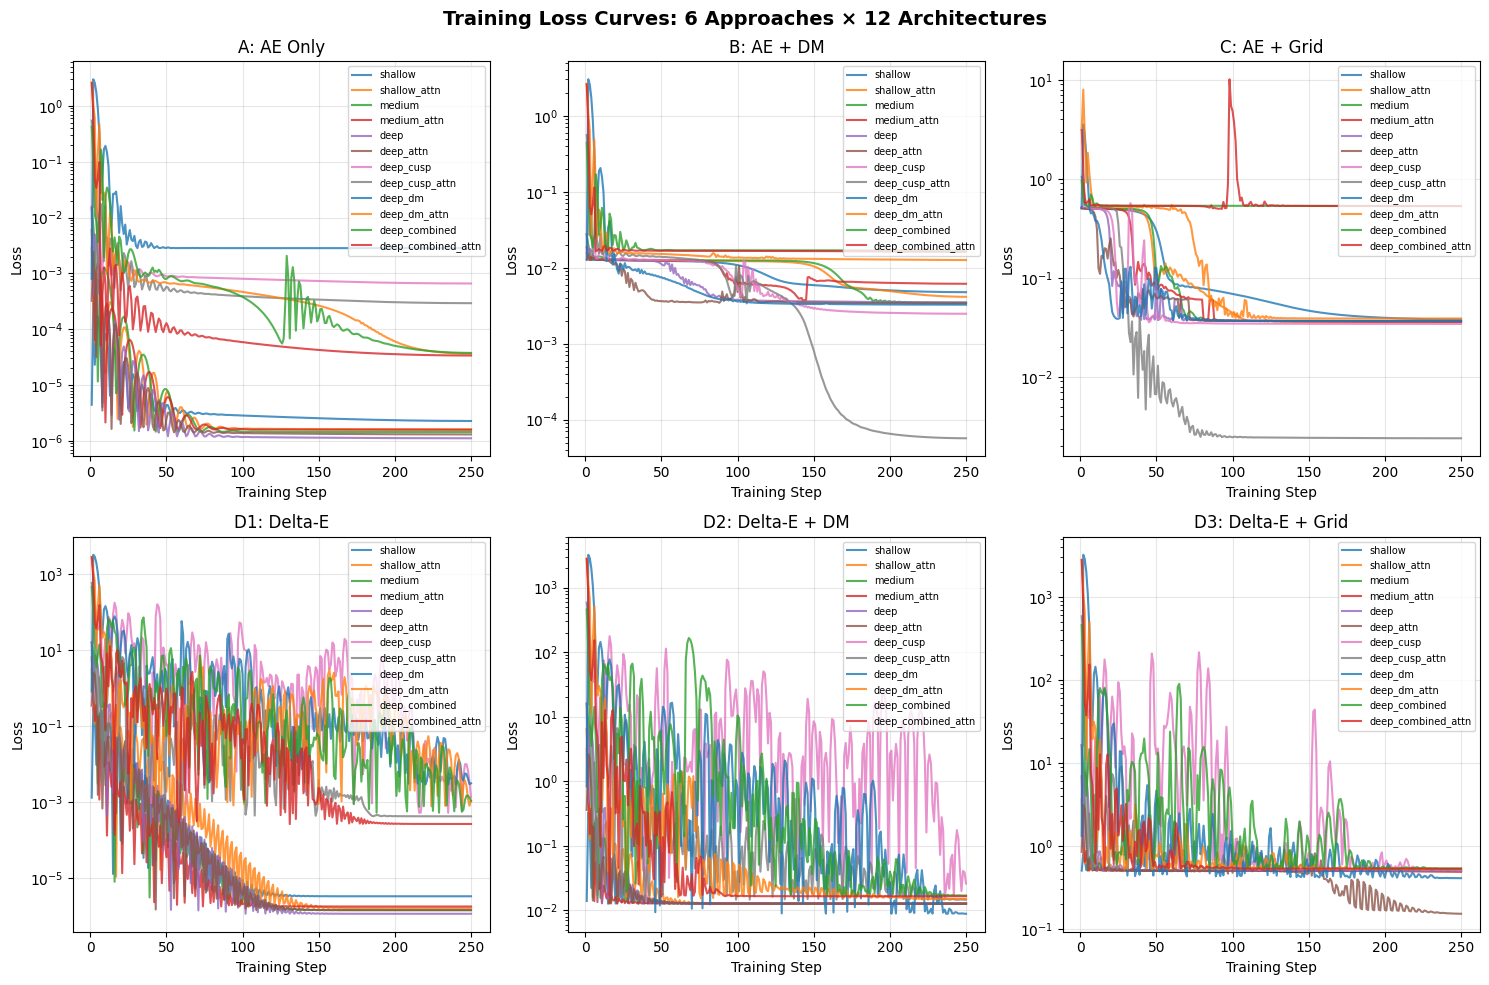

Training loss plots saved to: training_losses_all.png


In [31]:
# =============================================================================
# Plot Training Losses for All 6x6 Trainings
# =============================================================================
# Load losses from checkpoint directories and create 2x3 grid plot

import numpy as np

# Approach names and display labels
approach_names = {
    'A_ae_only': 'A: AE Only',
    'B_ae_dm': 'B: AE + DM',
    'C_ae_grid': 'C: AE + Grid',
    'D1_delta_e': 'D1: Delta-E',
    'D2_delta_dm': 'D2: Delta-E + DM',
    'D3_delta_grid': 'D3: Delta-E + Grid',
}

# Architecture colors (dynamically from ARCHITECTURES)
arch_colors = {}
color_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i, arch in enumerate(ARCHITECTURES.keys()):
    arch_colors[arch] = color_cycle[i % len(color_cycle)]

# Load losses from checkpoint directories
all_losses = {}
for approach_key in approach_names.keys():
    all_losses[approach_key] = {}
    if approach_key in CHECKPOINT_DIRS:
        approach_dir = CHECKPOINT_DIRS[approach_key]
        for arch_name in ARCHITECTURES.keys():
            losses_path = os.path.join(approach_dir, arch_name, 'losses.npy')
            if os.path.exists(losses_path):
                try:
                    losses = np.load(losses_path)
                    all_losses[approach_key][arch_name] = losses
                    print(f"  Loaded {approach_key}/{arch_name}: {len(losses)} steps, final={losses[-1]:.6f}")
                except Exception as e:
                    print(f"  Failed to load {approach_key}/{arch_name}: {e}")

print(f"\nLoaded losses for {sum(len(v) for v in all_losses.values())} model(s)")

# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (approach_key, approach_label) in enumerate(approach_names.items()):
    ax = axes[idx]
    
    has_data = False
    if approach_key in all_losses:
        for arch_name in ARCHITECTURES.keys():
            if arch_name in all_losses[approach_key]:
                losses = all_losses[approach_key][arch_name]
                # Filter out NaN values for plotting
                valid_mask = ~np.isnan(losses)
                if np.any(valid_mask):
                    valid_losses = losses[valid_mask]
                    valid_steps = np.arange(1, len(losses)+1)[valid_mask]
                    color = arch_colors.get(arch_name, 'gray')
                    ax.plot(valid_steps, valid_losses, label=arch_name, 
                           color=color, linewidth=1.5, alpha=0.8)
                    has_data = True
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title(approach_label)
    if has_data:
        ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    if has_data:
        ax.legend(fontsize=7, loc='upper right')
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, color='gray')

plt.suptitle(f'Training Loss Curves: 6 Approaches × {len(ARCHITECTURES)} Architectures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_losses_all.png', dpi=150, bbox_inches='tight')
plt.show()

print('Training loss plots saved to: training_losses_all.png')

## 6. Evaluation

Evaluate all 72 trained models on:

1. **Atomization Energy Error** vs literature (kcal/mol)
   - Direct comparison: $|AE_{pred} - AE_{lit}| \times 627.509$
   
2. **Density Matrix Statistics** (for approaches B/D2):
   - Frobenius norm: $\|D_{pred} - D_{CCSD}\|_F$
   - Comparison: PBE baseline vs NN-predicted
   - Spin-resolved for UKS molecules (H, O): α and β compared separately

3. **Grid Density Statistics** (for approaches C/D3):
   - Integrated absolute error: $\int w(\mathbf{r})|\rho_{pred} - \rho_{CCSD}| d\mathbf{r}$
   - Pointwise comparison on grid

### Evaluation Notes

- **A/D1 approaches**: Only energy predictions evaluated (no density matching)
- **B/C/D2/D3 approaches**: Both energy AND density predictions evaluated
- **UKS molecules**: α and β DMs compared separately, preserving spin structure
- **Extended architectures**: Use appropriate input features (cusp, DM, or both)

In [32]:
# =============================================================================
# Comprehensive Evaluation: Publication-Quality Results Tables
# =============================================================================
# Compares all methods against:
# - ATOMIZATION ENERGY: Literature reference (experimental/benchmark)
# - DENSITY MATRIX: CCSD reference
# - GRID DENSITY: CCSD reference

import numpy as np
from xcquinox.xc import RXCModel_GGA, RXCModel_GGA_Extended

def load_model_from_checkpoint(approach, arch):
    """Load a trained model from checkpoint directory."""
    if approach not in CHECKPOINT_DIRS:
        return None
    arch_dir = os.path.join(CHECKPOINT_DIRS[approach], arch)
    model_path = os.path.join(arch_dir, 'xcmodel.eqx')
    if not os.path.exists(model_path):
        return None
    
    arch_config = ARCHITECTURES[arch]
    depth, nodes = arch_config['depth'], arch_config['nodes']
    use_attn = arch_config.get('use_self_attention', False)
    use_cusp = arch_config.get('use_cusp', False)
    use_dm = arch_config.get('use_dm_features', False)
    
    if use_cusp or use_dm:
        xnet = xce.net.GGA_FxNet_extended_transform(depth=depth, nodes=nodes, seed=42, 
            lower_rho_cutoff=1e-6, use_self_attention=use_attn, use_cusp=use_cusp,
            use_dm_features=use_dm, use_laplacian=False, n_dm_features=3)
        cnet = xce.net.GGA_FcNet_extended_transform(depth=depth, nodes=nodes, seed=43,
            lower_rho_cutoff=1e-6, use_self_attention=use_attn, use_cusp=use_cusp,
            use_dm_features=use_dm, use_laplacian=False, n_dm_features=3)
        model = RXCModel_GGA_Extended(xnet=xnet, cnet=cnet, use_cusp=use_cusp,
            use_dm_features=use_dm, n_dm_features=3)
    else:
        xnet = xce.net.GGA_FxNet_sigma_transform(depth=depth, nodes=nodes, seed=42,
            lower_rho_cutoff=1e-6, use_self_attention=use_attn)
        cnet = xce.net.GGA_FcNet_sigma_transform(depth=depth, nodes=nodes, seed=43,
            lower_rho_cutoff=1e-6, use_self_attention=use_attn)
        model = RXCModel_GGA(xnet=xnet, cnet=cnet)
    
    return eqx.tree_deserialise_leaves(model_path, model)

# -----------------------------------------------------------------------------
# Reference values and baseline metrics
# -----------------------------------------------------------------------------
AE_lit = refs['lit']['H2O_AE']  # Literature atomization energy (THE reference for AE)

# CCSD atomization energy error vs literature
AE_ccsd = refs['ccsd']['AE']
AE_ccsd_error = (AE_ccsd - AE_lit) * 627.509

# PBE atomization energy error vs literature (from refs dict)
AE_pbe = refs['pbe']['AE']
AE_pbe_error = (AE_pbe - AE_lit) * 627.509

# PBE DM RMSE vs CCSD (CCSD is reference for density)
pbe_dm_rmse = {}
for name in ['H', 'O', 'H2O']:
    dm_pbe = np.array(fixed_density_data[name]['dm'])
    dm_ccsd = np.array(refs['ccsd']['dms'][name])
    if dm_ccsd.ndim == 3 and dm_pbe.ndim == 3:
        rmse = (np.sqrt(np.mean((dm_pbe[0]-dm_ccsd[0])**2)) + 
                np.sqrt(np.mean((dm_pbe[1]-dm_ccsd[1])**2))) / 2
    elif dm_ccsd.ndim == 3:
        rmse = np.sqrt(np.mean((dm_pbe - (dm_ccsd[0]+dm_ccsd[1]))**2))
    else:
        rmse = np.sqrt(np.mean((dm_pbe - dm_ccsd)**2))
    pbe_dm_rmse[name] = rmse
pbe_dm_rmse_avg = np.mean(list(pbe_dm_rmse.values()))

# PBE grid density RMSE vs CCSD
pbe_grid_rmse = {}
pbe_grid_int_diff = {}
for name in ['H', 'O', 'H2O']:
    rho_pbe = np.array(fixed_density_data[name]['rho'])
    rho_ccsd = np.array(ccsd_density_data[name]['rho'])
    weights = np.array(fixed_density_data[name]['weights'])
    diff = rho_pbe - rho_ccsd
    pbe_grid_rmse[name] = np.sqrt(np.sum(weights * diff**2) / np.sum(weights))
    pbe_grid_int_diff[name] = np.sum(np.abs(diff) * weights)
pbe_grid_rmse_avg = np.mean(list(pbe_grid_rmse.values()))
pbe_grid_int_diff_total = sum(pbe_grid_int_diff.values())

# -----------------------------------------------------------------------------
# Load and evaluate all models
# -----------------------------------------------------------------------------
approach_names = ['A_ae_only', 'B_ae_dm', 'C_ae_grid', 'D1_delta_e', 'D2_delta_dm', 'D3_delta_grid']
eval_results = {}
loaded_count = 0

for approach in approach_names:
    eval_results[approach] = {}
    for arch in ARCHITECTURES.keys():
        model = load_model_from_checkpoint(approach, arch)
        if model is None:
            continue
        loaded_count += 1
        arch_config = ARCHITECTURES[arch]
        
        # Energy evaluation (fixed-density) - compare to LITERATURE
        E_H = float(compute_total_energy_nn(model, 'H', arch_config))
        E_O = float(compute_total_energy_nn(model, 'O', arch_config))
        E_H2O = float(compute_total_energy_nn(model, 'H2O', arch_config))
        AE_pred = E_H2O - 2*E_H - E_O
        ae_err = (AE_pred - AE_lit) * 627.509  # Error vs LITERATURE
        
        result = {'AE_error_kcal': ae_err}
        
        # DM evaluation for B/D2 - compare to CCSD
        if approach in ['B_ae_dm', 'D2_delta_dm']:
            dm_rmse_list = []
            for name in training_mols.keys():
                try:
                    dm_pred, _ = oneshot_dm_prediction(model, name, arch_config)
                    dm_ccsd = refs['ccsd']['dms'][name]
                    dm_pred, dm_ccsd = np.array(dm_pred), np.array(dm_ccsd)
                    if dm_ccsd.ndim == 3 and dm_pred.ndim == 3:
                        rmse = (np.sqrt(np.mean((dm_pred[0]-dm_ccsd[0])**2)) +
                                np.sqrt(np.mean((dm_pred[1]-dm_ccsd[1])**2))) / 2
                    elif dm_ccsd.ndim == 3:
                        rmse = np.sqrt(np.mean((dm_pred - (dm_ccsd[0]+dm_ccsd[1]))**2))
                    else:
                        rmse = np.sqrt(np.mean((dm_pred - dm_ccsd)**2))
                    dm_rmse_list.append(rmse)
                except:
                    pass
            result['dm_rmse_avg'] = np.mean(dm_rmse_list) if dm_rmse_list else float('nan')
        
        # Grid evaluation for C/D3 - compare to CCSD
        if approach in ['C_ae_grid', 'D3_delta_grid']:
            grid_rmse_list, int_diff_list = [], []
            for name in training_mols.keys():
                try:
                    rho_pred, _, _ = oneshot_grid_density(model, name, arch_config)
                    rho_ccsd = np.array(ccsd_density_data[name]['rho'])
                    weights = np.array(fixed_density_data[name]['weights'])
                    diff = np.array(rho_pred) - rho_ccsd
                    grid_rmse_list.append(np.sqrt(np.sum(weights * diff**2) / np.sum(weights)))
                    int_diff_list.append(np.sum(np.abs(diff) * weights))
                except:
                    pass
            result['grid_rmse_avg'] = np.mean(grid_rmse_list) if grid_rmse_list else float('nan')
            result['grid_int_diff'] = sum(int_diff_list) if int_diff_list else float('nan')
        
        eval_results[approach][arch] = result

print(f"Evaluated {loaded_count} models\n")

# =============================================================================
# BASELINES (stated once, not repeated in tables)
# =============================================================================
print("=" * 80)
print("BASELINE METHODS (Reference Comparisons)")
print("=" * 80)
print(f"  Literature H₂O AE:  {AE_lit:.6f} Ha = {AE_lit*627.509:.2f} kcal/mol")
print()
print("  Atomization Energy Error vs Literature:")
print(f"    CCSD:   {AE_ccsd_error:+6.2f} kcal/mol")
print(f"    PBE:    {AE_pbe_error:+6.2f} kcal/mol")
print()
print("  Density Matrix RMSE vs CCSD:")
print(f"    PBE:    {pbe_dm_rmse_avg:.2e}")
print()
print("  Grid Density RMSE vs CCSD:")
print(f"    PBE:    {pbe_grid_rmse_avg:.2e}")
print()
print("  Integrated |Δρ| vs CCSD:")
print(f"    PBE:    {pbe_grid_int_diff_total:.4f} electrons")
print("=" * 80)

# =============================================================================
# Helper functions
# =============================================================================
arch_list = list(ARCHITECTURES.keys())

def fmt_ae(val):
    if val is None or np.isnan(val): return '     —    '
    return f'{val:>10.2f}'

def fmt_rmse(val):
    if val is None or np.isnan(val): return '     —    '
    return f'{val:>10.2e}'

def fmt_int(val):
    if val is None or np.isnan(val): return '     —    '
    return f'{val:>10.4f}'

# Split architectures into groups for readability (6 per table)
arch_groups = [arch_list[i:i+6] for i in range(0, len(arch_list), 6)]

# =============================================================================
# TABLE 1: Atomization Energy Error vs LITERATURE
# =============================================================================
print("\n")
print("=" * 80)
print("TABLE 1: H₂O Atomization Energy Error vs Literature (kcal/mol)")
print("         Target: ±1.0 kcal/mol (chemical accuracy)")
print("=" * 80)

for group_idx, arch_group in enumerate(arch_groups):
    if group_idx > 0:
        print()  # Blank line between groups
    
    # Header
    hdr = f'{"Method":<14}' + '  '.join(f'{a:>12}' for a in arch_group)
    print(hdr)
    print("-" * len(hdr))
    
    # NN methods only (baselines stated above)
    for approach in approach_names:
        row = f'{approach:<14}'
        has_data = False
        for arch in arch_group:
            if arch in eval_results[approach]:
                row += '  ' + fmt_ae(eval_results[approach][arch]['AE_error_kcal'])
                has_data = True
            else:
                row += '       —    '
        if has_data:
            print(row)

print("=" * 80)

# =============================================================================
# TABLE 2: Density Matrix RMSE vs CCSD
# =============================================================================
print("\n")
print("=" * 80)
print("TABLE 2: Density Matrix RMSE vs CCSD (a.u.)")
print("         Lower is better. CCSD is reference (target).")
print("=" * 80)

dm_approaches = ['B_ae_dm', 'D2_delta_dm']

for group_idx, arch_group in enumerate(arch_groups):
    if group_idx > 0:
        print()
    
    hdr = f'{"Method":<14}' + '  '.join(f'{a:>12}' for a in arch_group)
    print(hdr)
    print("-" * len(hdr))
    
    for approach in dm_approaches:
        row = f'{approach:<14}'
        has_data = False
        for arch in arch_group:
            if arch in eval_results[approach] and 'dm_rmse_avg' in eval_results[approach][arch]:
                row += '  ' + fmt_rmse(eval_results[approach][arch]['dm_rmse_avg'])
                has_data = True
            else:
                row += '       —    '
        if has_data:
            print(row)

print("=" * 80)

# =============================================================================
# TABLE 3: Grid Density RMSE vs CCSD
# =============================================================================
print("\n")
print("=" * 80)
print("TABLE 3: Grid Density Weighted RMSE vs CCSD (a.u.)")
print("         Lower is better. CCSD is reference (target).")
print("=" * 80)

grid_approaches = ['C_ae_grid', 'D3_delta_grid']

for group_idx, arch_group in enumerate(arch_groups):
    if group_idx > 0:
        print()
    
    hdr = f'{"Method":<14}' + '  '.join(f'{a:>12}' for a in arch_group)
    print(hdr)
    print("-" * len(hdr))
    
    for approach in grid_approaches:
        row = f'{approach:<14}'
        has_data = False
        for arch in arch_group:
            if arch in eval_results[approach] and 'grid_rmse_avg' in eval_results[approach][arch]:
                row += '  ' + fmt_rmse(eval_results[approach][arch]['grid_rmse_avg'])
                has_data = True
            else:
                row += '       —    '
        if has_data:
            print(row)

print("=" * 80)

# =============================================================================
# TABLE 4: Integrated Density Difference
# =============================================================================
print("\n")
print("=" * 80)
print("TABLE 4: Integrated Density Difference |Δρ| vs CCSD (electrons)")
print("         Lower is better. CCSD is reference (target).")
print("=" * 80)

for group_idx, arch_group in enumerate(arch_groups):
    if group_idx > 0:
        print()
    
    hdr = f'{"Method":<14}' + '  '.join(f'{a:>12}' for a in arch_group)
    print(hdr)
    print("-" * len(hdr))
    
    for approach in grid_approaches:
        row = f'{approach:<14}'
        has_data = False
        for arch in arch_group:
            if arch in eval_results[approach] and 'grid_int_diff' in eval_results[approach][arch]:
                row += '  ' + fmt_int(eval_results[approach][arch]['grid_int_diff'])
                has_data = True
            else:
                row += '       —    '
        if has_data:
            print(row)

print("=" * 80)

# =============================================================================
# SUMMARY: Best Results
# =============================================================================
print("\n")
print("=" * 80)
print("SUMMARY: Best NN Results by Training Approach")
print("=" * 80)
print(f'{"Approach":<14}  {"Best AE Error":>14}  {"Architecture":<16}  {"vs CCSD":>10}')
print("-" * 60)

for approach in approach_names:
    if eval_results[approach]:
        ae_errors = {a: r['AE_error_kcal'] for a, r in eval_results[approach].items() 
                     if 'AE_error_kcal' in r and not np.isnan(r['AE_error_kcal'])}
        if ae_errors:
            # Find best by absolute error
            best_arch = min(ae_errors, key=lambda x: abs(ae_errors[x]))
            best_err = ae_errors[best_arch]
            improvement = abs(AE_ccsd_error) - abs(best_err)
            imp_str = f'{improvement:+.2f}' if improvement > 0 else f'{improvement:.2f}'
            print(f'{approach:<14}  {best_err:+14.2f}  {best_arch:<16}  {imp_str:>10}')

print("-" * 60)
print(f'{"CCSD":<14}  {AE_ccsd_error:+14.2f}  {"(baseline)":<16}  {"0.00":>10}')
print(f'{"PBE":<14}  {AE_pbe_error:+14.2f}  {"(baseline)":<16}')
print("=" * 80)

# Key finding
best_overall = None
best_overall_err = float('inf')
for approach in approach_names:
    for arch, r in eval_results[approach].items():
        if 'AE_error_kcal' in r and abs(r['AE_error_kcal']) < best_overall_err:
            best_overall_err = abs(r['AE_error_kcal'])
            best_overall = (approach, arch, r['AE_error_kcal'])

if best_overall:
    print(f'\nBest overall: {best_overall[0]}/{best_overall[1]}')
    print(f'  AE error: {best_overall[2]:+.2f} kcal/mol')
    if abs(best_overall[2]) < abs(AE_ccsd_error):
        print(f'  ✓ Better than CCSD ({AE_ccsd_error:+.2f} kcal/mol) by {abs(AE_ccsd_error)-abs(best_overall[2]):.2f} kcal/mol')
    if abs(best_overall[2]) < 1.0:
        print(f'  ✓ Achieves chemical accuracy (<1 kcal/mol)')


        [diag] fock: min=-0.460134 max=1.714503
        [diag] L: min=0.000000 max=1.000000 nans=0
        [diag] L_inv: min=-0.939715 max=1.372248 nans=0
        [eigh] mo_energy_a nans=0
        [eigh] mo_coeff_a nans=0
        [diag] fock: min=-258.510024 max=28.349846
        [diag] L: min=-0.344017 max=1.000000 nans=0
        [diag] L_inv: min=-1.383081 max=1.659877 nans=0
        [eigh] mo_energy_a nans=0
        [eigh] mo_coeff_a nans=0
        [diag] fock: min=-247.689158 max=25.644250
        [diag] L: min=-0.439766 max=1.000000 nans=0
        [diag] L_inv: min=-1.700229 max=2.030814 nans=0
        [eigh] mo_energy nans=0
        [eigh] mo_coeff nans=0
        [diag] fock: min=-0.459770 max=1.715793
        [diag] L: min=0.000000 max=1.000000 nans=0
        [diag] L_inv: min=-0.939715 max=1.372248 nans=0
        [eigh] mo_energy_a nans=0
        [eigh] mo_coeff_a nans=0
        [diag] fock: min=-270.625925 max=29.254272
        [diag] L: min=-0.344017 max=1.000000 nans=0
     

In [33]:
# =============================================================================
# Density Matrix and Grid Density Comparisons: PBE vs CCSD
# =============================================================================
# These comparisons show the baseline "target corrections" that training aims to learn.
# For UKS molecules (H, O), alpha and beta are compared separately.

import numpy as np

print('='*100)
print('DENSITY MATRIX COMPARISON: PBE vs CCSD')
print('='*100)
print()

dm_comparison_results = {}

for mol_name in ['H', 'O', 'H2O']:
    dm_pbe = np.array(fixed_density_data[mol_name]['dm'])
    dm_ccsd = np.array(refs['ccsd']['dms'][mol_name])
    overlap = np.array(fixed_density_data[mol_name]['overlap'])
    
    print(f'{mol_name}:')
    print(f'  PBE DM shape: {dm_pbe.shape}, CCSD DM shape: {dm_ccsd.shape}')
    
    # Handle spin-separated comparison for UKS
    if dm_ccsd.ndim == 3 and dm_pbe.ndim == 3:
        # UKS case: compare alpha to alpha, beta to beta
        print(f'  [UKS: Comparing α and β separately]')
        
        dm_diff_a = dm_pbe[0] - dm_ccsd[0]
        dm_diff_b = dm_pbe[1] - dm_ccsd[1]
        
        # Alpha statistics
        rmse_a = np.sqrt(np.mean(dm_diff_a**2))
        max_err_a = np.max(np.abs(dm_diff_a))
        frob_a = np.sqrt(np.sum(dm_diff_a**2))
        
        # Beta statistics
        rmse_b = np.sqrt(np.mean(dm_diff_b**2))
        max_err_b = np.max(np.abs(dm_diff_b))
        frob_b = np.sqrt(np.sum(dm_diff_b**2))
        
        # Combined statistics
        rmse = (rmse_a + rmse_b) / 2
        max_err = max(max_err_a, max_err_b)
        frobenius_diff = np.sqrt(frob_a**2 + frob_b**2)
        
        # Frobenius norms
        frobenius_pbe = np.sqrt(np.sum(dm_pbe[0]**2) + np.sum(dm_pbe[1]**2))
        frobenius_ccsd = np.sqrt(np.sum(dm_ccsd[0]**2) + np.sum(dm_ccsd[1]**2))
        relative_err = frobenius_diff / frobenius_ccsd * 100
        
        # Trace (electron count) - sum over both spins
        trace_pbe = np.trace(dm_pbe[0] @ overlap) + np.trace(dm_pbe[1] @ overlap)
        trace_ccsd = np.trace(dm_ccsd[0] @ overlap) + np.trace(dm_ccsd[1] @ overlap)
        
        # Natural orbital occupations - analyze total DM
        dm_pbe_total = dm_pbe[0] + dm_pbe[1]
        dm_ccsd_total = dm_ccsd[0] + dm_ccsd[1]
        eig_pbe = np.linalg.eigvalsh(dm_pbe_total @ overlap)[::-1]
        eig_ccsd = np.linalg.eigvalsh(dm_ccsd_total @ overlap)[::-1]
        
        dm_comparison_results[mol_name] = {
            'rmse': rmse, 'rmse_a': rmse_a, 'rmse_b': rmse_b,
            'max_err': max_err, 'max_err_a': max_err_a, 'max_err_b': max_err_b,
            'relative_err': relative_err,
            'trace_pbe': trace_pbe, 'trace_ccsd': trace_ccsd,
            'frobenius_diff': frobenius_diff,
            'eig_pbe': eig_pbe, 'eig_ccsd': eig_ccsd,
            'is_uks': True,
        }
        
        print(f'  Alpha (α) Statistics:')
        print(f'    RMSE (element-wise):     {rmse_a:.6e}')
        print(f'    Max absolute error:      {max_err_a:.6e}')
        print(f'    Frobenius norm (diff):   {frob_a:.6f}')
        print(f'  Beta (β) Statistics:')
        print(f'    RMSE (element-wise):     {rmse_b:.6e}')
        print(f'    Max absolute error:      {max_err_b:.6e}')
        print(f'    Frobenius norm (diff):   {frob_b:.6f}')
        print(f'  Combined Statistics:')
        print(f'    Average RMSE:            {rmse:.6e}')
        print(f'    Max absolute error:      {max_err:.6e}')
        print(f'    Total Frobenius diff:    {frobenius_diff:.6f}')
        print(f'    Relative error:          {relative_err:.2f}%')
        
    else:
        # RKS case or dimension mismatch
        if dm_ccsd.ndim == 3:
            print(f'  [Converting UKS CCSD to total DM for comparison]')
            dm_ccsd_use = dm_ccsd[0] + dm_ccsd[1]
        else:
            dm_ccsd_use = dm_ccsd
            
        if dm_pbe.ndim == 3:
            dm_pbe_use = dm_pbe[0] + dm_pbe[1]
        else:
            dm_pbe_use = dm_pbe
            
        dm_diff = dm_pbe_use - dm_ccsd_use
        
        rmse = np.sqrt(np.mean(dm_diff**2))
        max_err = np.max(np.abs(dm_diff))
        frobenius_pbe = np.sqrt(np.sum(dm_pbe_use**2))
        frobenius_ccsd = np.sqrt(np.sum(dm_ccsd_use**2))
        frobenius_diff = np.sqrt(np.sum(dm_diff**2))
        relative_err = frobenius_diff / frobenius_ccsd * 100
        
        trace_pbe = np.trace(dm_pbe_use @ overlap)
        trace_ccsd = np.trace(dm_ccsd_use @ overlap)
        
        eig_pbe = np.linalg.eigvalsh(dm_pbe_use @ overlap)[::-1]
        eig_ccsd = np.linalg.eigvalsh(dm_ccsd_use @ overlap)[::-1]
        
        dm_comparison_results[mol_name] = {
            'rmse': rmse,
            'max_err': max_err,
            'relative_err': relative_err,
            'trace_pbe': trace_pbe,
            'trace_ccsd': trace_ccsd,
            'frobenius_diff': frobenius_diff,
            'eig_pbe': eig_pbe,
            'eig_ccsd': eig_ccsd,
            'is_uks': False,
        }
        
        print(f'  [RKS: Total DM comparison]')
        print(f'  Matrix Statistics:')
        print(f'    RMSE (element-wise):     {rmse:.6e}')
        print(f'    Max absolute error:      {max_err:.6e}')
        print(f'    Frobenius norm (PBE):    {frobenius_pbe:.6f}')
        print(f'    Frobenius norm (CCSD):   {frobenius_ccsd:.6f}')
        print(f'    Frobenius norm (diff):   {frobenius_diff:.6f}')
        print(f'    Relative error:          {relative_err:.2f}%')
    
    print(f'  Electron Count:')
    print(f'    Tr(D·S) PBE:             {dm_comparison_results[mol_name]["trace_pbe"]:.6f}')
    print(f'    Tr(D·S) CCSD:            {dm_comparison_results[mol_name]["trace_ccsd"]:.6f}')
    print(f'    Difference:              {dm_comparison_results[mol_name]["trace_pbe"] - dm_comparison_results[mol_name]["trace_ccsd"]:.6e}')
    print(f'  Natural Orbital Occupations (top 5):')
    print(f'    PBE:  {dm_comparison_results[mol_name]["eig_pbe"][:5]}')
    print(f'    CCSD: {dm_comparison_results[mol_name]["eig_ccsd"][:5]}')
    print()

print('='*100)
print('GRID DENSITY COMPARISON: PBE vs CCSD')
print('='*100)
print()

rho_comparison_results = {}

for mol_name in ['H', 'O', 'H2O']:
    rho_pbe = np.array(fixed_density_data[mol_name]['rho'])
    rho_ccsd = np.array(ccsd_density_data[mol_name]['rho'])
    weights = np.array(fixed_density_data[mol_name]['weights'])
    
    rho_diff = rho_pbe - rho_ccsd
    
    # Integrated statistics
    int_pbe = np.sum(rho_pbe * weights)
    int_ccsd = np.sum(rho_ccsd * weights)
    int_abs_diff = np.sum(np.abs(rho_diff) * weights)
    int_sq_diff = np.sum(rho_diff**2 * weights)
    
    # Weighted RMSE
    weighted_rmse = np.sqrt(int_sq_diff / np.sum(weights))
    
    # Pointwise statistics
    max_err = np.max(np.abs(rho_diff))
    max_rho = np.max(rho_pbe)
    relative_max_err = max_err / max_rho * 100
    
    # Where are the largest errors?
    err_threshold = 0.5 * max_err
    large_err_mask = np.abs(rho_diff) > err_threshold
    frac_large_err = np.sum(large_err_mask) / len(rho_diff) * 100
    
    rho_comparison_results[mol_name] = {
        'weighted_rmse': weighted_rmse,
        'max_err': max_err,
        'relative_max_err': relative_max_err,
        'int_pbe': int_pbe,
        'int_ccsd': int_ccsd,
        'int_abs_diff': int_abs_diff,
        'frac_large_err': frac_large_err,
    }
    
    print(f'{mol_name}:')
    print(f'  Grid Statistics:')
    print(f'    Weighted RMSE:           {weighted_rmse:.6e}')
    print(f'    Max absolute error:      {max_err:.6e}')
    print(f'    Relative max error:      {relative_max_err:.2f}%')
    print(f'  Integrated Quantities:')
    print(f'    ∫ρ·dV (PBE):             {int_pbe:.6f} electrons')
    print(f'    ∫ρ·dV (CCSD):            {int_ccsd:.6f} electrons')
    print(f'    ∫|Δρ|·dV:                {int_abs_diff:.6f} electrons')
    print(f'  Error Distribution:')
    print(f'    Points with |err| > 50% max: {frac_large_err:.2f}%')
    print()

print('='*100)
print('SUMMARY: PBE vs CCSD Baseline Errors')
print('='*100)
print()
print('These are the errors that the neural network needs to correct.')
print()
print(f'{"Molecule":<10} {"DM RMSE":>12} {"DM Rel%":>10} {"Grid RMSE":>12} {"∫|Δρ| (e⁻)":>12}')
print('-'*60)
for mol_name in ['H', 'O', 'H2O']:
    dm_rmse = dm_comparison_results[mol_name]['rmse']
    dm_rel = dm_comparison_results[mol_name]['relative_err']
    grid_rmse = rho_comparison_results[mol_name]['weighted_rmse']
    int_diff = rho_comparison_results[mol_name]['int_abs_diff']
    print(f'{mol_name:<10} {dm_rmse:>12.2e} {dm_rel:>10.2f} {grid_rmse:>12.2e} {int_diff:>12.4f}')
print('='*100)

DENSITY MATRIX COMPARISON: PBE vs CCSD

H:
  PBE DM shape: (2, 5, 5), CCSD DM shape: (2, 5, 5)
  [UKS: Comparing α and β separately]
  Alpha (α) Statistics:
    RMSE (element-wise):     1.881152e-03
    Max absolute error:      7.011712e-03
    Frobenius norm (diff):   0.009406
  Beta (β) Statistics:
    RMSE (element-wise):     0.000000e+00
    Max absolute error:      0.000000e+00
    Frobenius norm (diff):   0.000000
  Combined Statistics:
    Average RMSE:            9.405760e-04
    Max absolute error:      7.011712e-03
    Total Frobenius diff:    0.009406
    Relative error:          1.58%
  Electron Count:
    Tr(D·S) PBE:             1.000000
    Tr(D·S) CCSD:            1.000000
    Difference:              6.661338e-16
  Natural Orbital Occupations (top 5):
    PBE:  [ 9.73081705e-01  2.69182950e-02 -2.67217476e-51 -6.68250173e-51
 -8.44538064e-35]
    CCSD: [0.96888134 0.03111866 0.         0.         0.        ]

O:
  PBE DM shape: (2, 14, 14), CCSD DM shape: (2, 14, 14)
 

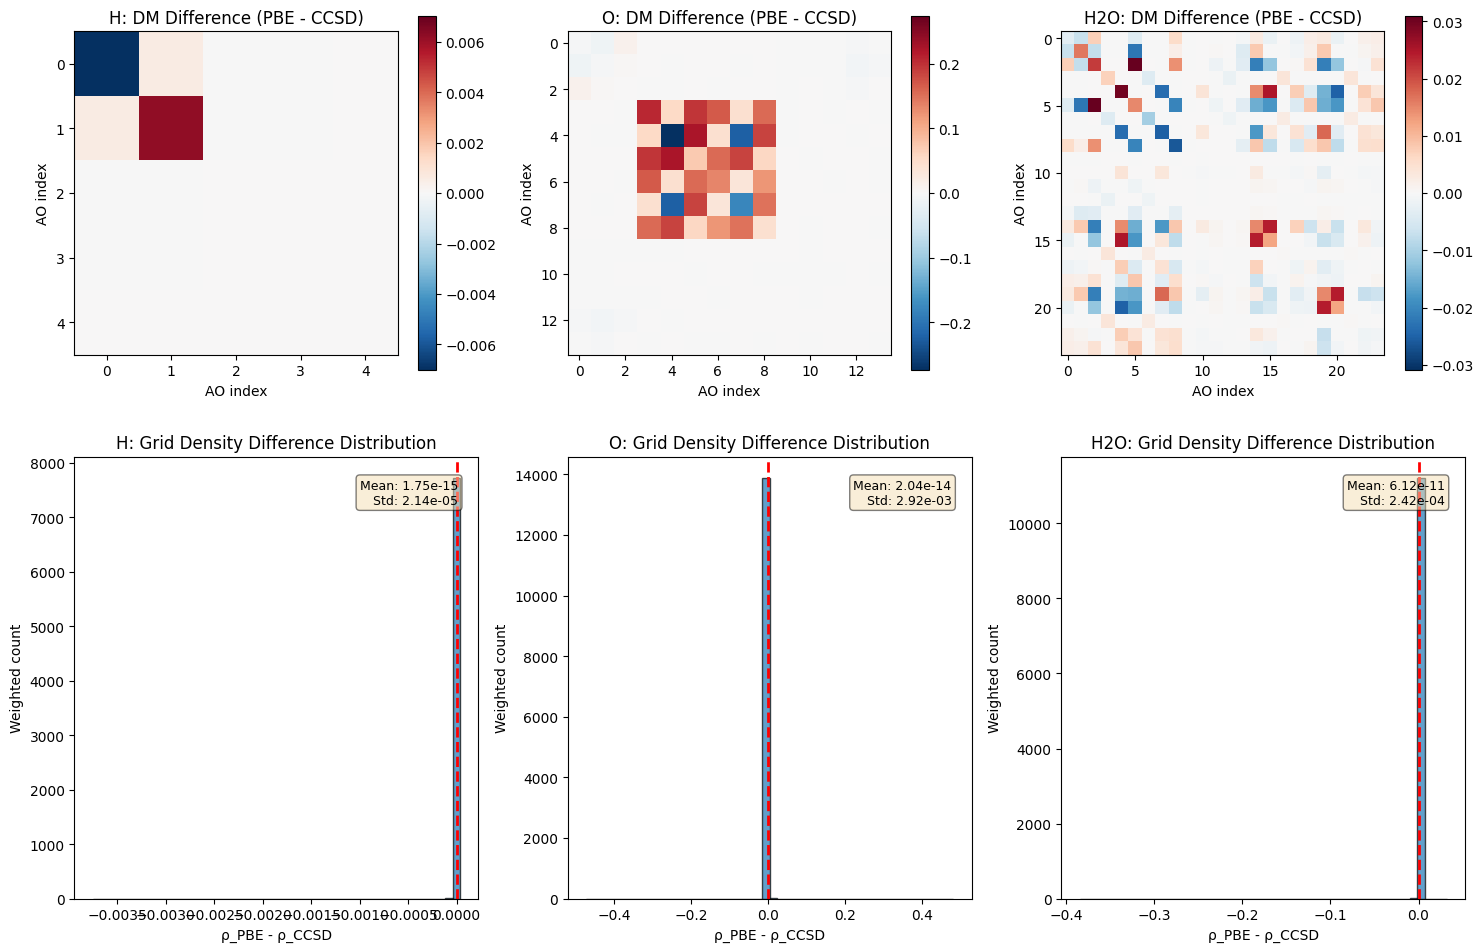

Saved: checkpoints_v3b/dm_density_comparison.png


In [34]:
# =============================================================================
# Visualize DM and Density Differences
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Density matrix heatmaps (difference)
for idx, mol_name in enumerate(['H', 'O', 'H2O']):
    ax = axes[0, idx]
    dm_pbe = np.array(fixed_density_data[mol_name]['dm'])
    dm_ccsd = np.array(refs['ccsd']['dms'][mol_name])
    
    # Handle UKS case: sum alpha + beta for both PBE and CCSD
    if dm_ccsd.ndim == 3:
        dm_ccsd = dm_ccsd[0] + dm_ccsd[1]
    if dm_pbe.ndim == 3:
        dm_pbe = dm_pbe[0] + dm_pbe[1]
    
    dm_diff = dm_pbe - dm_ccsd
    
    vmax = np.max(np.abs(dm_diff))
    im = ax.imshow(dm_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{mol_name}: DM Difference (PBE - CCSD)')
    ax.set_xlabel('AO index')
    ax.set_ylabel('AO index')
    plt.colorbar(im, ax=ax, shrink=0.8)

# Row 2: Density difference histograms
for idx, mol_name in enumerate(['H', 'O', 'H2O']):
    ax = axes[1, idx]
    rho_pbe = np.array(fixed_density_data[mol_name]['rho'])
    rho_ccsd = np.array(ccsd_density_data[mol_name]['rho'])
    weights = np.array(fixed_density_data[mol_name]['weights'])
    
    rho_diff = rho_pbe - rho_ccsd
    
    # Weighted histogram
    ax.hist(rho_diff, bins=50, weights=weights, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('ρ_PBE - ρ_CCSD')
    ax.set_ylabel('Weighted count')
    ax.set_title(f'{mol_name}: Grid Density Difference Distribution')
    
    # Add statistics annotation
    mean_diff = np.sum(rho_diff * weights) / np.sum(weights)
    std_diff = np.sqrt(np.sum((rho_diff - mean_diff)**2 * weights) / np.sum(weights))
    ax.annotate(f'Mean: {mean_diff:.2e}\nStd: {std_diff:.2e}', 
                xy=(0.95, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_BASE, 'dm_density_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CHECKPOINT_BASE}/dm_density_comparison.png')

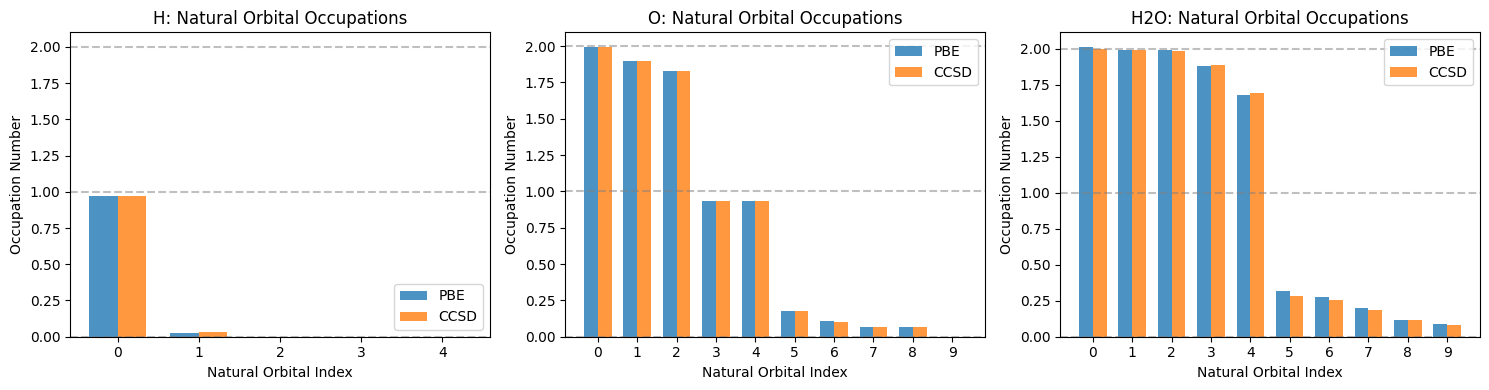

Saved: checkpoints_v3b/natural_orbital_occupations.png

Correlation Indicators (deviations from integer occupations):
  H: Σ|n_i - round(n_i)| = 0.0622
  O: Σ|n_i - round(n_i)| = 0.8293
  H2O: Σ|n_i - round(n_i)| = 2.1767


In [35]:
# =============================================================================
# Natural Orbital Occupation Comparison
# =============================================================================
# Natural orbital occupations reveal correlation effects (deviations from 0/2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, mol_name in enumerate(['H', 'O', 'H2O']):
    ax = axes[idx]
    
    eig_pbe = dm_comparison_results[mol_name]['eig_pbe']
    eig_ccsd = dm_comparison_results[mol_name]['eig_ccsd']
    
    n_orbs = min(len(eig_pbe), 10)  # Show top 10 orbitals
    x = np.arange(n_orbs)
    width = 0.35
    
    ax.bar(x - width/2, eig_pbe[:n_orbs], width, label='PBE', alpha=0.8)
    ax.bar(x + width/2, eig_ccsd[:n_orbs], width, label='CCSD', alpha=0.8)
    
    ax.set_xlabel('Natural Orbital Index')
    ax.set_ylabel('Occupation Number')
    ax.set_title(f'{mol_name}: Natural Orbital Occupations')
    ax.set_xticks(x)
    ax.legend()
    ax.axhline(y=2.0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_BASE, 'natural_orbital_occupations.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CHECKPOINT_BASE}/natural_orbital_occupations.png')

# Print correlation indicators
print('\nCorrelation Indicators (deviations from integer occupations):')
for mol_name in ['H', 'O', 'H2O']:
    eig_ccsd = dm_comparison_results[mol_name]['eig_ccsd']
    # Correlation indicator: sum of |n_i - round(n_i)|
    corr_indicator = np.sum(np.abs(eig_ccsd - np.round(eig_ccsd)))
    print(f'  {mol_name}: Σ|n_i - round(n_i)| = {corr_indicator:.4f}')



## 7. Visualization

Visualizations include:
- Training loss curves for all 72 models (6 approaches × 12 architectures)
- Atomization energy error bar charts by architecture and approach
- DM difference heatmaps: PBE vs CCSD, NN-predicted vs CCSD
- Grid density difference distributions
- Comparison of attention vs non-attention variants
- Extended feature architectures vs standard

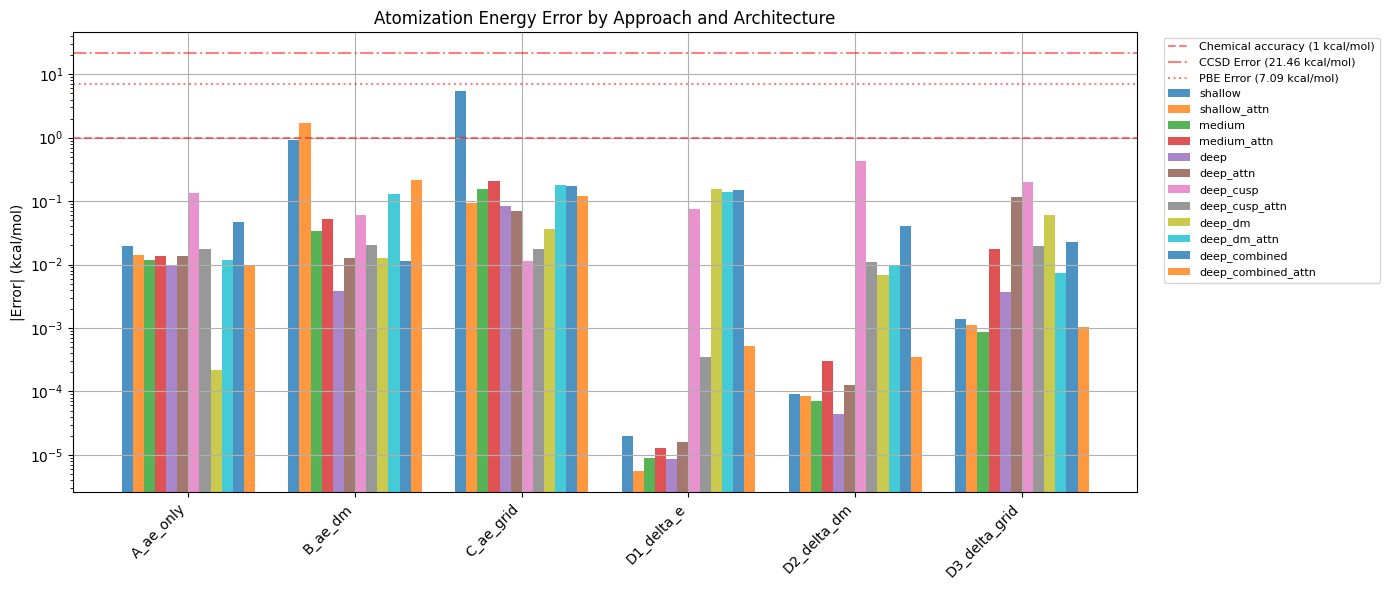

Saved: checkpoints_v3b/error_comparison.png


In [58]:
# Bar chart of AE errors by approach and architecture
ae_err_CCSD = 21.46 #kcal/mol
ae_err_PBE = 7.09  #kcal/mol

if eval_results:
    # Get approaches that have results
    approaches_with_data = [app for app in eval_results.keys() if eval_results[app]]
    
    if approaches_with_data:
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.grid()
        n_approaches = len(approaches_with_data)
        n_archs = len(ARCHITECTURES)
        width = 0.8 / n_archs  # Adjust width based on number of architectures
        x = np.arange(n_approaches)

        for i, arch in enumerate(ARCHITECTURES.keys()):
            errors = []
            for approach in approaches_with_data:
                if arch in eval_results[approach] and 'AE_error_kcal' in eval_results[approach][arch]:
                    errors.append(abs(eval_results[approach][arch]['AE_error_kcal']))
                else:
                    errors.append(0)  # No data
            ax.bar(x + i*width, errors, width, label=arch, alpha=0.8)

        ax.set_ylabel('|Error| (kcal/mol)')
        ax.set_title('Atomization Energy Error by Approach and Architecture')
        ax.set_xticks(x + width*(n_archs-1)/2)
        ax.set_xticklabels(approaches_with_data, rotation=45, ha='right')
        ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Chemical accuracy (1 kcal/mol)')
        ax.axhline(y=ae_err_CCSD, color='r', linestyle='-.', alpha=0.5, label='CCSD Error ({:3.2f} kcal/mol)'.format(ae_err_CCSD))
        ax.axhline(y=ae_err_PBE, color='r', linestyle='dotted', alpha=0.5, label='PBE Error ({:3.2f} kcal/mol)'.format(ae_err_PBE))
        ax.set_yscale('log')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_BASE, 'error_comparison.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {CHECKPOINT_BASE}/error_comparison.png')
    else:
        print('No approaches have evaluation results.')
else:
    print('No eval_results to plot. Run the evaluation cell first.')

## 9. Summary: Architectures, Training Methods, and Implementation Details

---

### 9.1 Overview

This notebook implements a **hybrid training approach** for neural network exchange-correlation (XC) functionals:

- **72 models** total: 12 architectures × 6 training approaches
- **Fixed-density** for energy calculations (fast, stable)
- **Fast one-shot** for density matching (pure JAX, no pyscfad overhead)

---

### 9.2 The Exchange-Correlation Functional

The XC energy is parameterized using enhancement factors over LDA:

$$E_{xc} = \int \rho(\mathbf{r}) \left[ \varepsilon_x^{\text{LDA}}(\rho) \cdot F_x(\rho, \sigma, ...) + \varepsilon_c^{\text{LDA}}(\rho) \cdot F_c(\rho, \sigma, ...) \right] d\mathbf{r}$$

where:
- $\varepsilon_x^{\text{LDA}}(\rho) = -\frac{3}{4}\left(\frac{3}{\pi}\right)^{1/3} \rho^{1/3}$ is the LDA exchange energy density
- $\varepsilon_c^{\text{LDA}}(\rho)$ is the PW92 correlation energy density
- $F_x, F_c$ are neural network enhancement factors
- $\sigma = |\nabla\rho|^2$ is the squared gradient magnitude

---

### 9.3 Input Features

#### 9.3.1 Feature Summary Table

| Architecture | Input Features | Dimension |
|--------------|---------------|-----------|
| Basic | $[\rho, \sigma]$ | 2 |
| Cusp only | $[\rho, \sigma, f_{cusp}, \log Z_{weighted}]$ | 4 |
| DM only | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}]$ | 5 |
| Combined | $[\rho, \sigma, f_{idem}, f_{entropy}, f_{offdiag}, f_{cusp}, \log Z_{weighted}]$ | 7 |

**Important:** Feature order is **dm BEFORE cusp** to match network `__call__` parsing.

#### 9.3.2 Nuclear Proximity Features

These features provide information about nuclear positions but do **not** enforce the Kato cusp condition as a constraint.

**Cusp decay factor:**
$$f_{cusp} = e^{-2 Z_{nearest} r_{min}}$$

where $Z_{nearest}$ is the charge of the nearest nucleus and $r_{min}$ is the distance to it. This is related to the Slater-type orbital decay $\psi \sim e^{-Zr}$ near nuclei.

**Log-weighted nuclear charge:**
$$\log Z_{weighted} = \log\left(\sum_A \frac{Z_A}{r_A}\right)$$

where the sum is over all nuclei $A$ with charges $Z_A$ at distances $r_A$ from the grid point. This Coulomb-like weighting emphasizes nearby nuclei.

#### 9.3.3 Density Matrix Features

**Idempotency error:**
$$f_{idem} = \frac{\text{Tr}(D - D \cdot S \cdot D)}{\text{Tr}(D)}$$

For Hartree-Fock, $D \cdot S \cdot D = D$ (idempotency). Deviation indicates electron correlation.

**Occupation entropy:**
$$f_{entropy} = -\sum_i \frac{n_i}{N} \log\left(\frac{n_i}{N}\right)$$

where $n_i$ are natural orbital occupations and $N = \sum_i n_i$. High entropy indicates strong correlation (fractional occupations away from 0 or 2).

**Off-diagonal norm:**
$$f_{offdiag} = \frac{\|D - \text{diag}(D)\|_F}{\text{Tr}(D)}$$

The Frobenius norm of off-diagonal elements normalized by trace. Measures delocalization/correlation.

---

### 9.4 Network Architectures

#### 9.4.1 Architecture Configuration

```python
ARCHITECTURES = {
    'shallow': {
        'depth': 2, 'nodes': 8, 'use_self_attention': False,
        'use_cusp': False, 'use_dm_features': False, 'net_type': 'basic'
    },
    'deep_cusp': {
        'depth': 4, 'nodes': 32, 'use_self_attention': False,
        'use_cusp': True, 'use_dm_features': False, 'net_type': 'extended'
    },
    'deep_combined_attn': {
        'depth': 4, 'nodes': 32, 'use_self_attention': True,
        'use_cusp': True, 'use_dm_features': True, 'net_type': 'extended'
    },
    # ... 9 more architectures
}
```

**Configuration parameters:**
- `depth`: Number of hidden layers in the MLP
- `nodes`: Number of neurons per hidden layer
- `use_self_attention`: Whether to add self-attention layers between MLP layers
- `use_cusp`: Include nuclear proximity features ($f_{cusp}$, $\log Z_{weighted}$)
- `use_dm_features`: Include density matrix features ($f_{idem}$, $f_{entropy}$, $f_{offdiag}$)
- `net_type`: `'basic'` uses 2-input networks, `'extended'` uses variable-input networks

#### 9.4.2 Network Creation

```python
def create_network_pair(arch_name, seed=42):
    config = ARCHITECTURES[arch_name]
    
    if config['net_type'] == 'extended':
        xnet = xce.net.GGA_FxNet_extended(
            depth=config['depth'],
            nodes=config['nodes'],
            use_self_attention=config['use_self_attention'],
            use_cusp=config['use_cusp'],
            use_dm_features=config['use_dm_features'],
            n_dm_features=3
        )
    else:
        xnet = xce.net.GGA_FxNet_sigma(
            depth=config['depth'],
            nodes=config['nodes'],
            use_self_attention=config['use_self_attention']
        )
    return xnet, cnet
```

**Non-transform networks:** All networks use the reduced density gradient $s$ directly (matching step3 approach):

$$s = \frac{|\nabla\rho|}{2(3\pi^2)^{1/3}\rho^{4/3}}$$

This prevents gradient explosion from extreme $\sigma$ values (~$10^7$) that occur in low-density regions.

---

### 9.5 Training Approaches

#### 9.5.1 Approach A: Fixed-Density Atomization Energy

```python
def make_loss_A_ae_only(arch_config):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        E_H = compute_total_energy_nn(model, 'H', arch_config)
        E_O = compute_total_energy_nn(model, 'O', arch_config)
        E_H2O = compute_total_energy_nn(model, 'H2O', arch_config)
        
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        return ae_loss
    return loss_fn
```

**Mathematical formulation:**

The total energy for each species is computed on the **fixed PBE density**:
$$E_{total}[\rho_{PBE}] = E_{non-xc}[\rho_{PBE}] + E_{xc}^{NN}[\rho_{PBE}]$$

where $E_{non-xc} = T_s + V_{ext} + E_J + E_{nuc}$ is pre-computed from the converged PBE calculation.

The atomization energy is:
$$AE_{pred} = E_{H_2O} - 2E_H - E_O$$

The loss function minimizes the relative squared error:
$$\mathcal{L}_A = \frac{(AE_{pred} - AE_{lit})^2}{AE_{lit}^2 + \epsilon}$$

where $AE_{lit} = -0.3709$ Hartree is the literature atomization energy.

---

#### 9.5.2 Approach B: AE + Density Matrix Matching

```python
def make_loss_B_ae_dm(arch_config, dm_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # Atomization energy (same as A)
        AE_pred = E_H2O - 2*E_H - E_O
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        # DM matching via one-shot prediction
        dm_loss = 0.0
        for name in ['H', 'O', 'H2O']:
            dm_pred, _ = oneshot_dm_prediction(model, name, arch_config)
            dm_ccsd = refs['ccsd']['dms'][name]
            dm_loss += jnp.sum((dm_pred - dm_ccsd)**2)
        
        return ae_loss + dm_weight * dm_loss
    return loss_fn
```

**Mathematical formulation:**

The loss combines atomization energy with density matrix matching:
$$\mathcal{L}_B = \mathcal{L}_{AE} + \lambda_{DM} \sum_{mol} \|D_{pred} - D_{CCSD}\|_F^2$$

where $\|\cdot\|_F$ is the Frobenius norm:
$$\|D_{pred} - D_{CCSD}\|_F^2 = \sum_{ij} (D_{pred,ij} - D_{CCSD,ij})^2$$

For UKS (open-shell) molecules, $\alpha$ and $\beta$ density matrices are compared separately:
$$\mathcal{L}_{DM}^{UKS} = \|D^\alpha_{pred} - D^\alpha_{CCSD}\|_F^2 + \|D^\beta_{pred} - D^\beta_{CCSD}\|_F^2$$

The predicted DM comes from **one-shot diagonalization** (Section 9.6).

---

#### 9.5.3 Approach C: AE + Grid Density Matching

```python
def make_loss_C_ae_grid(arch_config, density_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        # Atomization energy (same as A)
        ae_loss = ...
        
        # Grid density matching
        grid_loss = 0.0
        for name in ['H', 'O', 'H2O']:
            rho_pred, _, _ = oneshot_grid_density(model, name, arch_config)
            rho_ccsd = ccsd_density_data[name]['rho']
            weights = fixed_density_data[name]['weights']
            grid_loss += jnp.sum(weights * (rho_pred - rho_ccsd)**2)
        
        return ae_loss + density_weight * grid_loss
    return loss_fn
```

**Mathematical formulation:**

The grid density loss uses numerical quadrature:
$$\mathcal{L}_\rho = \sum_{mol} \int w(\mathbf{r}) |\rho_{pred}(\mathbf{r}) - \rho_{CCSD}(\mathbf{r})|^2 d\mathbf{r} \approx \sum_{mol} \sum_g w_g (\rho_{pred,g} - \rho_{CCSD,g})^2$$

The predicted density on the grid is computed from the predicted DM:
$$\rho_{pred}(\mathbf{r}_g) = \sum_{ij} D_{pred,ij} \phi_i(\mathbf{r}_g) \phi_j(\mathbf{r}_g)$$

---

#### 9.5.4 Approach D1: Delta-Learning Energy

```python
def make_loss_D1_delta_e(arch_config):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        AE_nn = E_H2O - 2*E_H - E_O
        
        delta_nn = AE_nn - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']
        
        delta_loss = (delta_nn - delta_target)**2 / (delta_target**2 + 1e-8)
        return delta_loss
    return loss_fn
```

**Mathematical formulation:**

Instead of learning the absolute atomization energy, we learn the **correction** to PBE:
$$\Delta AE = AE_{pred} - AE_{PBE}$$

The target is the correction needed to match literature:
$$\Delta AE_{target} = AE_{lit} - AE_{PBE}$$

The loss is:
$$\mathcal{L}_{D1} = \frac{(\Delta AE_{pred} - \Delta AE_{target})^2}{\Delta AE_{target}^2 + \epsilon}$$

Delta-learning is often more stable because the network only needs to learn a small correction rather than the full energy.

---

#### 9.5.5 Approaches D2 and D3

- **D2**: $\mathcal{L}_{D2} = \mathcal{L}_{\Delta E} + \lambda_{DM} \mathcal{L}_{DM}$ (delta energy + DM matching)
- **D3**: $\mathcal{L}_{D3} = \mathcal{L}_{\Delta E} + \lambda_\rho \mathcal{L}_\rho$ (delta energy + grid density matching)

---

### 9.6 Fast One-Shot Algorithm

The key part is computing predicted density matrices **without running full SCF** and **without pyscfad overhead**.

#### 9.6.1 Energy Computation on Fixed Density

```python
def compute_total_energy_nn(model, name, arch_config=None):
    data = fixed_density_data[name]
    
    cusp_features = data['cusp_features'] if arch_config.get('use_cusp') else None
    dm_features = data['dm_features'] if arch_config.get('use_dm_features') else None
    
    E_xc_nn = compute_exc_nn(model, data['rho'], data['sigma'], data['weights'],
                              cusp_features, dm_features)
    E_total = data['E_non_xc'] + E_xc_nn
    return E_total
```

**Mathematical formulation:**

The total energy is decomposed as:
$$E_{total} = \underbrace{T_s[D_{PBE}] + V_{ext}[D_{PBE}] + E_J[D_{PBE}] + E_{nuc}}_{E_{non-xc} \text{ (pre-computed)}} + \underbrace{\int \rho_{PBE} \cdot \varepsilon_{xc}^{NN} \cdot w \, d\mathbf{r}}_{E_{xc}^{NN} \text{ (from network)}}$$

where:
- $T_s[D]$ = kinetic energy
- $V_{ext}[D] = \int \rho \cdot v_{ext} \, d\mathbf{r}$ = external potential energy
- $E_J[D] = \frac{1}{2}\iint \frac{\rho(\mathbf{r})\rho(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|} d\mathbf{r}d\mathbf{r}'$ = Coulomb energy
- $E_{nuc}$ = nuclear repulsion

---

#### 9.6.2 XC Energy from Neural Network

```python
def compute_exc_nn(model, rho, sigma, weights, cusp_features=None, dm_features=None):
    # Feature order: dm BEFORE cusp (must match network __call__)
    input_list = [rho, sigma]
    if dm_features is not None:
        for i in range(dm_features.shape[1]):
            input_list.append(dm_features[:, i])
    if cusp_features is not None:
        input_list.append(cusp_features[:, 0])  # f_cusp
        input_list.append(cusp_features[:, 1])  # log_Z_weighted
    
    inputs = jnp.stack(input_list, axis=1)
    epsilon = model(inputs)
    E_xc = jnp.sum(epsilon * weights)
    return E_xc
```

**Mathematical formulation:**

The neural network outputs the XC energy density per electron at each grid point:
$$\varepsilon_{xc}^{NN}(\mathbf{r}_g) = \text{NN}(\rho_g, \sigma_g, f_{cusp,g}, \log Z_g, f_{idem}, f_{entropy}, f_{offdiag})$$

The total XC energy is obtained by numerical integration:
$$E_{xc}^{NN} = \sum_g w_g \cdot \varepsilon_{xc}^{NN}(\mathbf{r}_g)$$

Note: The enhancement factor formulation means $\varepsilon_{xc}^{NN} = \varepsilon_x^{LDA} \cdot F_x + \varepsilon_c^{LDA} \cdot F_c$.

---

#### 9.6.3 One-Shot DM Prediction

```python
def oneshot_dm_prediction_fast(model, name, arch_config):
    data = fixed_density_data[name]
    
    # Pre-computed quantities
    hcore = data['hcore']
    j_pbe = data['j_pbe']
    overlap = data['overlap']
    
    # Compute V_xc from neural network (only non-precomputed part)
    vxc = compute_vxc_nn(model, data['rho'], data['sigma'], data['ao'], 
                          data['ao_deriv'], data['weights'], arch_config,
                          cusp_features, dm_features)
    
    # Build Fock matrix
    fock = hcore + j_pbe + vxc
    
    # Solve generalized eigenvalue problem via Cholesky
    L = jnp.linalg.cholesky(overlap)
    L_inv = jax.scipy.linalg.solve_triangular(L, jnp.eye(L.shape[0]), lower=True)
    fock_orth = L_inv @ fock @ L_inv.T
    mo_energy, mo_coeff_orth = jnp.linalg.eigh(fock_orth)
    mo_coeff = L_inv.T @ mo_coeff_orth
    
    # Build density matrix
    nocc = int(data['nocc'])
    dm_pred = 2.0 * mo_coeff[:, :nocc] @ mo_coeff[:, :nocc].T
    
    return dm_pred, E_pred
```

**Mathematical formulation:**

**Step 1: Build Fock matrix**

The Fock matrix is constructed from pre-computed and neural network components:
$$F = h + J[D_{PBE}] + V_{xc}^{NN}$$

where:
- $h_{ij} = \langle\phi_i|-\frac{1}{2}\nabla^2 + v_{ext}|\phi_j\rangle$ is the core Hamiltonian (kinetic + external potential)
- $J_{ij}[D] = \sum_{kl} D_{kl} (ij|kl)$ is the Coulomb matrix (pre-computed from $D_{PBE}$)
- $V_{xc,ij}^{NN}$ is computed from the neural network (see Section 9.6.4)

**Step 2: Solve generalized eigenvalue problem**

We need to solve $FC = SC\varepsilon$ where $S$ is the overlap matrix $S_{ij} = \langle\phi_i|\phi_j\rangle$.

Using Cholesky decomposition $S = LL^T$:
1. Transform to orthogonal basis: $F' = L^{-1} F L^{-T}$
2. Solve standard eigenvalue problem: $F' C' = C' \varepsilon$
3. Back-transform: $C = L^{-T} C'$

**Step 3: Build density matrix**

For closed-shell (RKS):
$$D_{pred} = 2 \sum_{i=1}^{n_{occ}} C_i C_i^T$$

where $C_i$ is the $i$-th column of $C$ (MO coefficients) and $n_{occ}$ is the number of occupied orbitals.

---

#### 9.6.4 XC Potential Matrix from Neural Network

```python
def compute_vxc_nn(model, rho, sigma, ao, ao_deriv, weights, arch_config,
                   cusp_features=None, dm_features=None):
    
    def exc_single_point(rho_val, sigma_val, cusp_vals, dm_vals):
        # Build input and evaluate network
        inputs = [rho_val, sigma_val, ...]
        eps = model(jnp.array(inputs))
        return rho_val * eps  # e_xc = rho * epsilon
    
    def compute_deriv(rho_val, sigma_val, cusp_vals, dm_vals):
        # Forward-mode AD for d(e_xc)/d(rho)
        primals = (rho_val, sigma_val, cusp_vals, dm_vals)
        tangents = (1.0, 0.0, zeros, zeros)  # Derivative w.r.t. rho only
        exc, d_exc_d_rho = jax.jvp(exc_single_point, primals, tangents)
        return d_exc_d_rho
    
    # Vectorize over grid points
    v_rho = jax.vmap(compute_deriv)(rho, sigma, cusp_features, dm_features)
    
    # Build V_xc matrix
    weighted_v = v_rho * weights
    vxc = jnp.einsum('g,gi,gj->ij', weighted_v, ao, ao)
    return vxc
```

**Mathematical formulation:**

The XC potential matrix elements are:
$$V_{xc,ij} = \int v_{xc}(\mathbf{r}) \phi_i(\mathbf{r}) \phi_j(\mathbf{r}) d\mathbf{r}$$

where the XC potential is the functional derivative:
$$v_{xc}(\mathbf{r}) = \frac{\delta E_{xc}}{\delta \rho(\mathbf{r})} = \frac{\partial (\rho \varepsilon_{xc})}{\partial \rho}$$

**Computing the derivative with forward-mode AD:**

For numerical stability, we use forward-mode autodiff (JAX's `jvp`) instead of reverse-mode (`grad`):
$$v_\rho = \frac{\partial(\rho \cdot \varepsilon_{xc}^{NN})}{\partial \rho} = \varepsilon_{xc}^{NN} + \rho \cdot \frac{\partial \varepsilon_{xc}^{NN}}{\partial \rho}$$

**Numerical integration:**
$$V_{xc,ij} \approx \sum_g w_g \cdot v_\rho(\mathbf{r}_g) \cdot \phi_i(\mathbf{r}_g) \cdot \phi_j(\mathbf{r}_g)$$

Note: This is an LDA-like approximation. The full GGA expression would include gradient terms:
$$V_{xc,ij}^{GGA} = \sum_g w_g \left[ v_\rho \phi_i \phi_j + v_\sigma (\nabla\rho \cdot \nabla(\phi_i \phi_j)) \right]$$

---

### 9.7 Training Configuration

**Pre-training:**
```python
# Configurable via PRETRAIN_LR_START, PRETRAIN_LR_END, PRETRAIN_LR_DECAY_START
if decay_start > 0:
    lr_schedule = optax.join_schedules([
        optax.constant_schedule(lr_start),           # Constant for first phase
        optax.linear_schedule(lr_start, lr_end, decay_steps)  # Then decay
    ], boundaries=[decay_start_step])
else:
    lr_schedule = optax.linear_schedule(lr_start, lr_end, total_steps)

optim = optax.chain(
    optax.clip_by_global_norm(PRETRAIN_GRAD_CLIP),
    optax.adam(learning_rate=lr_schedule)
)
```

**Fine-tuning (training):**
```python
# Configurable via TRAIN_LR_START, TRAIN_LR_END, TRAIN_LR_DECAY_START
optim = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_schedule)
)
```

**Learning rate schedule options:**
- `LR_DECAY_START = 0.0`: Immediate linear decay from `LR_START` to `LR_END`
- `LR_DECAY_START = 0.3`: Constant LR for 30% of steps, then linear decay
- `LR_DECAY_START = 0.5`: Constant LR for 50% of steps, then linear decay

**Gradient clipping** (`optax.clip_by_global_norm`):
$$\|\mathbf{g}\|_2 > \text{max\_norm} \implies \mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{max\_norm}}{\|\mathbf{g}\|_2}$$

This prevents gradient explosion during early training or when near degenerate eigenvalues.

---

### 9.8 Pre-computed Data Structure

```python
fixed_density_data[name] = {
    'rho': rho_pbe,        # ρ(r) on grid
    'sigma': sigma_pbe,    # |∇ρ|² on grid
    'weights': weights,    # Quadrature weights w_g
    'hcore': hcore,        # Core Hamiltonian h_ij
    'j_pbe': j_pbe,        # Coulomb matrix J_ij[D_PBE]
    'overlap': overlap,    # Overlap matrix S_ij
    'ao': ao,              # φ_i(r_g) on grid
    'ao_deriv': ao_deriv,  # ∇φ_i(r_g) on grid
    'E_non_xc': E_non_xc,  # T + V_ext + E_J + E_nuc
    'cusp_features': cusp, # [f_cusp, log_Z] at each grid point
    'dm_features': dm_feat # [f_idem, f_entropy, f_offdiag]
}
```

All quantities are computed **once** from converged PBE calculations before training begins. During training, only $V_{xc}^{NN}$ is computed from the neural network.

---

### 9.9 Spin Handling for Open-Shell Systems

For UKS molecules (H with spin=1, O with spin=2):

```python
if is_unrestricted:
    # Separate Fock matrices for alpha and beta
    fock_orth_a = L_inv @ fock[0] @ L_inv.T
    fock_orth_b = L_inv @ fock[1] @ L_inv.T
    
    # Diagonalize separately
    mo_energy_a, mo_coeff_a = jnp.linalg.eigh(fock_orth_a)
    mo_energy_b, mo_coeff_b = jnp.linalg.eigh(fock_orth_b)
    
    # Build alpha and beta DMs
    dm_a = mo_coeff_a[:, :nocc_a] @ mo_coeff_a[:, :nocc_a].T
    dm_b = mo_coeff_b[:, :nocc_b] @ mo_coeff_b[:, :nocc_b].T
    dm_pred = jnp.stack([dm_a, dm_b], axis=0)  # Shape: (2, nao, nao)
```

**Mathematical formulation:**

For unrestricted Kohn-Sham:
- Separate Fock matrices: $F^\alpha$, $F^\beta$
- Separate eigenvalue problems: $F^\alpha C^\alpha = S C^\alpha \varepsilon^\alpha$
- Separate density matrices:
  $$D^\alpha = \sum_{i=1}^{n_{occ}^\alpha} C_i^\alpha (C_i^\alpha)^T, \quad D^\beta = \sum_{i=1}^{n_{occ}^\beta} C_i^\beta (C_i^\beta)^T$$

The total density is $\rho = \rho^\alpha + \rho^\beta$ where $\rho^\sigma = \sum_{ij} D^\sigma_{ij} \phi_i \phi_j$.

---

### 9.10 Summary Table

| Aspect | Value |
|--------|-------|
| Total models | 72 |
| Architectures | 12 (6 standard + 6 extended) |
| Training approaches | 6 (A, B, C, D1, D2, D3) |
| Training molecules | H, O, H₂O |
| Reference method | CCSD (DM, density) + Literature (energy) |
| Baseline | PBE |
| One-shot method | Fast JAX (no pyscfad) |
| Spin handling | Proper UKS for open-shell |
| Numerical stability | Gradient clipping + NaN protection |

---

## Appendix: One-Shot DM Prediction Fix Tracking

This section tracks our attempts to fix NaN issues in the one-shot DM prediction
for approaches B, D2 (DM matching) and C, D3 (grid density matching).

### Problem Summary

The one-shot DM prediction fails for **atomic systems** (H, O) due to
**near-degenerate eigenvalues** in the Fock matrix. The gradient through
`jnp.linalg.eigh` involves terms like `1/(λ_i - λ_j)`, which explode when
eigenvalues are nearly degenerate.

**Eigenvalue analysis:**
| System | Basis Functions | Overlap Condition | Smallest Eigenvalue Gap |
|--------|-----------------|-------------------|------------------------|
| H | 5 | 5.35 | **0.000000 Ha** (3 degenerate p-orbitals) |
| O | 14 | 10.3 | **0.000058 Ha** (8 near-degenerate pairs) |
| H2O | 24 | 102 | 0.0124 Ha (acceptable) |

**Symptoms:**
- DM loss for atoms: H=0.23, O=17.8, H2O=72.3 (huge!)
- Total loss ~9.0 on first epoch
- Gradients explode after a few steps → NaN

---

### Fix Attempts

#### Plan 1: Exclude Atoms from DM Matching ✅ IMPLEMENTED

**Date:** 2024-02-03

**Changes:**
- Added `ATOMIC_SYSTEMS` set to identify atoms
- Modified `make_loss_B_ae_dm()` with `molecules_only=True` parameter
- Modified `make_loss_D2_delta_dm()` with `molecules_only=True` parameter
- Normalized DM loss by matrix size `(nao × nao)` for consistent weighting
- Averaged DM loss over molecules processed

**Rationale:** Atoms have degenerate orbitals by spherical symmetry. The gradient
through eigenvalue decomposition is unstable when eigenvalues are degenerate.
Only molecules (H2O) have well-separated eigenvalues suitable for DM matching.

**Status:**  ✅  This fixed the NaN generation issue. Other fixes may not be necessary.

---

#### Plan 2: Increase Degeneracy-Breaking Perturbation (if Plan 1 fails)

**Changes planned:**
- Increase perturbation from `1e-10` to `1e-6` in `oneshot_dm_prediction_fast`
- Use non-uniform perturbation: `1e-6 * diag(1, 2, ..., nao) / nao`

**Rationale:** Larger perturbation breaks near-degeneracies more effectively,
reducing gradient amplification from ~17,000× to ~1,000×.

**Status:** Not yet implemented

---

#### Plan 3: Löwdin Orthogonalization (if Plans 1-2 fail)

**Changes planned:**
- Replace Cholesky decomposition with SVD-based S^{-1/2}
- Use eigenvalue clipping for numerical stability

**Rationale:** Löwdin (symmetric) orthogonalization is more stable for
ill-conditioned overlap matrices and allows explicit eigenvalue regularization.

**Status:** Not yet implemented

---

#### Plan 4: Regularized Eigenvalue Gradient (if Plans 1-3 fail)

**Changes planned:**
- Create custom `safe_eigh` function with `@custom_vjp`
- Clip gradient terms `1/(λ_i - λ_j)` when gap < `min_gap`

**Rationale:** The core issue is in the backward pass of `eigh`, not forward.
Custom VJP can regularize gradients without affecting forward computation.

**Status:** Not yet implemented

---

### Testing Protocol

After each fix:
1. Run single training with B_ae_dm on 'shallow' architecture (5 epochs)
2. Verify no NaN errors
3. Check DM loss is reasonable (< 1.0 for normalized loss)
4. Run full parallel training for Phase 2 (B, D2 approaches)
5. Compare final losses and AE errors with Phase 1 results

---

### References

- Full implementation plans: `dm_prediction_fix_plans.md`
- JAX eigh gradient: https://github.com/google/jax/blob/main/jax/_src/lax/linalg.py